# Lección 12.1 · Control de calidad y normalización en célula única

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-12-celula-unica/12.1_qc_normalizacion.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 12 — Transcriptómica de célula única** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio → avanzado | Lecciones 11.1–11.2 (cuentas de lecturas, binomial negativa), NumPy, pandas y SciPy |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué una medida *bulk* es una mezcla $\bar{x}_g=\sum_k \pi_k\mu_{gk}$ y qué ambigüedad resuelve
   medir célula por célula.
2. **Describir** cómo las gotas, los códigos de barras celulares (CB) y los UMI convierten miles de células en una
   matriz de cuentas, y **calcular** con la distribución de Poisson el compromiso entre rendimiento y dobletes.
3. **Codificar a mano** una matriz dispersa en formato CSR y **cargar** la matriz real PBMC 3k de 10x Genomics en un
   objeto AnnData.
4. **Separar** células de gotas vacías con la curva de rodilla y **razonar** sobre el ARN ambiental.
5. **Programar desde cero** las métricas de control de calidad ($N_c$, $D_c$, $m_c$) y los umbrales adaptativos por
   MAD, y **comprobar** sus resultados contra Scanpy.
6. **Implementar** la puntuación de dobletes de Scrublet y **medir** cuántos dobletes detecta cuando conocemos la verdad.
7. **Normalizar** por tamaño de librería con $\log(1+\text{CP10k})$, **justificar** el logaritmo con el método delta y
   **comparar** con los residuos de Pearson.
8. **Seleccionar** genes altamente variables (HVG) y **reconocer** los cuidados que exige tener varias muestras (lotes).

## 🗺️ Mapa de la clase

1. De la media a la mezcla: lo que el *bulk* no puede decir
2. Gotas, códigos de barras y UMI (🎬 animación de carga de gotas y explorador interactivo de Poisson)
3. La matriz de cuentas: formato CSR a mano y PBMC 3k real en AnnData
4. Gotas vacías, curva de rodilla y ARN ambiental (explorador interactivo de la rodilla real)
5. Métricas de control de calidad y umbrales adaptativos por MAD (🎬 animación del umbral $k$)
6. Dobletes: Scrublet desde cero
7. Normalización: binomial negativa, $\log(1+\text{CP10k})$, método delta y residuos de Pearson
8. Genes altamente variables (explorador interactivo media–dispersión)
9. Varias muestras: el lote empieza en el control de calidad
10. El flujo completo en Scanpy, ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección «Control de calidad y normalización» del **capítulo 12 del libro**. Usamos sus
> mismos símbolos, sus ecuaciones y sus ejemplos resueltos con las mismas cifras; y, además, aplicamos cada paso a un
> conjunto **real**: las 2 700 células mononucleares de sangre periférica (PBMC) de un donante sano publicadas por
> 10x Genomics.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, math, tarfile, tempfile, time, warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import sparse, stats
from matplotlib.patches import Circle

# Scanpy no viene instalado en Colab: lo instalamos (≈ 30–60 s). scikit-misc permite el sabor "seurat_v3" de HVG.
try:
    import scanpy as sc
except ImportError:
    %pip install -q scanpy scikit-misc "pandas=={pd.__version__}" "numpy=={np.__version__}"
    import scanpy as sc
try:
    import skimage  # noqa: F401  (Scrublet lo usa para fijar su umbral automático)
except ImportError:
    %pip install -q scikit-image
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 0
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=90):
    """Lee un archivo del curso: 1) copia local ../data; 2) servidor original; 3) copia en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

print("Scanpy", sc.__version__, "· listo para la Lección 12.1")

Entorno listo ✔  |  Colab: False


Scanpy 1.12.4 · listo para la Lección 12.1


### El simulador del libro: 3 000 PBMC con la verdad conocida

El libro usa, en todo el capítulo, un conjunto **simulado** con estructura conocida: 3 000 células mononucleares de
sangre de siete tipos (T CD4, T CD8, NK, B, monocitos CD14, monocitos FCGR3A y células dendríticas), 150 células
**dañadas** y 210 **dobletes**. Conocer la verdad nos permite medir cuánto se equivoca cada método, algo imposible con
datos reales. La celda siguiente reproduce **exactamente** el simulador del libro (`figuras/cap12/generar.py`), con
las mismas semillas, para que cada cifra de esta lección coincida con la del texto.

¿Cómo se simula una célula? Cada tipo celular tiene un perfil de proporciones $p_g$ (qué fracción de sus moléculas de
ARNm viene de cada gen); cada célula recibe un tamaño de librería $L_c$ (cuántas moléculas se capturan) y una fracción
mitocondrial; y cada cuenta se sortea de una **binomial negativa** (una Poisson cuya media es a su vez aleatoria,
gamma), el mismo modelo que en la Lección 11.2. A todas las células se les añade un 2 % de ARN «ambiental».
No hace falta entender cada línea ahora: volveremos a cada pieza en su sección.

In [2]:
# ===== Simulador del capítulo 12 del libro (copiado de figuras/cap12/generar.py; mismas semillas) =====
MT = ["MT-ND1", "MT-ND2", "MT-CO1", "MT-CO2", "MT-ATP8", "MT-ATP6",
      "MT-CO3", "MT-ND3", "MT-ND4L", "MT-ND4", "MT-ND5", "MT-ND6", "MT-CYB"]
TIPOS = ["T CD4", "T CD8", "NK", "B", "Mono CD14", "Mono FCGR3A", "DC"]
PROP = np.array([0.30, 0.15, 0.10, 0.14, 0.18, 0.08, 0.05])     # proporciones π_k
LIBF = np.array([0.9, 0.9, 1.0, 1.0, 1.45, 1.3, 1.3])            # tamaño relativo de cada tipo
MARC = {   # marcadores: gen -> {tipo: log2 del cambio}
    "CD3E": {0: 4, 1: 4}, "CD3D": {0: 4, 1: 4}, "IL7R": {0: 4, 1: 1.5},
    "CCR7": {0: 3.5}, "CD4": {0: 2.5, 4: 2, 5: 2, 6: 2},
    "CD8A": {1: 5}, "CD8B": {1: 4.5}, "GZMK": {1: 4, 2: 1.5},
    "NKG7": {2: 6, 1: 3}, "GNLY": {2: 6.5}, "KLRD1": {2: 4.5},
    "PRF1": {2: 4.5, 1: 1.5}, "GZMB": {2: 5},
    "MS4A1": {3: 5.5}, "CD79A": {3: 5.5}, "CD79B": {3: 4.5},
    "BANK1": {3: 4}, "CD19": {3: 3.5},
    "CD14": {4: 5, 5: 1.5}, "LYZ": {4: 6.5, 5: 4.5, 6: 5},
    "S100A8": {4: 6.5, 5: 2.5}, "S100A9": {4: 6.5, 5: 3.5, 6: 2},
    "VCAN": {4: 4.5}, "FCGR3A": {5: 5.5, 2: 3.5}, "MS4A7": {5: 4.5},
    "LST1": {5: 4, 4: 2}, "CDKN1C": {5: 4},
    "FCER1A": {6: 5}, "CST3": {6: 5, 4: 4, 5: 4}, "CLEC10A": {6: 4.5},
    "CD1C": {6: 4.5}, "HLA-DQA1": {6: 4.5, 3: 3},
}
FCG, FCT, ESCM, GRAD = 0.5, 0.55, 0.7, 2.0

def build_profiles(G=2000, seed=11):
    rng = np.random.default_rng(seed)
    names = MT + list(MARC)
    names += [f"G{i:04d}" for i in range(G - len(names))]
    G = len(names)
    base = rng.lognormal(0.0, 1.3, G)
    im = {g: i for i, g in enumerate(names)}
    for g in MARC:
        base[im[g]] = rng.lognormal(-1.2, 0.3)
    base[:len(MT)] = 0.0
    lf = np.zeros((len(TIPOS), G))
    others = np.arange(len(MT) + len(MARC), G)
    groups = {"linfoide": [0, 1, 2, 3], "TNK": [0, 1, 2], "mieloide": [4, 5, 6], "mono": [4, 5]}
    for gname, ts in groups.items():
        idx = rng.choice(others, 60, replace=False)
        fc = rng.normal(FCG, 0.3, 60) * rng.choice([-1, 1], 60, p=[.3, .7])
        for t in ts:
            lf[t, idx] += fc
    for t in range(len(TIPOS)):
        idx = rng.choice(others, 30, replace=False)
        lf[t, idx] += rng.normal(FCT, 0.3, 30) * rng.choice([-1, 1], 30)
    for g, d in MARC.items():
        for t, v in d.items():
            lf[t, im[g]] += ESCM * v * math.log(2)
    P = base[None, :] * np.exp(lf)
    P /= P.sum(1, keepdims=True)
    mt_profile = rng.dirichlet(np.full(len(MT), 5.0))
    theta = rng.lognormal(math.log(6), 0.5, G)
    grad_idx = rng.choice(others, 40, replace=False)           # gradiente continuo dentro de T CD4
    grad_fc = rng.normal(GRAD, 0.3, 40) * rng.choice([-1, 1], 40)
    return names, P, mt_profile, theta, grad_idx, grad_fc

NOMBRES, PERF, MTP, THETA, GIDX, GFC = build_profiles()
IM = {g: i for i, g in enumerate(NOMBRES)}
NG, NMT = len(NOMBRES), len(MT)
with np.errstate(all="ignore"):
    AMB = (PROP * LIBF) @ PERF          # perfil ambiental ≈ mezcla de células lisadas
AMB /= AMB.sum()

def nb_draw(rng, mu, theta):
    """Binomial negativa como mezcla gamma-Poisson."""
    return rng.poisson(rng.gamma(theta, mu / theta))

def simulate_cells(rng, types, L, f_mt, amb=0.02, fc_batch=None):
    """Matriz de cuentas (células × genes) para los tipos dados."""
    n = len(types)
    X = np.zeros((n, NG), dtype=np.int32)
    for i in range(n):
        p = PERF[types[i]].copy()
        if types[i] == 0:                     # estado continuo en T CD4
            p[GIDX] *= np.exp(GFC * rng.uniform(0, 1))
            p /= p.sum()
        if fc_batch is not None:
            p = p * fc_batch
            p /= p.sum()
        p = (1 - f_mt[i]) * p
        p[:NMT] = f_mt[i] * MTP
        p = (1 - amb) * p + amb * AMB
        X[i] = nb_draw(rng, L[i] * p, THETA)
    return X

def sim_pbmc(n=3000, seed=2025, n_dead=150, n_dbl=210, fc_batch=None):
    rng = np.random.default_rng(seed)
    t = rng.choice(len(TIPOS), n, p=PROP)
    L = rng.lognormal(math.log(2600), 0.42, n) * LIBF[t]
    f_mt = rng.beta(8, 190, n)
    X = simulate_cells(rng, t, L, f_mt, fc_batch=fc_batch)
    status = np.array(["ok"] * n, dtype=object)
    if n_dead:          # células dañadas: pocas moléculas, mucho ARN mitocondrial
        tm = rng.choice(len(TIPOS), n_dead, p=PROP)
        Lm = rng.lognormal(math.log(900), 0.6, n_dead)
        fm = rng.uniform(0.18, 0.65, n_dead)
        X = np.vstack([X, simulate_cells(rng, tm, Lm, fm)]); t = np.r_[t, tm]
        status = np.r_[status, ["baja"] * n_dead]
    if n_dbl:           # dobletes: suma de dos células
        a = rng.choice(len(TIPOS), n_dbl, p=PROP)
        b = rng.choice(len(TIPOS), n_dbl, p=PROP)
        La = rng.lognormal(math.log(2600), 0.42, n_dbl) * LIBF[a]
        Lb = rng.lognormal(math.log(2600), 0.42, n_dbl) * LIBF[b]
        Xd = (simulate_cells(rng, a, La, rng.beta(8, 190, n_dbl))
              + simulate_cells(rng, b, Lb, rng.beta(8, 190, n_dbl)))
        X = np.vstack([X, Xd]); t = np.r_[t, a]
        status = np.r_[status, np.where(a == b, "dob_homo", "dob_hetero")]
    return X, t, status

t0 = time.time()
Xall, tall, est = sim_pbmc()
print(f"Simulación: {Xall.shape[0]} códigos con célula × {Xall.shape[1]} genes ({time.time()-t0:.1f} s)")
print(pd.Series(est).value_counts().rename({"ok": "sanas", "baja": "dañadas", "dob_hetero": "dobletes heterotípicos",
                                            "dob_homo": "dobletes homotípicos"}).to_string())

Simulación: 3360 códigos con célula × 2000 genes (0.3 s)
sanas                     3000
dobletes heterotípicos     171
dañadas                    150
dobletes homotípicos        39


## 1. De la media a la mezcla: lo que el *bulk* no puede decir

Imagine que alguien le entrega un vaso de licuado y le pregunta qué frutas lleva. Por el color y el sabor puede adivinar
que hay fresa y plátano; pero si el licuado de hoy sabe más a fresa que el de ayer, no sabrá si cada fresa era más
dulce o si simplemente pusieron **más fresas**. Si en lugar del licuado le entregan la ensalada de frutas antes de
licuarla, puede contar las piezas y probar cada una. El RNA-seq *bulk* del Módulo 11 es el licuado; el de **célula
única** (scRNA-seq) es la ensalada. Eso sí: la ensalada llega con trozos magullados (células dañadas), piezas pegadas
entre sí (dobletes) y jugo de todas las frutas en el fondo del plato (ARN ambiental). Antes de analizarla hay que
limpiarla, y de eso trata esta lección.

### La ecuación de la mezcla

Si un tejido contiene $K$ tipos celulares en proporciones $\pi_1,\dots,\pi_K$ y el tipo $k$ expresa el gen $g$ con
abundancia media $\mu_{gk}$, un experimento *bulk* mide (salvo constantes de normalización)

$$
\bar{x}_g \;=\; \sum_{k=1}^{K} \pi_k\,\mu_{gk}. \qquad\qquad (12.1)
$$

| Símbolo | Significado |
|---|---|
| $\bar{x}_g$ | Expresión observada del gen $g$ en la muestra agregada |
| $\pi_k$ | Fracción de células del tipo $k$ en la muestra ($\sum_k \pi_k = 1$) |
| $\mu_{gk}$ | Expresión media del gen $g$ dentro de las células del tipo $k$ |

Por cada gen tenemos **una** observación y $2K$ incógnitas. Un ejemplo clínico: el hemograma de un paciente con
infección muestra que la lisozima (*LYZ*, una enzima antibacteriana de los monocitos) se duplicó en sangre. Supongamos
dos tipos celulares, monocitos y linfocitos, con $\mu_{\text{mono}}=100$ y $\mu_{\text{linfo}}=2$ unidades, y un 20 % de
monocitos:

* **Basal:** $\bar{x} = 0.2\times100 + 0.8\times2 = 21.6$.
* **Escenario A (monocitosis):** los monocitos pasan al 40 % sin cambiar su expresión:
  $\bar{x} = 0.4\times100 + 0.6\times2 = 41.2$.
* **Escenario B (activación):** la proporción no cambia, pero cada monocito produce 198 unidades:
  $\bar{x} = 0.2\times198 + 0.8\times2 = 41.2$.

Mismo número, dos biologías distintas (una médula que produce más monocitos frente a monocitos activados). Con datos de
célula única estimamos $\pi_k$ **contando células** y $\mu_{gk}$ **promediando dentro de cada grupo**: la ecuación deja
de ser un problema mal planteado.

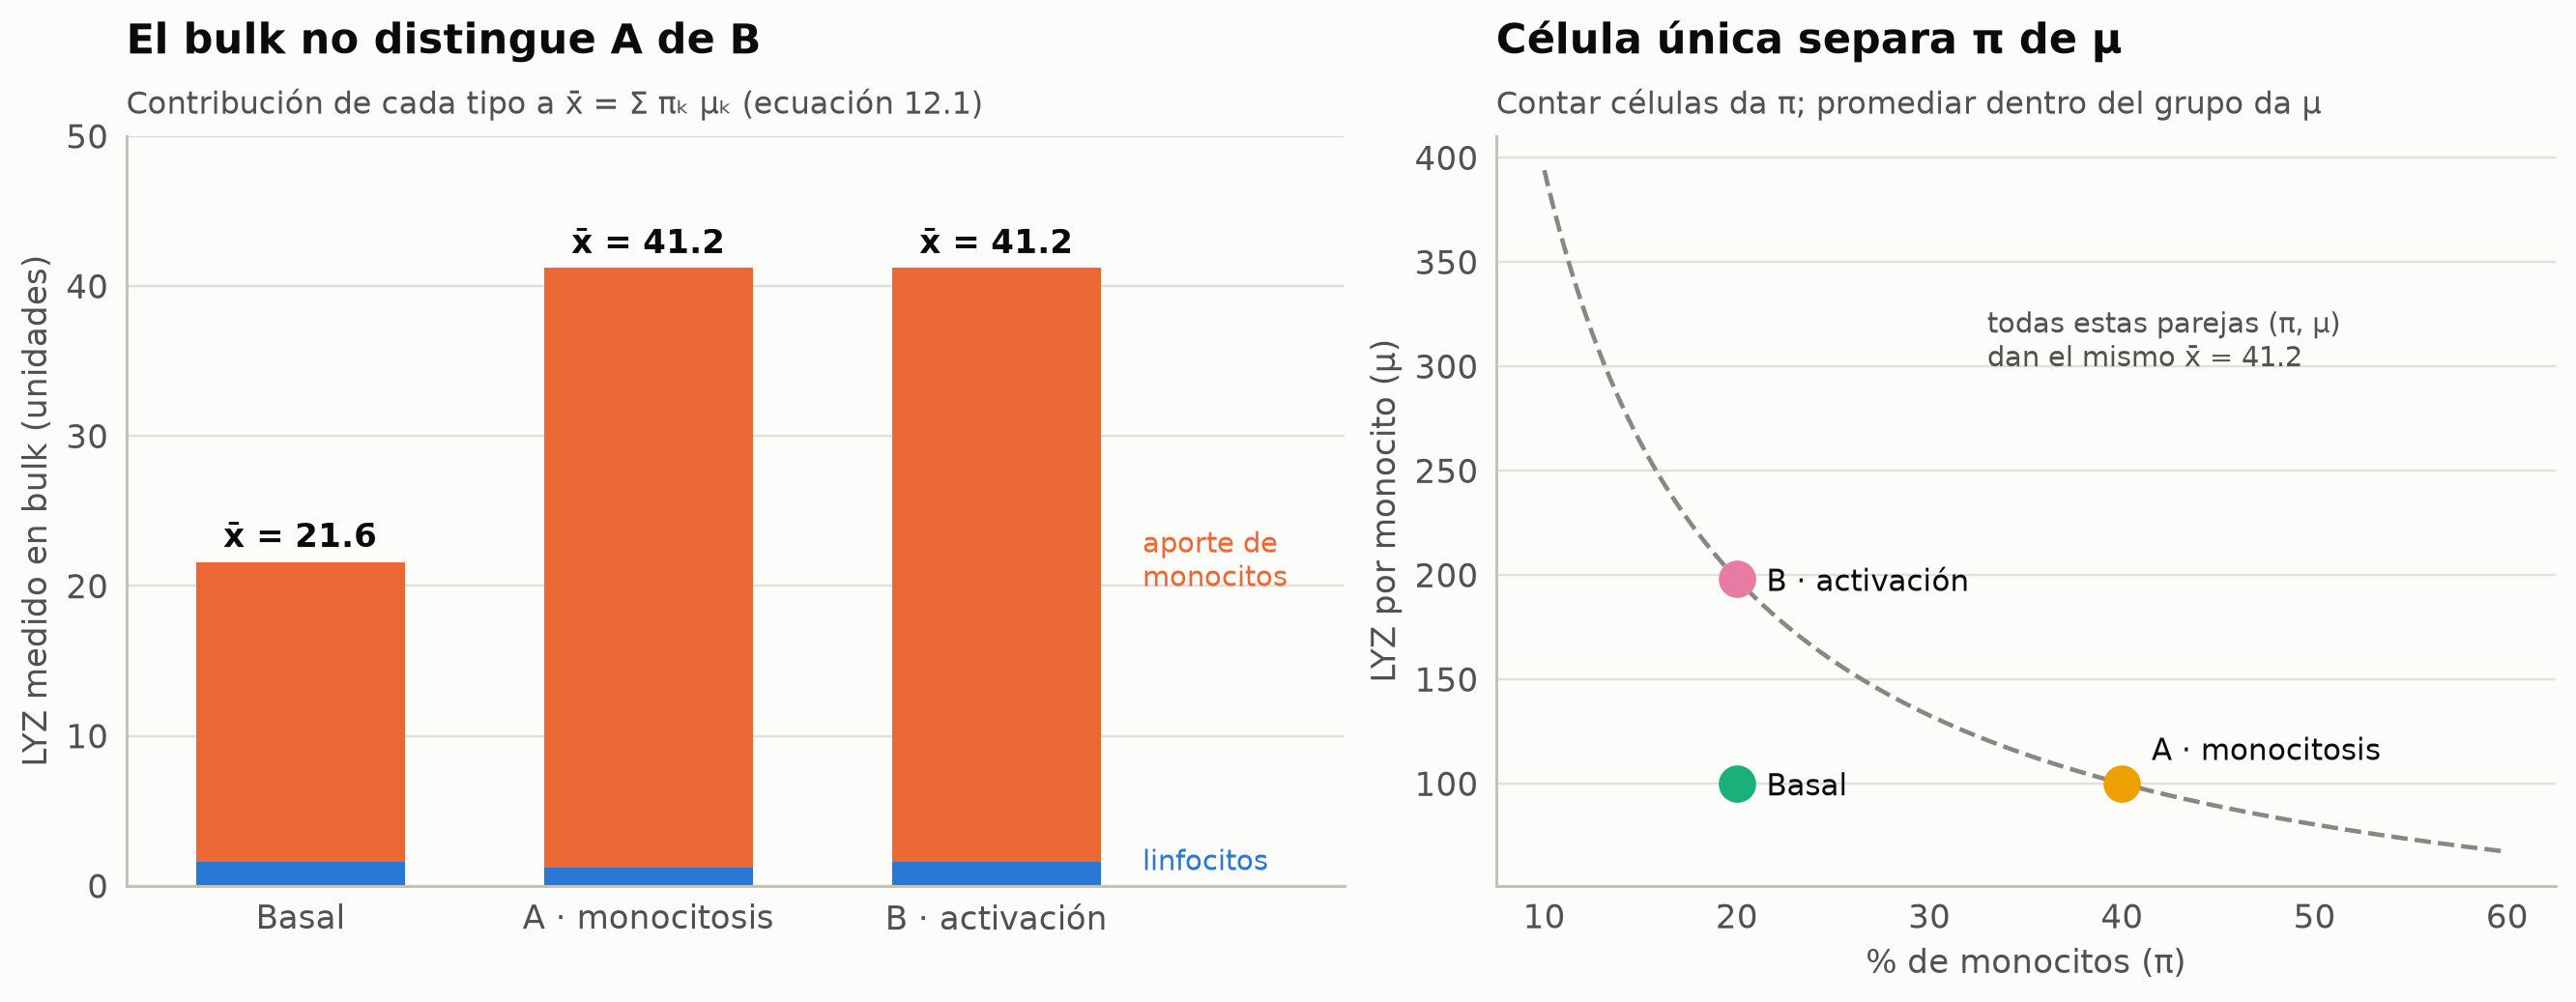

In [3]:
scen = {"Basal": (0.2, 100), "A · monocitosis": (0.4, 100), "B · activación": (0.2, 198)}
mu_lin = 2
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axs[0]
for i, (name, (pi, mu_mono)) in enumerate(scen.items()):
    c_mono, c_lin = pi * mu_mono, (1 - pi) * mu_lin
    ax.bar(i, c_lin, color=ec.BLUE, width=0.6)
    ax.bar(i, c_mono, bottom=c_lin, color=ec.ORANGE, width=0.6)
    ax.text(i, c_mono + c_lin + 1, f"x̄ = {c_mono + c_lin:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(range(3), list(scen)); ax.set_ylabel("LYZ medido en bulk (unidades)")
ax.set_ylim(0, 50)
ax.text(2.42, 41.2 / 2 + 1, "aporte de\nmonocitos", color=ec.ORANGE, fontsize=9.5, va="center")
ax.text(2.42, 0.6, "linfocitos", color=ec.BLUE, fontsize=9.5, va="bottom")
ax.set_xlim(-0.5, 3.0)
ec.title(ax, "El bulk no distingue A de B", "Contribución de cada tipo a x̄ = Σ πₖ μₖ (ecuación 12.1)")
ax = axs[1]
for i, (name, (pi, mu_mono)) in enumerate(scen.items()):
    ax.scatter([pi * 100], [mu_mono], s=160, color=ec.CATEGORICAL[i + 2], zorder=3)
    ax.annotate(name, (pi * 100, mu_mono), xytext=(10, -4 if i != 1 else 8), textcoords="offset points", fontsize=10)
pp = np.linspace(10, 60, 200)
ax.plot(pp, (41.2 - (1 - pp / 100) * mu_lin) / (pp / 100), color=ec.MUTED, lw=1.5, ls="--")
ax.text(33, 300, "todas estas parejas (π, μ)\ndan el mismo x̄ = 41.2", color=ec.INK_2, fontsize=9.5)
ax.set_xlabel("% de monocitos (π)"); ax.set_ylabel("LYZ por monocito (μ)")
ec.title(ax, "Célula única separa π de μ", "Contar células da π; promediar dentro del grupo da μ")
plt.show()

> 🔎 **Qué observamos.** Las barras de los escenarios A y B tienen la misma altura, pero están hechas de piezas
> distintas. En el panel derecho, la curva discontinua son **infinitas** combinaciones de proporción y expresión
> compatibles con el mismo dato *bulk*. Una medición de célula única ubica al paciente en un punto concreto de ese plano.

La historia de cómo se llegó ahí es rápida: el primer transcriptoma de una sola célula (un blastómero de ratón,
procesado a mano) se publicó en 2009 (Tang *et al.*); en 2015, Drop-seq (Macosko *et al.*) e inDrop (Klein *et al.*)
encerraron cada célula en una gota de aceite de un nanolitro y perfilaron decenas de miles de células; en 2017 la
plataforma comercial de 10x Genomics perfiló unas 68 000 PBMC en un solo experimento (Zheng *et al.*). Los datos reales de
esta lección salen de ese mismo trabajo.

## 2. Gotas, códigos de barras y UMI

Un chip microfluídico hace confluir tres corrientes: una suspensión de **células**, una de **microesferas de gel** y
**aceite**. En la unión, el flujo se rompe en gotas de volumen casi constante; cada una atrapa, con suerte, exactamente
una célula y una microesfera. Dentro de la gota la célula se rompe (lisis) y su ARNm, que termina en una cola poli(A),
se pega a los oligonucleótidos de la microesfera. Cada oligonucleótido lleva:

| Pieza | Longitud (10x actual) | ¿Qué identifica? |
|---|---|---|
| **Código de barras celular (CB)** | 16 nt, igual en todas las copias de una microesfera | la **gota** y, por extensión, la **célula** |
| **UMI** (identificador molecular único) | 12 nt, distinto en cada copia | la **molécula** de ARNm capturada |
| **Poli(dT)** | ~30 T | se aparea con la cola poli(A) y ceba la transcripción inversa |

Tras la transcripción inversa se rompen las gotas y todo el ADNc (ya marcado) se amplifica y secuencia junto. Cada
lectura trae el CB y el UMI (lectura 1) y un trozo del transcrito (lectura 2), que se alinea al genoma para saber de qué
gen procede. (En Drop-seq, el CB tenía 12 nt y el UMI 8.)

### ¿Cuántas células caen en una gota?

Es una lotería. Si diluimos las células para que haya en promedio $\lambda$ células por gota, el número $K$ de
células de una gota sigue una **distribución de Poisson**:

$$
\Pr(K=k) = \frac{e^{-\lambda}\lambda^k}{k!},\qquad
\Pr(K\ge 2 \mid K\ge 1) = \frac{1-e^{-\lambda}-\lambda e^{-\lambda}}{1-e^{-\lambda}} \;\approx\; \frac{\lambda}{2}. \qquad (12.2)
$$

| Símbolo | Significado |
|---|---|
| $\lambda$ | Número medio de células por gota (concentración de carga) |
| $K$ | Número de células que contiene una gota concreta |
| $\Pr(K\ge2\mid K\ge1)$ | Fracción de **dobletes** entre las gotas que contienen al menos una célula |

La aproximación sale de desarrollar $e^{-\lambda}$ en serie de Taylor hasta segundo orden: el numerador es
$\lambda^2/2+O(\lambda^3)$ y el denominador $\lambda+O(\lambda^2)$.

**A mano, con $\lambda = 0.2$:** $e^{-0.2}=0.819$, así que el 81.9 % de las gotas está vacía; $\Pr(K=1)=0.2\times0.819=0.164$;
las ocupadas son $1-0.819=0.181$ y las que tienen dos o más, $0.181-0.164=0.0175$. Dobletes entre ocupadas:
$0.0175/0.181 = 9.7\,\%$, muy cerca de $\lambda/2=10\,\%$.

In [4]:
rows = []
for lam in (0.05, 0.1, 0.2, 0.5):
    p0 = math.exp(-lam); p1 = lam * p0
    rows.append({"λ": lam, "% gotas vacías": 100 * p0, "% gotas con 1 célula": 100 * p1,
                 "% dobletes entre ocupadas (exacto)": 100 * (1 - p0 - p1) / (1 - p0),
                 "aprox. λ/2 (%)": 100 * lam / 2})
poisson_tab = pd.DataFrame(rows)
poisson_tab.round(2)

,λ,% gotas vacías,% gotas con 1 célula,% dobletes entre ocupadas (exacto),aprox. λ/2 (%)
0,0.05,95.12,4.76,2.48,2.5
1,0.10,90.48,9.05,4.92,5.0
2,0.20,81.87,16.37,9.67,10.0
3,0.50,60.65,30.33,22.93,25.0


> 🔎 **Qué observamos.** Con $\lambda=0.05$ el 95.1 % de las gotas queda vacío y sólo el 2.5 % de las ocupadas son
> dobletes; con $\lambda=0.2$ el número de gotas con una célula se **cuadruplica** (4.76 % → 16.4 %), pero los dobletes
> suben al 9.7 %, y con $\lambda=0.5$, al 22.9 %. Cargar más células abarata el experimento y lo contamina: es un
> compromiso inevitable. Los primeros artículos midieron esta tasa mezclando células humanas y de ratón: una gota con
> transcritos de ambas especies es, sin ambigüedad, un doblete.

> 🤔 **Antes de ejecutar, prediga.** En la animación siguiente, 144 gotas se llenan al aumentar $\lambda$ de 0.02 a 1.
> ¿Con qué $\lambda$ cree que la mitad de las gotas ocupadas tendrá más de una célula?

![Al aumentar la concentración de células (λ), las gotas vacías se vuelven gotas con una célula… y, cada vez más, dobletes.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.1_carga_gotas.gif)

*Al aumentar la concentración de células (λ), las gotas vacías se vuelven gotas con una célula… y, cada vez más, dobletes.*

In [5]:
# Cada gota tiene un número uniforme fijo u; con λ creciente, K = F⁻¹(u; λ) crece de forma coherente entre cuadros
rng_anim = np.random.default_rng(121)
n_side = 12
u_drop = rng_anim.uniform(size=n_side * n_side)
jitter = rng_anim.uniform(-0.18, 0.18, size=(n_side * n_side, 4, 2))
lams = np.linspace(0.02, 1.0, 50)
lgrid = np.linspace(0.001, 1.0, 300)
doub_curve = (1 - np.exp(-lgrid) - lgrid * np.exp(-lgrid)) / (1 - np.exp(-lgrid))

fig, (axd, axc) = plt.subplots(1, 2, figsize=(11.5, 5.2), gridspec_kw={"width_ratios": [1, 1.15]})
def update(f):
    lam = lams[f]
    K = stats.poisson.ppf(u_drop, lam).astype(int)
    axd.clear(); axc.clear()
    for i in range(n_side * n_side):
        x, y = i % n_side, i // n_side
        col = "#eeeeec" if K[i] == 0 else (ec.SEQ_BLUE[3] if K[i] == 1 else "#f3b0ae")
        axd.add_patch(Circle((x, y), 0.44, facecolor=col, edgecolor=ec.BASELINE, lw=0.6))
        for j in range(min(K[i], 4)):
            dx, dy = jitter[i, j]
            axd.add_patch(Circle((x + dx, y + dy), 0.13, color=ec.BLUE if K[i] == 1 else ec.RED))
    axd.set_xlim(-0.6, n_side - 0.4); axd.set_ylim(-0.6, n_side - 0.4); axd.set_aspect("equal"); axd.axis("off")
    occ = (K >= 1).sum(); dbl = (K >= 2).sum()
    axd.set_title(f"λ = {lam:.2f}: {(K == 0).sum()} vacías · {(K == 1).sum()} con 1 · {dbl} dobletes",
                  loc="left", fontsize=12)
    axc.plot(lgrid, 100 * np.exp(-lgrid), color=ec.MUTED, lw=2)
    axc.plot(lgrid, 100 * lgrid * np.exp(-lgrid), color=ec.BLUE, lw=2)
    axc.plot(lgrid, 100 * doub_curve, color=ec.RED, lw=2)
    axc.plot(lgrid, 100 * lgrid / 2, color=ec.RED, lw=1, ls=":")
    for yv, col in [(100 * np.exp(-lam), ec.MUTED), (100 * lam * np.exp(-lam), ec.BLUE),
                    (100 * (1 - np.exp(-lam) - lam * np.exp(-lam)) / (1 - np.exp(-lam)), ec.RED)]:
        axc.scatter([lam], [yv], color=col, s=50, zorder=3)
    axc.axvline(lam, color=ec.GRID, lw=1)
    axc.text(0.62, 58, "% gotas vacías", color=ec.INK_2, fontsize=10)
    axc.text(0.03, 30, "% dobletes entre\nocupadas (exacto)", color=ec.RED, fontsize=10)
    axc.text(0.86, 48, "λ/2", color=ec.RED, fontsize=10)
    axc.text(0.66, 13, "% gotas con 1 célula", color=ec.BLUE, fontsize=10)
    axc.set_xlim(0, 1.02); axc.set_ylim(0, 102)
    axc.set_xlabel("λ (células por gota, en promedio)"); axc.set_ylabel("%")
    ec.title(axc, "Rendimiento contra pureza", "Curvas de la ecuación 12.2")
ec.animate(fig, update, frames=len(lams), interval=180, name="12.1_carga_gotas")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las gotas azules (una célula) aparecen primero; las rojas (dobletes) empiezan a ser comunes
> cuando $\lambda$ pasa de 0.3–0.4. La curva roja crece casi en línea recta, pegada a $\lambda/2$ para $\lambda$
> pequeño, y la mitad de las gotas ocupadas son dobletes recién con $\lambda\approx 1.26$ (fuera del gráfico): mucho
> antes de eso, el experimento ya sería inservible. Por eso los protocolos trabajan con $\lambda$ bajos y aceptan que la
> inmensa mayoría de las gotas estén vacías.

El explorador interactivo permite leer las tres curvas en cualquier $\lambda$. Pase el cursor: el globo traduce cada
probabilidad a «de cada 10 000 gotas…».

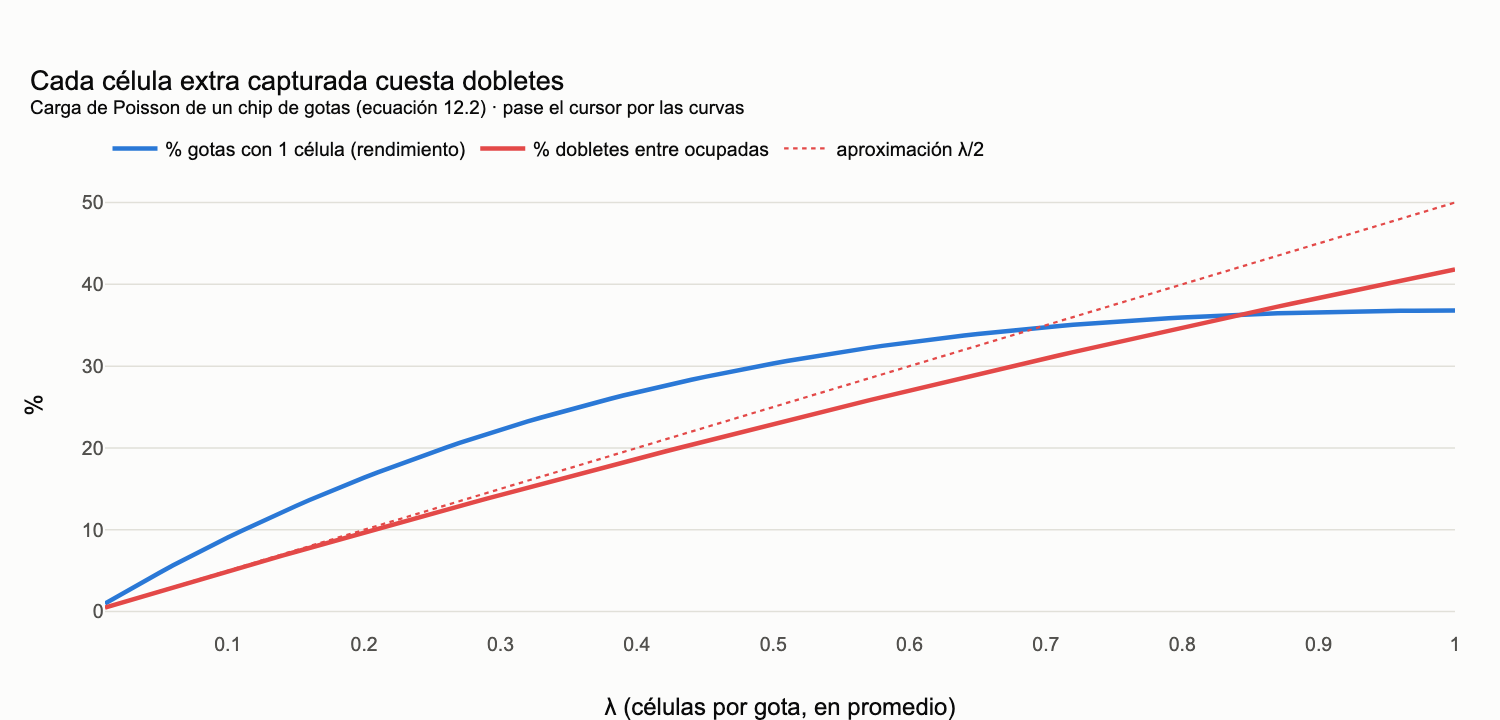

In [6]:
lam_x = np.linspace(0.01, 1.0, 100)
p0 = np.exp(-lam_x); p1 = lam_x * p0; dbl = (1 - p0 - p1) / (1 - p0)
hover = [f"<b>λ = {l:.2f}</b><br>De cada 10 000 gotas:<br>· {1e4*a:,.0f} vacías<br>· {1e4*b:,.0f} con 1 célula"
         f"<br>· {1e4*(1-a-b):,.0f} con ≥ 2 células<br><b>{100*d:.1f} %</b> de las gotas ocupadas son dobletes"
         f"<br>(aprox. λ/2 = {50*l:.1f} %)" for l, a, b, d in zip(lam_x, p0, p1, dbl)]
figp = go.Figure()
figp.add_trace(go.Scatter(x=lam_x, y=100 * p1, name="% gotas con 1 célula (rendimiento)",
                          line=dict(color=ec.BLUE, width=3), text=hover, hovertemplate="%{text}<extra></extra>"))
figp.add_trace(go.Scatter(x=lam_x, y=100 * dbl, name="% dobletes entre ocupadas",
                          line=dict(color=ec.RED, width=3), text=hover, hovertemplate="%{text}<extra></extra>"))
figp.add_trace(go.Scatter(x=lam_x, y=50 * lam_x, name="aproximación λ/2", line=dict(color=ec.RED, dash="dot", width=1.5),
                          hoverinfo="skip"))
figp.update_layout(title="Cada célula extra capturada cuesta dobletes<br><sup>Carga de Poisson de un chip de gotas "
                         "(ecuación 12.2) · pase el cursor por las curvas</sup>",
                   xaxis_title="λ (células por gota, en promedio)", yaxis_title="%", height=480,
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=70, r=30, b=60),
                   hovermode="x")
figp.show()

### Por qué hacen falta los UMI

La PCR multiplica unas moléculas más que otras. Si contáramos **lecturas**, mezclaríamos la abundancia real con la
eficiencia de amplificación. Kivioja *et al.* (2012) propusieron marcar cada molécula **antes** de amplificar con una
secuencia aleatoria: todas las lecturas que comparten célula, UMI y gen son copias de la misma molécula, y basta con
contar **UMI distintos**. Veámoslo con las cuatro lecturas del panel 3 de la figura 12.1 del libro:

In [7]:
reads = pd.DataFrame({
    "CB":  ["AAACCTGA", "AAACCTGA", "AAACCTGA", "TTTGGCAT"],
    "UMI": ["GATTACAGCTTA", "GATTACAGCTTA", "CCGTAGTAAGCA", "TGCATGCATTAC"],
    "gen": ["LYZ", "LYZ", "LYZ", "CD3E"]})
print("Lecturas secuenciadas:"); print(reads.to_string(index=False))
by_reads = reads.groupby(["CB", "gen"]).size().rename("lecturas")
by_umis = reads.groupby(["CB", "gen"])["UMI"].nunique().rename("UMI distintos (= moléculas)")
print("\n", pd.concat([by_reads, by_umis], axis=1).to_string())

Lecturas secuenciadas:
      CB          UMI  gen
AAACCTGA GATTACAGCTTA  LYZ
AAACCTGA GATTACAGCTTA  LYZ
AAACCTGA CCGTAGTAAGCA  LYZ
TTTGGCAT TGCATGCATTAC CD3E

                lecturas  UMI distintos (= moléculas)
CB       gen                                        
AAACCTGA LYZ          3                            2
TTTGGCAT CD3E         1                            1


Las dos primeras lecturas tienen el mismo CB, el mismo UMI y el mismo gen: son copias de PCR de **una** molécula. La
célula `AAACCTGA` tiene 3 lecturas pero sólo **2 moléculas** de *LYZ*.

**¿Cuán largo debe ser el UMI?** Si una célula tiene $n$ moléculas de un gen y los UMI miden $L$ nucleótidos, hay
$4^L$ UMI posibles y, por el mismo argumento del **problema del cumpleaños**, el número esperado de pares que comparten
UMI por azar es

$$
\mathbb{E}[\text{colisiones}] \approx \binom{n}{2}\frac{1}{4^{L}} = \frac{n(n-1)}{2\cdot 4^{L}}. \qquad (12.3)
$$

| Símbolo | Significado |
|---|---|
| $n$ | Moléculas del mismo gen en la misma célula |
| $L$ | Longitud del UMI (nt); $4^L$ es el número de UMI distintos posibles |

**A mano:** con $n=1000$ y $L=12$, $4^{12}=16\,777\,216$ y $\binom{1000}{2}=499\,500$, así que esperamos
$499\,500/16\,777\,216\approx 0.03$ colisiones. Con $L=10$ ($4^{10}=1\,048\,576$) la cifra sube a $\approx 0.48$.

In [8]:
coll = pd.DataFrame([{"n moléculas": n, "UMI 10 nt": n * (n - 1) / 2 / 4**10, "UMI 12 nt": n * (n - 1) / 2 / 4**12}
                     for n in (10, 100, 1000)])
print(f"Códigos de barras de 16 nt posibles: 4^16 = {4**16:.3e}   ·   UMI de 12 nt: 4^12 = {4**12:.3e}")
print(coll.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Códigos de barras de 16 nt posibles: 4^16 = 4.295e+09   ·   UMI de 12 nt: 4^12 = 1.678e+07
 n moléculas  UMI 10 nt  UMI 12 nt
          10     0.0000     0.0000
         100     0.0047     0.0003
        1000     0.4764     0.0298


> 🔎 **Qué observamos.** Con 12 nt, incluso un gen con 1 000 moléculas en la célula (algo excepcional) produce en
> promedio 0.03 colisiones: subestimar su cuenta en una molécula ocurre en uno de cada ~30 casos. Por la misma cuenta, los
> $4^{16}\approx 4.3\times10^9$ códigos celulares posibles bastan para que dos microesferas compartan código muy rara vez.

> ✅ **Compruebe su comprensión.** (1) ¿Por qué un experimento con $\lambda=0.5$ no es «más eficiente» aunque capture
> más células? (2) Si un laboratorio usara UMI de 6 nt, ¿cuántas colisiones esperaría para un gen con 100 moléculas?
> *(Respuestas: (1) porque casi uno de cada cuatro perfiles sería un doblete, que contamina el análisis;
> (2) $100\cdot99/(2\cdot4^6)=4950/4096\approx1.2$ colisiones: el conteo se saturaría.)*

## 3. La matriz de cuentas y su almacenamiento

El preprocesamiento de las lecturas (Cell Ranger, STARsolo o alevin) produce una matriz $X\in\mathbb{N}^{n\times G}$ cuya
entrada $x_{cg}$ es el número de UMI del gen $g$ en la célula $c$. Por convención de Scanpy, **las filas son células**
(observaciones) y **las columnas son genes** (variables).

Un conjunto típico de 10x detecta entre mil y tres mil genes por célula, de unos 33 000 anotados: **más del 90 % de las
entradas son cero**. Guardar esos ceros es como imprimir una guía telefónica en la que casi todas las líneas dicen «sin
número»: basta con listar quién sí tiene número y dónde. Eso hace el formato **disperso**.

**Formato CSR** (*compressed sparse row*). Una matriz se representa con tres vectores:

* `data`: los valores no nulos, leídos fila por fila;
* `indices`: la **columna** de cada valor;
* `indptr`: de longitud $n+1$, tal que los valores de la fila $i$ ocupan las posiciones `indptr[i]` a `indptr[i+1]`$-1$
  de los dos vectores anteriores.

### 📝 Ejemplo resuelto del libro: una matriz dispersa a mano

La matriz de la figura 12.1 del libro tiene 4 células, 6 genes y 6 entradas no nulas:

$$
X=\begin{pmatrix}0&3&0&0&1&0\\0&0&0&0&0&0\\2&0&0&5&0&0\\0&1&0&0&0&7\end{pmatrix}
\quad\Longrightarrow\quad
\begin{array}{l}
\texttt{data}\;\;\;\,= [3, 1, 2, 5, 1, 7]\\
\texttt{indices} = [1, 4, 0, 3, 1, 5]\\
\texttt{indptr}\;\, = [0, 2, 2, 4, 6]
\end{array}
$$

Recórralo con el dedo: la fila 0 tiene un 3 en la columna 1 y un 1 en la columna 4 (posiciones 0 y 1 de `data`), así que
la fila 1 empieza en la posición 2. La fila 1 (la segunda, contando desde cero) ocupa el intervalo **vacío** $[2,2)$: es una
célula sin cuentas. La fila 2 ocupa $[2,4)$ y la fila 3, $[4,6)$. Programémoslo sin ayuda y comparemos con SciPy.

In [9]:
def dense_to_csr(M):
    """Codifica una matriz densa en CSR recorriéndola fila por fila."""
    data, indices, indptr = [], [], [0]
    for row in M:
        for j, v in enumerate(row):
            if v != 0:
                data.append(int(v)); indices.append(j)
        indptr.append(len(data))          # dónde termina esta fila (= dónde empieza la siguiente)
    return data, indices, indptr

def csr_row(data, indices, indptr, i, n_cols):
    """Reconstruye la fila i a partir de los tres vectores."""
    row = np.zeros(n_cols, dtype=int)
    s, e = indptr[i], indptr[i + 1]
    row[indices[s:e]] = data[s:e]
    return row

M = np.array([[0, 3, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0], [2, 0, 0, 5, 0, 0], [0, 1, 0, 0, 0, 7]])
d, ix, ip = dense_to_csr(M)
print("A mano:  data =", d, " indices =", ix, " indptr =", ip)
Mc = sparse.csr_matrix(M)
print("SciPy:   data =", Mc.data.tolist(), " indices =", Mc.indices.tolist(), " indptr =", Mc.indptr.tolist())
print("Fila 2 reconstruida:", csr_row(np.array(d), np.array(ix), ip, 2, 6))

A mano:  data = [3, 1, 2, 5, 1, 7]  indices = [1, 4, 0, 3, 1, 5]  indptr = [0, 2, 2, 4, 6]
SciPy:   data = [3, 1, 2, 5, 1, 7]  indices = [1, 4, 0, 3, 1, 5]  indptr = [0, 2, 2, 4, 6]
Fila 2 reconstruida: [2 0 0 5 0 0]


**¿Cuánto se ahorra?** Para un atlas de $10^6$ células y 33 538 genes, la matriz densa en `float32` (4 bytes) ocupa
$10^6\times 33\,538\times 4\approx 134$ GB. Si cada célula tiene en promedio 2 000 genes detectados, CSR necesita
$2\times10^9$ valores y $2\times10^9$ índices de 4 bytes: unos **16 GB, ocho veces menos**. El ahorro depende de la
**densidad** (fracción de entradas no nulas): en la simulación del libro, con 2 000 genes ya prefiltrados, la densidad es
del 47 % y el ahorro es mínimo; el formato disperso rinde cuando la matriz incluye todo el genoma.

In [10]:
def csr_bytes(nnz, n_rows, val_bytes=4, idx_bytes=4, ptr_bytes=8):
    return nnz * (val_bytes + idx_bytes) + (n_rows + 1) * ptr_bytes

n_atlas, g_atlas, genes_per_cell = 1_000_000, 33_538, 2_000
print(f"Atlas de 10^6 células: densa {n_atlas*g_atlas*4/1e9:.0f} GB · "
      f"CSR {csr_bytes(n_atlas*genes_per_cell, n_atlas)/1e9:.0f} GB")
Xs_sim = sparse.csr_matrix(Xall)
dens_sim = Xs_sim.nnz / np.prod(Xs_sim.shape)
print(f"Simulación del libro {Xs_sim.shape}: densidad {dens_sim:.1%} · densa {np.prod(Xs_sim.shape)*4/1e6:.1f} MB · "
      f"CSR {csr_bytes(Xs_sim.nnz, Xs_sim.shape[0])/1e6:.1f} MB")

Atlas de 10^6 células: densa 134 GB · CSR 16 GB
Simulación del libro (3360, 2000): densidad 46.6% · densa 26.9 MB · CSR 25.1 MB


### 🧪 Datos reales: PBMC 3k de 10x Genomics

El conjunto **PBMC 3k** contiene 2 700 células mononucleares de sangre periférica de un donante sano, secuenciadas con la
química v1 de 10x Genomics y procesadas con Cell Ranger 1.1.0. Es el «hola, mundo» de la célula única: el tutorial clásico
de Seurat y el de Scanpy lo usan. Cell Ranger entrega tres archivos: `barcodes.tsv` (una fila por célula), `genes.tsv` (una
fila por gen: identificador de Ensembl y símbolo) y `matrix.mtx`, la matriz en **formato Matrix Market**, que es otra
forma dispersa: una línea `gen célula valor` por cada entrada no nula (formato de coordenadas, COO).

La celda descarga el archivo comprimido (7.6 MB) del servidor de 10x, o usa la copia del curso, lo descomprime en una
carpeta temporal y lo lee con `sc.read_10x_mtx`.

In [11]:
URL_10X = "https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
tgz = course_bytes("12_pbmc3k_filtered.tar.gz", live_url=URL_10X)
tmpdir = tempfile.mkdtemp(prefix="pbmc3k_")            # carpeta temporal: no ensuciamos el repositorio
with tarfile.open(fileobj=io.BytesIO(tgz), mode="r:gz") as tar:
    tar.extractall(tmpdir)
mtx_dir = os.path.join(tmpdir, "filtered_gene_bc_matrices", "hg19")
print(sorted(os.listdir(mtx_dir)))
with open(os.path.join(mtx_dir, "matrix.mtx")) as fh:
    head = [next(fh).strip() for _ in range(5)]
print("Primeras líneas de matrix.mtx:", *head, sep="\n   ")

adata = sc.read_10x_mtx(mtx_dir, var_names="gene_symbols")
adata.var_names_make_unique()                # algunos símbolos se repiten: se les añade -1, -2…
print("\nFormato leído:", type(adata.X).__name__)
adata.X = sparse.csr_matrix(adata.X)          # filas = células ⇒ CSR hace barato recorrer una célula
adata

['barcodes.tsv', 'genes.tsv', 'matrix.mtx']
Primeras líneas de matrix.mtx:
   %%MatrixMarket matrix coordinate real general
   %
   32738 2700 2286884
   32709 1 4
   32707 1 1



Formato leído: csc_matrix


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

La tercera línea de `matrix.mtx` dice `32738 2700 2286884`: **genes, códigos de barras y entradas no nulas** (el archivo
original guarda los genes en las filas; Scanpy lo traspone). El objeto **AnnData** guarda, alineadas con la matriz, tablas
de metadatos de células (`obs`) y de genes (`var`); más adelante tendrá representaciones de baja dimensión (`obsm`) y
grafos (`obsp`). Scanpy entrega la matriz en CSC (comprimida por columnas); la convertimos a CSR porque casi todo lo que
haremos es **por célula**: sumar su fila, contar sus genes, dividirla por su tamaño.

In [12]:
Xr = adata.X
n_cells, n_genes = Xr.shape
dens = Xr.nnz / (n_cells * n_genes)
print(f"{n_cells} células × {n_genes} genes · {Xr.nnz:,} entradas no nulas · densidad {dens:.2%}")
print(f"Densa float32: {n_cells*n_genes*4/1e6:.0f} MB · CSR: {csr_bytes(Xr.nnz, n_cells)/1e6:.1f} MB "
      f"(ahorro {n_cells*n_genes*4/csr_bytes(Xr.nnz, n_cells):.0f}×)")
vals = Xr.data
print(f"De las entradas no nulas: {np.mean(vals == 1):.1%} valen 1, {np.mean(vals == 2):.1%} valen 2, "
      f"{np.mean(vals >= 10):.2%} valen 10 o más; máximo = {vals.max():.0f}")
never = np.asarray((Xr > 0).sum(0)).ravel() == 0
print(f"Genes nunca detectados en ninguna célula: {never.sum():,} de {n_genes:,}")

2700 células × 32738 genes · 2,286,884 entradas no nulas · densidad 2.59%
Densa float32: 354 MB · CSR: 18.3 MB (ahorro 19×)
De las entradas no nulas: 69.8% valen 1, 11.9% valen 2, 5.74% valen 10 o más; máximo = 419
Genes nunca detectados en ninguna célula: 16,104 de 32,738


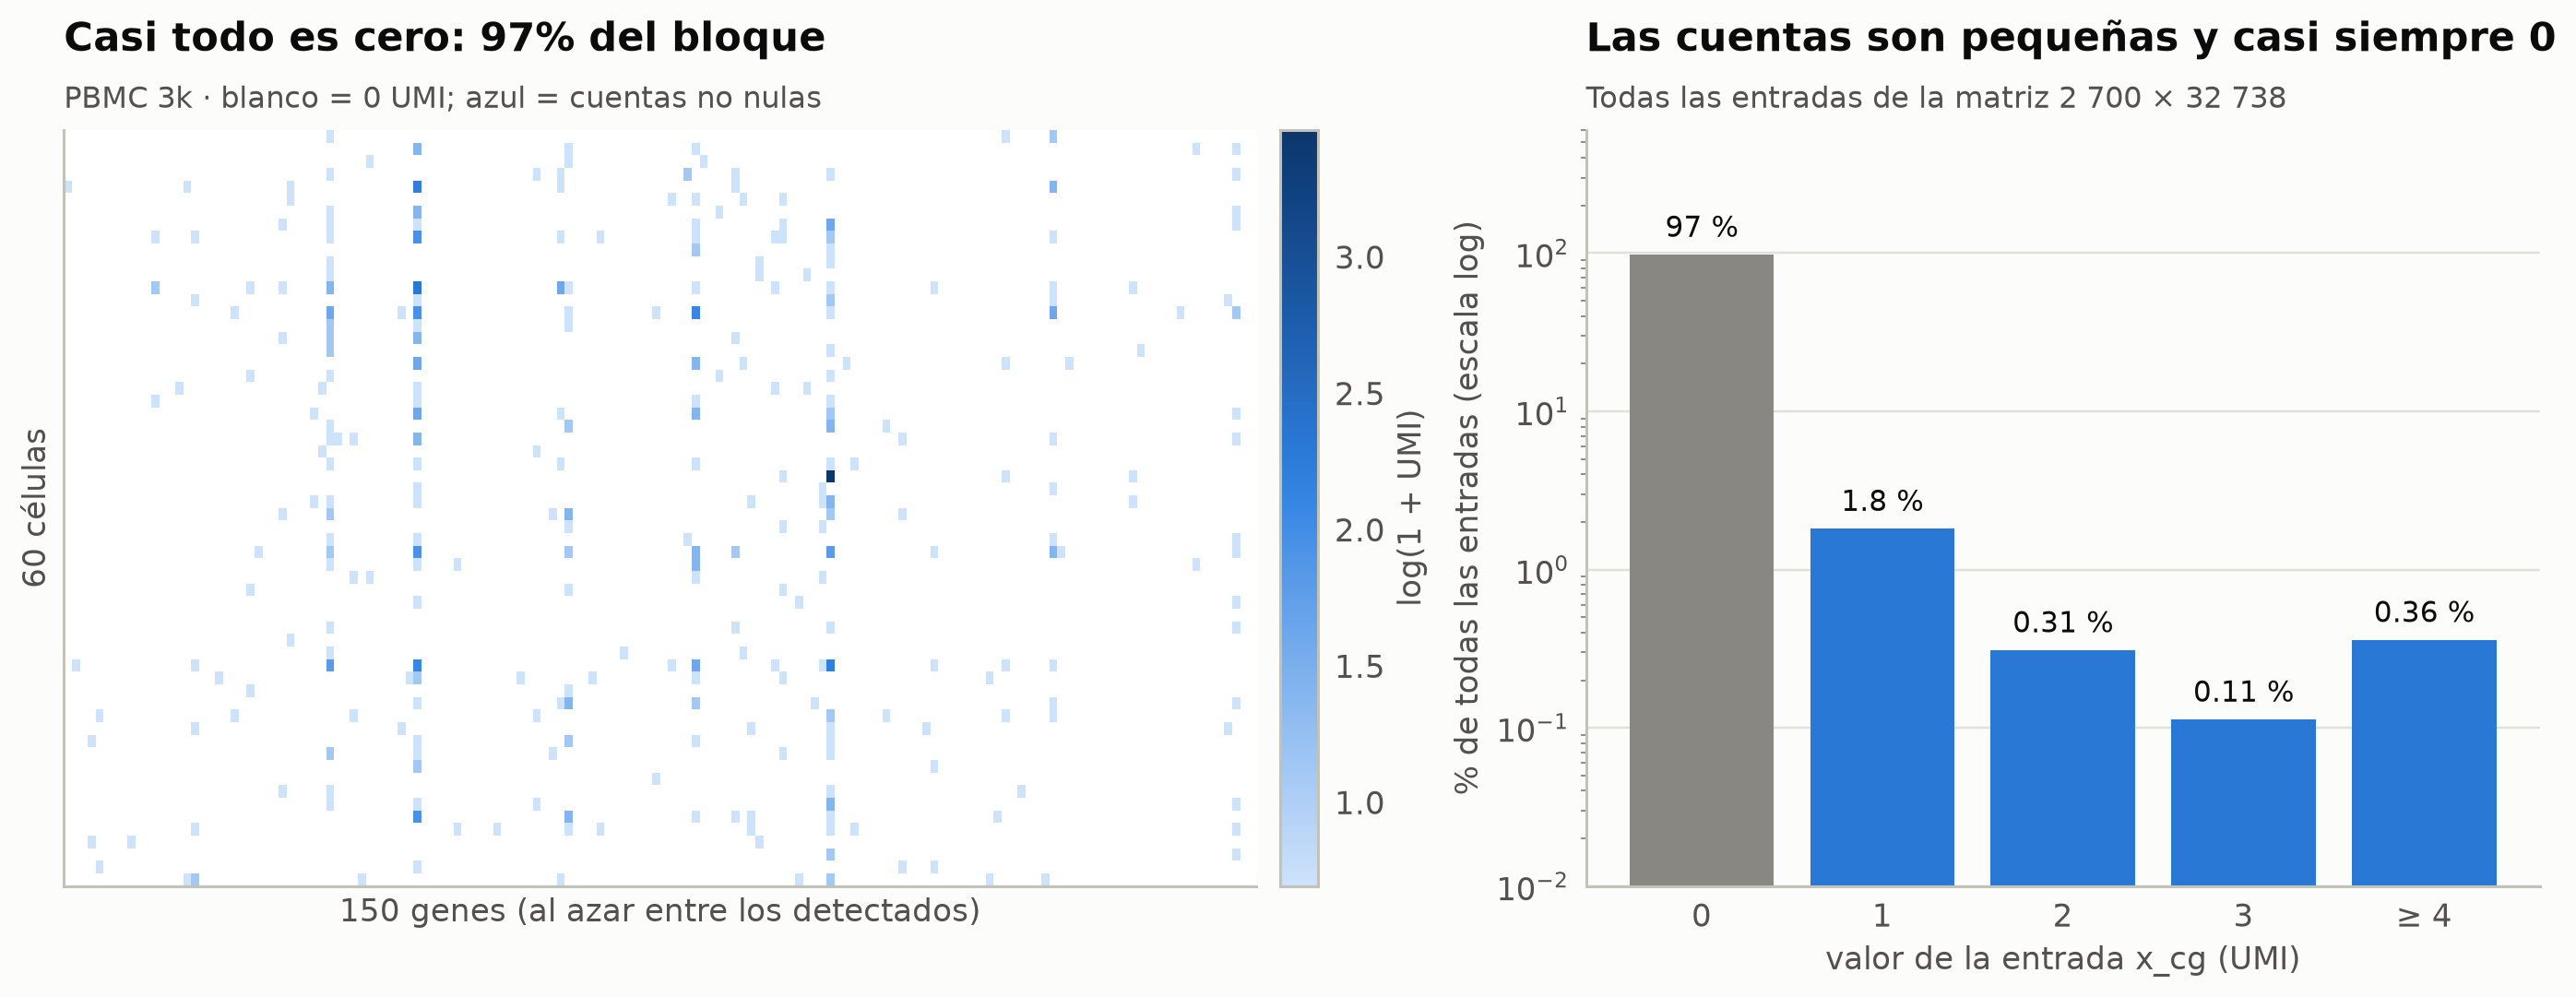

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
# (a) un bloque de la matriz: 60 células × 150 genes elegidos al azar entre los detectados
rng_blk = np.random.default_rng(3)
cells_blk = rng_blk.choice(n_cells, 60, replace=False)
genes_blk = np.sort(rng_blk.choice(np.where(~never)[0], 150, replace=False))
B = Xr[cells_blk][:, genes_blk].toarray()
ax = axs[0]
Bm = np.ma.masked_equal(B, 0)
ax.imshow(np.zeros_like(B), cmap="Greys", vmin=0, vmax=10, aspect="auto")
im = ax.imshow(np.log1p(Bm), cmap=ec.CMAP_SEQ, aspect="auto", interpolation="nearest")
ax.set_xlabel("150 genes (al azar entre los detectados)"); ax.set_ylabel("60 células")
ax.set_xticks([]); ax.set_yticks([])
cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02); cb.set_label("log(1 + UMI)")
ec.title(ax, f"Casi todo es cero: {np.mean(B == 0):.0%} del bloque",
         "PBMC 3k · blanco = 0 UMI; azul = cuentas no nulas")
# (b) distribución de valores de todas las entradas
ax = axs[1]
tot_entries = n_cells * n_genes
counts_v = [tot_entries - Xr.nnz] + [np.sum(vals == k) for k in (1, 2, 3)] + [np.sum(vals >= 4)]
labels_v = ["0", "1", "2", "3", "≥ 4"]
bars = ax.bar(labels_v, 100 * np.array(counts_v) / tot_entries, color=[ec.MUTED] + [ec.BLUE] * 4)
ax.set_yscale("log"); ax.set_ylabel("% de todas las entradas (escala log)")
ax.set_xlabel("valor de la entrada x_cg (UMI)")
for b, c in zip(bars, counts_v):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.3, f"{100*c/tot_entries:.2g} %", ha="center", fontsize=10)
ax.set_ylim(0.01, 600)
ec.title(ax, "Las cuentas son pequeñas y casi siempre 0", "Todas las entradas de la matriz 2 700 × 32 738")
plt.show()

> 🔎 **Qué observamos.** La matriz real tiene una densidad del **2.6 %**: CSR la guarda en ~18 MB frente a ~350 MB en forma
> densa, un ahorro de unas 19 veces. Además, de las pocas entradas no nulas, la mayoría vale **1**: una célula típica
> tiene una o dos moléculas de la mayoría de sus genes detectados. Estos datos son muy distintos de los del RNA-seq
> *bulk* (Módulo 11), donde un gen expresado tiene cientos o miles de lecturas. De ahí la importancia de modelar bien el
> ruido de conteo. Recuerde también que casi la mitad de los 32 738 genes anotados no aparece en ninguna célula.

## 4. Gotas vacías, curva de rodilla y ARN ambiental

La mayoría de los códigos de barras que aparecen en los datos **no son células**: vienen de gotas vacías que capturaron
ARN libre, liberado por células rotas en la suspensión. La forma clásica de separarlas es ordenar los códigos de mayor a
menor número total de UMI y dibujar la curva en escala log-log: la **curva de rodilla**. Las células forman una meseta alta;
las gotas vacías, una cola larga de pocas cuentas; entre ambas hay una caída abrupta, la «rodilla».

¿Cómo encontrar la caída con un algoritmo? En escala log-log la curva baja con pendiente suave en la meseta, cae casi en
vertical en la rodilla y vuelve a aplanarse en la cola. El punto de **pendiente más negativa** (de máxima caída) marca el
cambio de régimen. El libro lo calcula así: interpola $\log_{10}(\text{UMI})$ en 300 puntos equiespaciados de
$\log_{10}(\text{rango})$, deriva numéricamente, suaviza la derivada con una media móvil de 7 puntos y busca el mínimo.

Primero, la simulación del libro: a los 3 360 códigos con célula les añadimos 60 000 gotas vacías con unas decenas de
moléculas de ARN ambiental cada una.

In [14]:
def knee_inflection(totals):
    """Rango y UMI del punto de máxima caída de la curva de rodilla (algoritmo del libro)."""
    tot = np.sort(np.asarray(totals))[::-1]
    tot = tot[tot > 0]
    rank = np.arange(1, len(tot) + 1)
    lr, lt = np.log10(rank), np.log10(tot)
    grid = np.linspace(0, lr.max(), 300)
    lts = np.interp(grid, lr, lt)
    slope = np.convolve(np.gradient(lts, grid), np.ones(7) / 7, mode="same")
    i = np.argmin(slope[20:-20]) + 20                  # se ignoran los bordes, donde la media móvil es incompleta
    return 10 ** grid[i], 10 ** lts[i], rank, tot

rng_empty = np.random.default_rng(7)
tot_empty = rng_empty.poisson(rng_empty.lognormal(math.log(12), 0.9, 60000))
tot_cells_sim = Xall.sum(1)
r_inf_sim, t_inf_sim, rank_sim, tot_sim = knee_inflection(np.r_[tot_cells_sim, tot_empty])
print(f"Simulación: {len(tot_sim):,} códigos con ≥1 UMI; inflexión en el rango ≈ {r_inf_sim:.0f} con ≈ {t_inf_sim:.0f} UMI")

# Datos reales: totales de UMI por código de barras de la matriz «raw» de PBMC 3k (resumen guardado en el curso)
raw_tab = pd.read_csv(io.BytesIO(course_bytes("121_pbmc3k_raw_barcode_totals.tsv.gz")), sep="\t", compression="gzip")
r_inf_real, t_inf_real, rank_real, tot_real = knee_inflection(raw_tab.total_umi.values)
called = raw_tab.cell_ranger_cell.values.astype(bool)
print(f"PBMC 3k real: {len(raw_tab):,} códigos con ≥1 UMI; inflexión en el rango ≈ {r_inf_real:.0f} "
      f"con ≈ {t_inf_real:.0f} UMI")
print(f"Cell Ranger 1.1 llamó {called.sum():,} células (las de más UMI; la menor tiene {raw_tab.total_umi[called].min()} UMI)")

Simulación: 62,649 códigos con ≥1 UMI; inflexión en el rango ≈ 3385 con ≈ 235 UMI
PBMC 3k real: 158,890 códigos con ≥1 UMI; inflexión en el rango ≈ 2781 con ≈ 312 UMI
Cell Ranger 1.1 llamó 2,700 células (las de más UMI; la menor tiene 548 UMI)


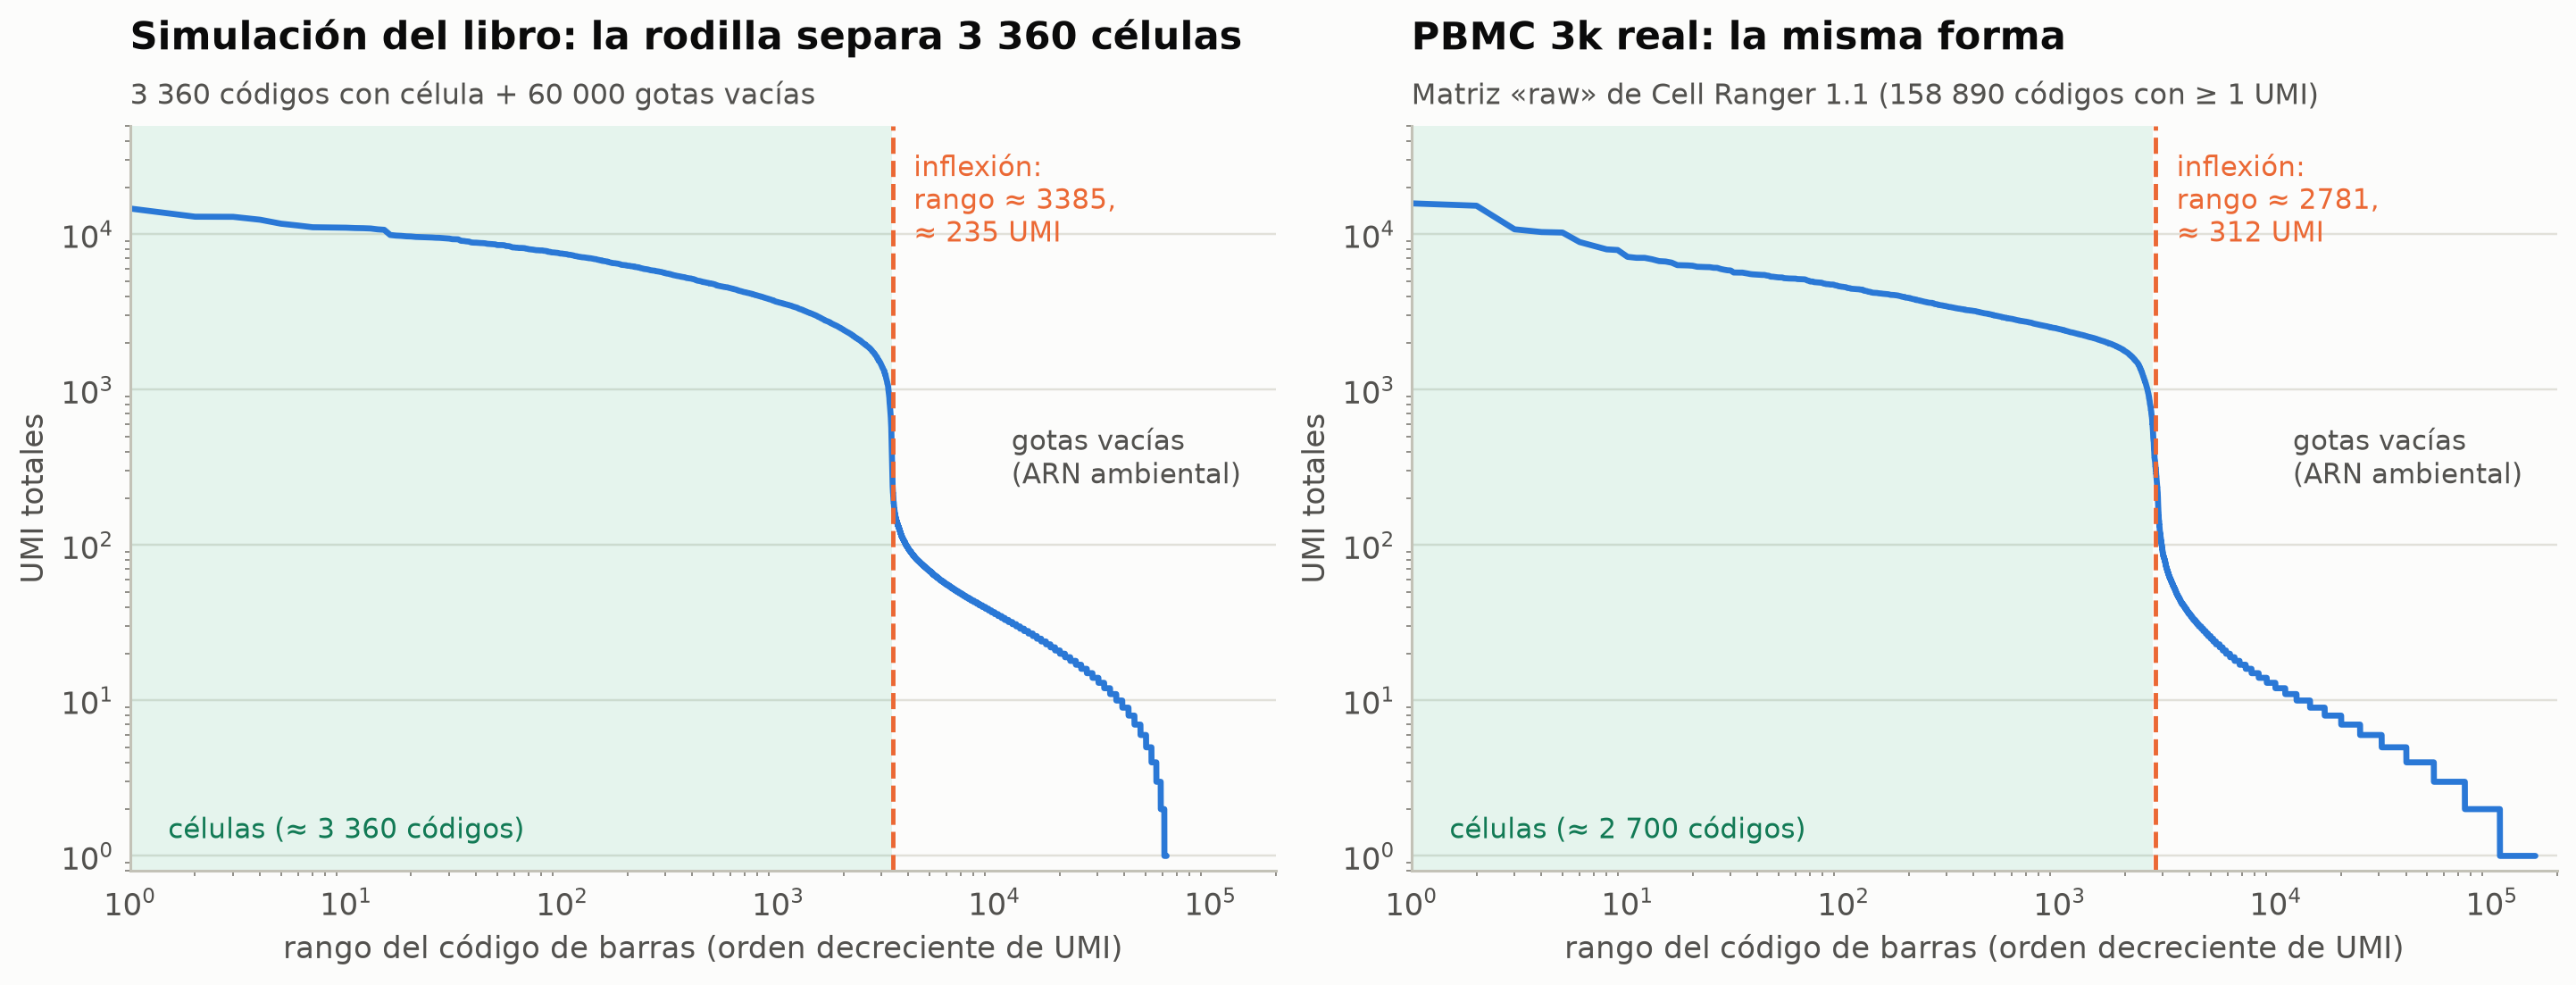

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.9), sharey=False)
for ax, rank, tot, r_inf, t_inf, n_cell, tit, sub in [
        (axs[0], rank_sim, tot_sim, r_inf_sim, t_inf_sim, 3360, "Simulación del libro: la rodilla separa 3 360 células",
         "3 360 códigos con célula + 60 000 gotas vacías"),
        (axs[1], rank_real, tot_real, r_inf_real, t_inf_real, int(called.sum()), "PBMC 3k real: la misma forma",
         "Matriz «raw» de Cell Ranger 1.1 (158 890 códigos con ≥ 1 UMI)")]:
    ax.fill_between([1, n_cell], 0.8, 5e4, color=ec.AQUA, alpha=0.10, lw=0)
    ax.plot(rank, tot, color=ec.BLUE, lw=2.2)
    ax.axvline(r_inf, color=ec.ORANGE, ls="--", lw=1.6)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(1, 2e5); ax.set_ylim(0.8, 5e4)
    ax.set_xlabel("rango del código de barras (orden decreciente de UMI)"); ax.set_ylabel("UMI totales")
    ax.text(1.5, 1.3, f"células (≈ {n_cell:,} códigos)".replace(",", " "), color="#127a55", fontsize=10)
    ax.text(r_inf * 1.25, 9000, f"inflexión:\nrango ≈ {r_inf:.0f},\n≈ {t_inf:.0f} UMI", color=ec.ORANGE, fontsize=10)
    ax.text(1.2e4, 250, "gotas vacías\n(ARN ambiental)", color=ec.INK_2, fontsize=10)
    ec.title(ax, tit, sub)
plt.show()

> 🔎 **Qué observamos.** En la simulación, la inflexión cae en el rango ≈ 3 385 con ≈ 235 UMI, justo después de los
> 3 360 códigos con célula (las cifras del libro). En los datos reales, la forma es la misma: la inflexión está en el rango
> ≈ 2 780 con ≈ 310 UMI, y Cell Ranger 1.1 llamó 2 700 células, todas con al menos 548 UMI. Cell Ranger usaba entonces una
> regla distinta (retener los códigos con más de un 10 % de las UMI del percentil 99 de las células esperadas), algo más
> conservadora que nuestra inflexión. Las células pequeñas o dañadas caen **cerca de la rodilla** y son las más difíciles de
> clasificar; métodos como EmptyDrops (Lun *et al.*, 2019) comparan el perfil de cada código con el del ambiente en lugar de
> mirar sólo su total. Observe también que la cola de gotas vacías real es mucho más corta que la simulada: el archivo
> «raw» de esta versión antigua de Cell Ranger ya viene recortado.

El explorador interactivo muestra la curva real. Pase el cursor: cada punto dice cuántas UMI y genes tiene el código y si
Cell Ranger lo consideró una célula.

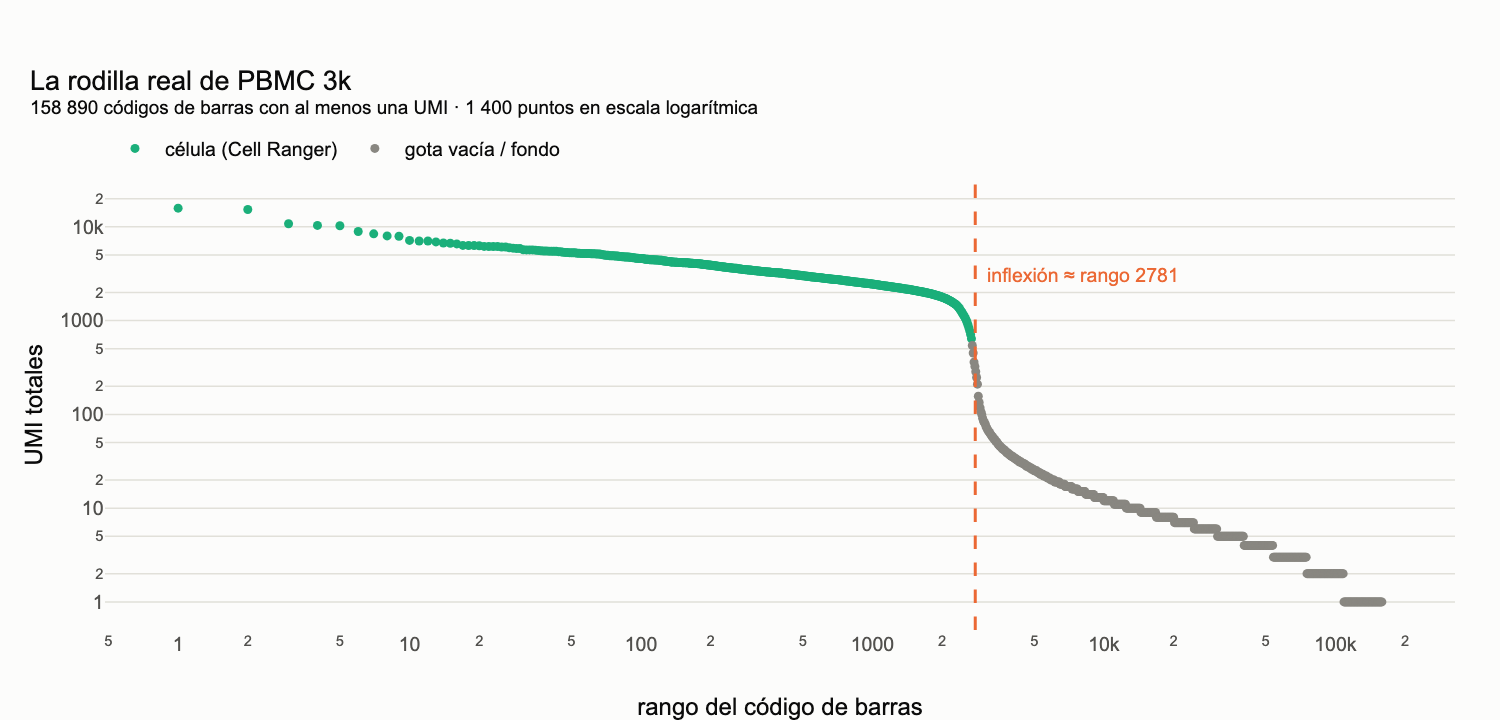

In [16]:
sel = np.unique(np.round(np.logspace(0, np.log10(len(raw_tab)), 1400)).astype(int) - 1)
sub = raw_tab.iloc[sel].copy()
sub["rango"] = sel + 1
sub["estado"] = np.where(sub.cell_ranger_cell == 1, "célula (Cell Ranger)", "gota vacía / fondo")
sub["nota"] = np.where(sub.total_umi >= 548, "meseta: perfil completo de una célula",
               np.where(sub.total_umi >= 100, "zona de la rodilla: ¿célula pequeña o gota con mucho ambiente?",
                        "cola: unas pocas moléculas de ARN libre"))
figk = go.Figure()
for est_name, col in [("célula (Cell Ranger)", ec.AQUA), ("gota vacía / fondo", ec.MUTED)]:
    s_ = sub[sub.estado == est_name]
    figk.add_trace(go.Scatter(
        x=s_.rango, y=s_.total_umi, mode="markers", name=est_name, marker=dict(color=col, size=6),
        customdata=np.c_[s_.n_genes, s_.nota],
        hovertemplate="rango %{x:,}<br><b>%{y:,} UMI</b> · %{customdata[0]} genes<br>%{customdata[1]}<extra></extra>"))
figk.add_vline(x=r_inf_real, line=dict(color=ec.ORANGE, dash="dash"))
figk.add_annotation(x=np.log10(r_inf_real), y=np.log10(3000), text=f"inflexión ≈ rango {r_inf_real:.0f}",
                    showarrow=False, xanchor="left", xshift=6, font=dict(color=ec.ORANGE))
figk.update_xaxes(type="log", title="rango del código de barras"); figk.update_yaxes(type="log", title="UMI totales")
figk.update_layout(title="La rodilla real de PBMC 3k<br><sup>158 890 códigos de barras con al menos una UMI · "
                         "1 400 puntos en escala logarítmica</sup>", height=480,
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=70, r=30, b=60))
figk.show()

### El ARN ambiental: la sopa que contamina todas las gotas

Las gotas vacías se descartan, pero su huella queda en las gotas con célula: todas contienen, además, una pequeña muestra
del ARN libre de la suspensión (la «sopa»). Si $p_{cg}$ es la fracción de las moléculas endógenas de la célula $c$ que
proceden del gen $g$, $a_g$ la fracción del gen $g$ en la sopa y $\rho_c$ la fracción contaminante, la cuenta esperada es

$$
\mathbb{E}[x_{cg}] = N_c\left[(1-\rho_c)\,p_{cg} + \rho_c\,a_g\right]. \qquad (12.4)
$$

| Símbolo | Significado |
|---|---|
| $N_c$ | Número total de UMI de la célula $c$ (tamaño de su librería) |
| $p_{cg}$ | Perfil de expresión verdadero de la célula (fracción del gen $g$) |
| $a_g$ | Perfil ambiental, estimable a partir de las gotas vacías |
| $\rho_c$ | Fracción de las moléculas de la célula que proviene del ambiente |

**A mano, con la sopa real.** Una célula B no expresa *LYZ* ($p_{cg}\approx0$), pero en la sopa *LYZ* abunda porque los
monocitos, grandes y numerosos, liberan mucho. La celda siguiente mide, en las gotas vacías de PBMC 3k,
$a_{\text{LYZ}}\approx0.0047$. Una célula B típica con $N_c\approx2\,200$ UMI y una contaminación modesta de
$\rho_c=0.02$ recibe en promedio $2\,200\times0.02\times0.0047\approx0.21$ moléculas de *LYZ* que **no son suyas**; si esas
moléculas llegan como una Poisson, la probabilidad de ver al menos una es $1-e^{-0.21}\approx19\,\%$. Un análisis ingenuo
diría que «una de cada cinco células B expresa *LYZ*».

SoupX (Young y Behjati, 2020) estima $a_g$ con las gotas vacías y $\rho_c$ con genes que se sabe que **no** se expresan en
ciertos tipos celulares, y resta la contribución ambiental. Veamos también la sopa real de PBMC 3k, estimada sumando las
cuentas de las ~11 400 gotas con entre 10 y 100 UMI.

In [17]:
soup = pd.read_csv(io.BytesIO(course_bytes("121_pbmc3k_ambient_profile.tsv.gz")), sep="\t", compression="gzip")
soup["a_g"] = soup.ambient_umi / soup.ambient_umi.sum()
soup = soup.sort_values("a_g", ascending=False).reset_index(drop=True)
# perfil medio de las células (fracción de cada gen en la suma de todas las células)
cell_prof = pd.Series(np.asarray(Xr.sum(0)).ravel(), index=adata.var_names)
cell_prof /= cell_prof.sum()
soup["en células"] = cell_prof.reindex(soup.symbol).values
print(f"Sopa real: {soup.ambient_umi.sum():,} UMI de {len(soup):,} genes; "
      f"fracción mitocondrial en la sopa = {soup.a_g[soup.symbol.str.startswith('MT-')].sum():.1%} "
      f"(en las células: {cell_prof[cell_prof.index.str.startswith('MT-')].sum():.1%})")
a_lyz_real = soup.set_index("symbol").a_g.get("LYZ", 0)
lam_lyz = 2200 * 0.02 * a_lyz_real
print(f"LYZ en la sopa real: a_LYZ = {a_lyz_real:.4f} ⇒ E[LYZ ambiental en una célula B] ≈ 2200 × 0.02 × "
      f"{a_lyz_real:.4f} = {lam_lyz:.2f} UMI; P(≥ 1) = {1 - np.exp(-lam_lyz):.0%}")
soup.head(12)[["symbol", "ambient_umi", "a_g", "en células"]].round(4)

Sopa real: 217,191 UMI de 8,991 genes; fracción mitocondrial en la sopa = 6.6% (en las células: 2.1%)
LYZ en la sopa real: a_LYZ = 0.0047 ⇒ E[LYZ ambiental en una célula B] ≈ 2200 × 0.02 × 0.0047 = 0.21 UMI; P(≥ 1) = 19%


,symbol,ambient_umi,a_g,en células
0,MALAT1,7845,0.0361,0.0253
1,B2M,4399,0.0203,0.0190
2,TMSB4X,4007,0.0184,0.0194
3,MT-CO1,3331,0.0153,0.0061
4,FTL,3080,0.0142,0.0117
5,RPL13,3027,0.0139,0.0121
6,RPS2,2985,0.0137,0.0102
7,RPL13A,2716,0.0125,0.0120
8,RPL10,2571,0.0118,0.0139
9,MT-CO3,2408,0.0111,0.0030


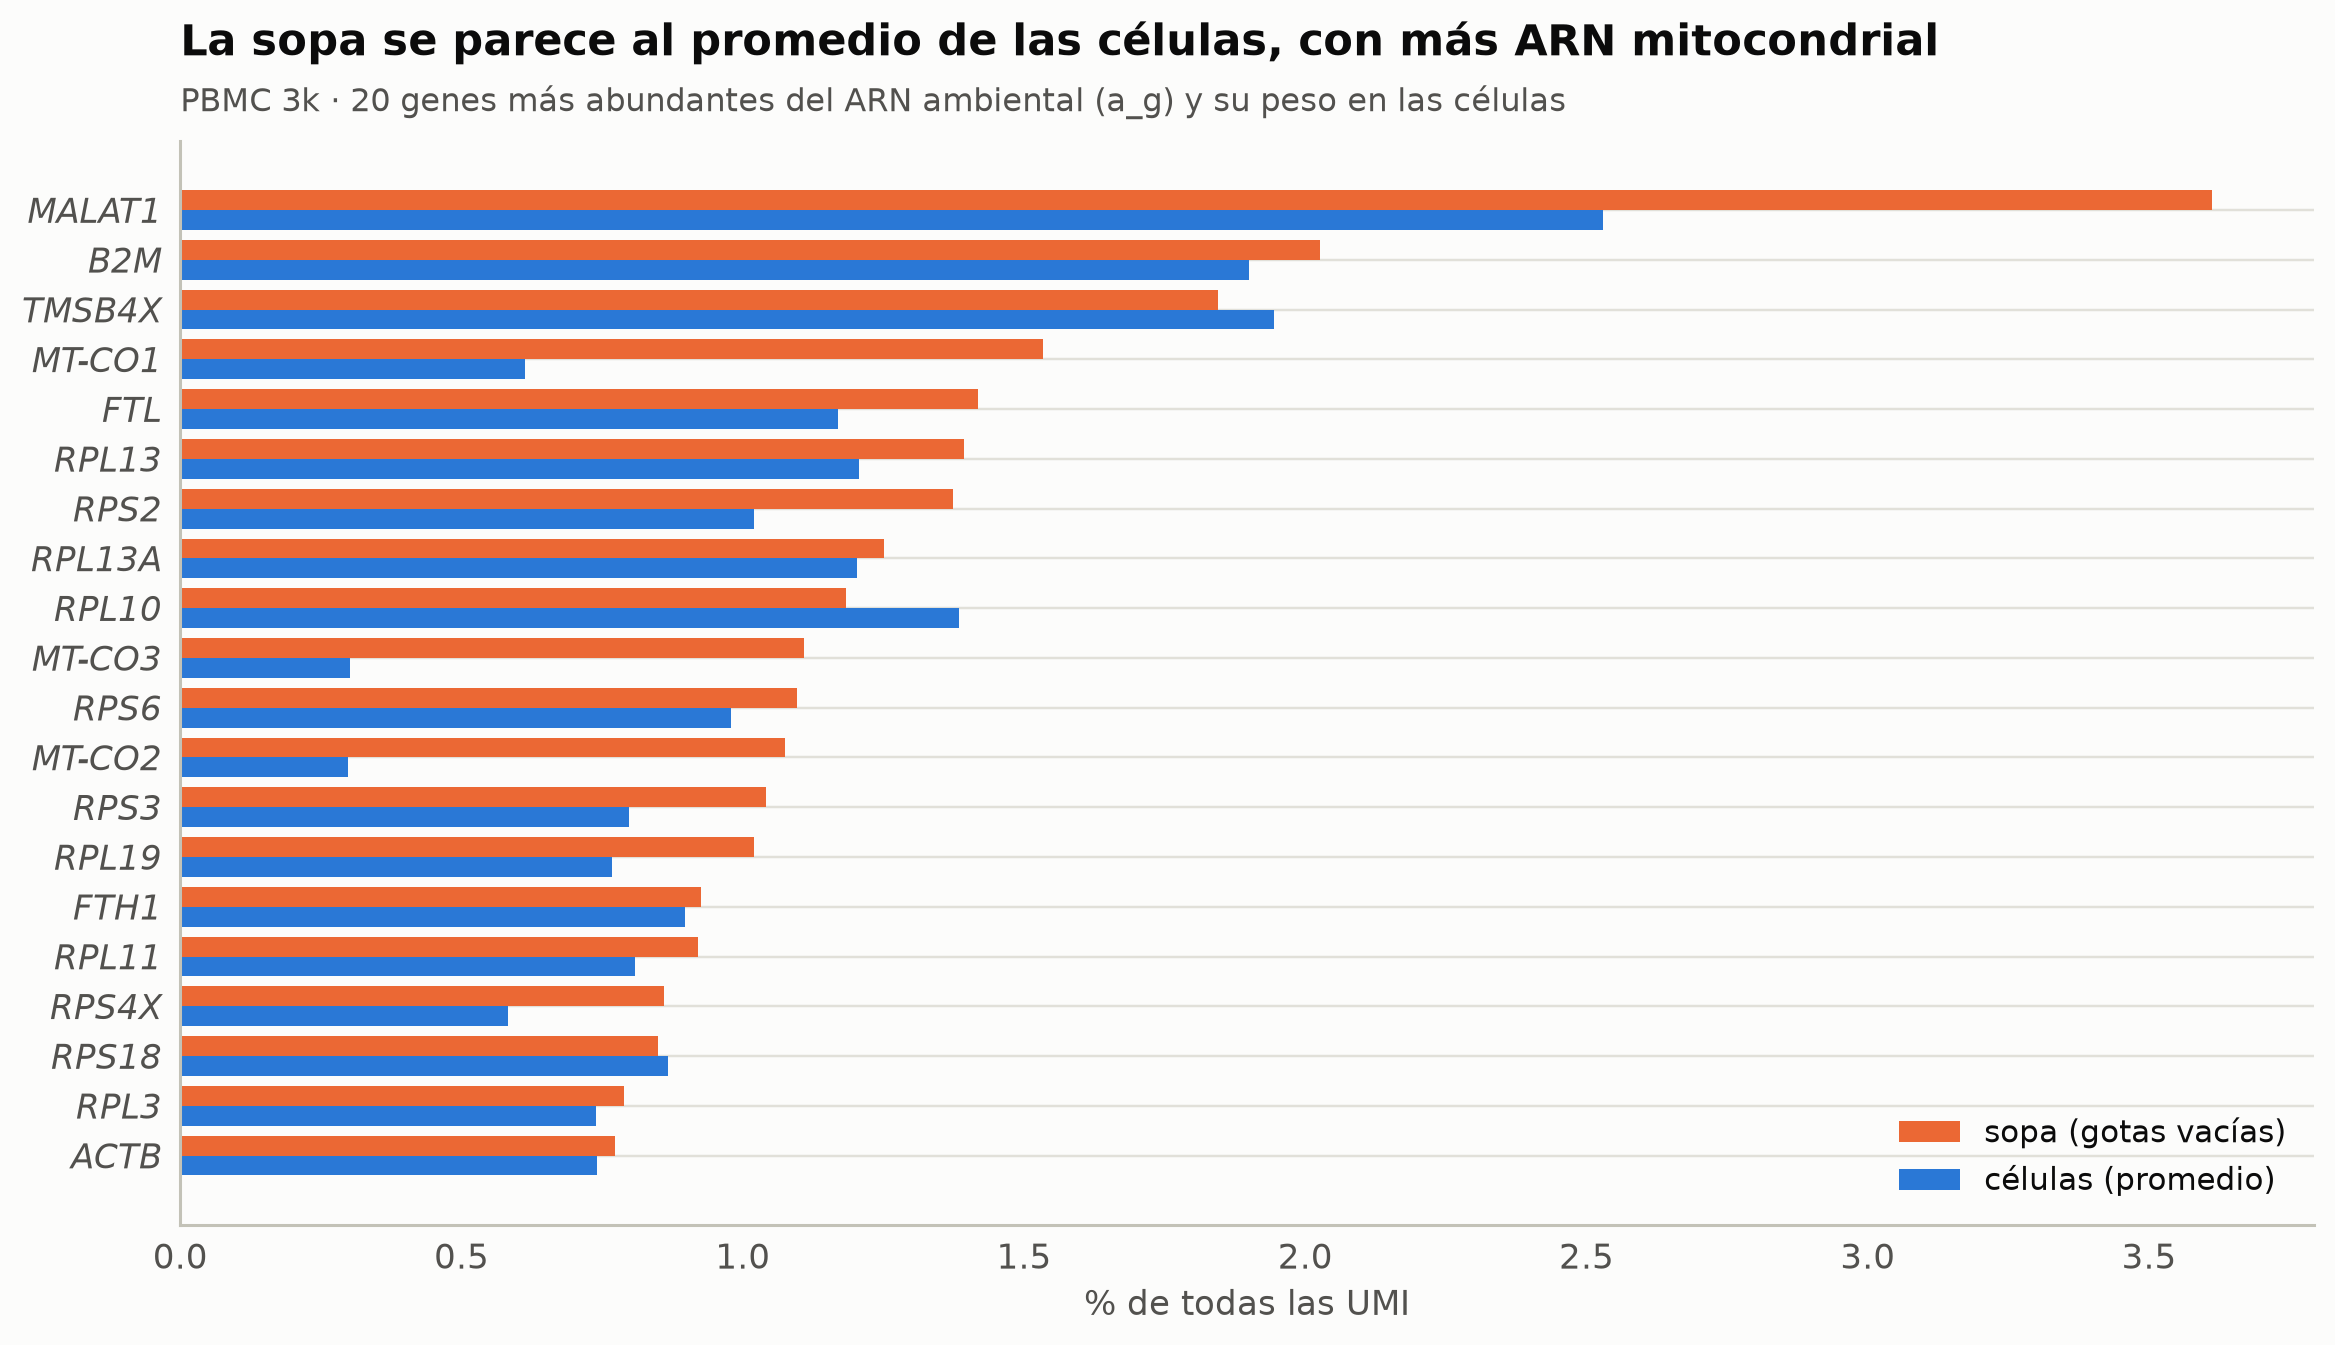

In [18]:
top = soup.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.5, 6))
y = np.arange(len(top))
ax.barh(y + 0.2, 100 * top.a_g, height=0.4, color=ec.ORANGE, label="sopa (gotas vacías)")
ax.barh(y - 0.2, 100 * top["en células"], height=0.4, color=ec.BLUE, label="células (promedio)")
ax.set_yticks(y, top.symbol, fontstyle="italic")
ax.set_xlabel("% de todas las UMI")
ax.legend(loc="lower right", frameon=False)
ec.title(ax, "La sopa se parece al promedio de las células, con más ARN mitocondrial",
         "PBMC 3k · 20 genes más abundantes del ARN ambiental (a_g) y su peso en las células")
plt.show()

> 🔎 **Qué observamos.** La sopa real está dominada por los mismos genes que dominan las células: *MALAT1* (un ARN nuclear
> muy abundante), *B2M*, *TMSB4X*, proteínas ribosómicas y ferritina (*FTL*), es decir, **ARN de células que se rompieron**.
> Los genes mitocondriales pesan más en la sopa que en las células, lo que encaja con células dañadas que liberan su
> citoplasma. Y *LYZ*, casi exclusivo de monocitos, está en la sopa: cualquier célula B o T la recibirá en pequeñas dosis.
> Volveremos a medir ese efecto con la simulación en la sección 6, cuando tengamos las células limpias.

## 5. Métricas de control de calidad y umbrales adaptativos

Ya separamos las células de las gotas vacías. Ahora el control de calidad (QC) busca células cuyo perfil **no refleja una
célula sana e individual**. Las tres métricas estándar se calculan por célula:

$$
N_c=\sum_{g} x_{cg},\qquad
D_c=\sum_g \mathbb{1}[x_{cg}>0],\qquad
m_c = 100\,\frac{\sum_{g\in\mathcal{M}} x_{cg}}{N_c}. \qquad (12.5)
$$

| Símbolo | Significado | Nombre en Scanpy |
|---|---|---|
| $N_c$ | UMI totales de la célula $c$ | `total_counts` |
| $D_c$ | Genes detectados (con al menos una UMI) | `n_genes_by_counts` |
| $\mathcal{M}$ | Genes mitocondriales (en humano, nombres que empiezan por `MT-`) | `var["mt"]` |
| $m_c$ | Porcentaje de UMI mitocondriales | `pct_counts_mt` |

Lo que las hace útiles es su **interpretación biológica**. Una célula con la membrana rota es como una bolsa de compras
con un agujero: pierde lo que estaba suelto (el ARNm citoplasmático) pero conserva lo que venía en cajas cerradas (el ARN
dentro de las mitocondrias). Su $N_c$ y su $D_c$ bajan y su $m_c$ sube. Un **doblete**, al revés, tiende a tener más UMI
y más genes que un singlete. Una gota vacía con mucho ambiente tiene pocas cuentas y un perfil mezclado.

**Un truco de CSR.** En formato CSR, $D_c$ sale gratis: el número de entradas no nulas de la fila $c$ es
`indptr[c+1] - indptr[c]`, es decir, `np.diff(indptr)`. Calculemos las tres métricas desde cero sobre la matriz real y
comparemos con `sc.pp.calculate_qc_metrics`.

In [19]:
def qc_metrics(X, is_mt):
    """N_c, D_c y m_c (ecuación 12.5) para una matriz CSR o densa (células × genes)."""
    if sparse.issparse(X):
        X = sparse.csr_matrix(X)
        X.eliminate_zeros()
        N = np.asarray(X.sum(1)).ravel()
        D = np.diff(X.indptr)                                   # entradas no nulas por fila
        mt = np.asarray(X[:, np.where(is_mt)[0]].sum(1)).ravel()
    else:
        N = X.sum(1); D = (X > 0).sum(1); mt = X[:, is_mt].sum(1)
    return N, D, 100 * mt / N

adata.var["mt"] = adata.var_names.str.startswith("MT-")
N_r, D_r, m_r = qc_metrics(adata.X, adata.var["mt"].values)
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
print(f"Genes mitocondriales: {adata.var['mt'].sum()} ({', '.join(adata.var_names[adata.var['mt']][:5])}, …)")
print("¿Coinciden con Scanpy?  N:", np.allclose(N_r, adata.obs.total_counts),
      " D:", np.array_equal(D_r, adata.obs.n_genes_by_counts), " m:", np.allclose(m_r, adata.obs.pct_counts_mt))
adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe().round(2)

Genes mitocondriales: 13 (MT-ND1, MT-ND2, MT-CO1, MT-CO2, MT-ATP8, …)
¿Coinciden con Scanpy?  N: True  D: True  m: True


,total_counts,n_genes_by_counts,pct_counts_mt
count,2700.00,2700.00,2700.00
mean,2366.90,846.99,2.22
std,1094.26,282.10,1.17
min,548.00,212.00,0.00
25%,1757.75,690.00,1.54
50%,2197.00,817.00,2.03
75%,2763.00,953.25,2.64
max,15844.00,3422.00,22.57


### Umbrales adaptativos: la desviación absoluta mediana (MAD)

¿Dónde cortar? Un umbral fijo («menos de 5 % mitocondrial») copiado de un tutorial ignora que cada tejido y cada
experimento es distinto. Las guías actuales (Heumos *et al.*, 2023) recomiendan umbrales **adaptativos**: descartar las
células que se alejan demasiado de la mayoría, midiendo «demasiado» con una escala **robusta**. La desviación estándar no
sirve, porque los propios valores atípicos que buscamos la inflan; la **MAD** (desviación absoluta mediana) apenas se mueve:

$$
\text{descartar } c \iff \bigl|\,\log N_c - \operatorname{med}(\log N)\,\bigr| > k\cdot \mathrm{MAD}(\log N),\qquad
\mathrm{MAD}(z)=1.4826\,\operatorname{med}\bigl|z-\operatorname{med}(z)\bigr|, \qquad (12.6)
$$

con $k=5$ para $N_c$ y $D_c$ (umbrales permisivos, en escala logarítmica) y una regla análoga, más estricta ($k=3$) y sólo
por arriba, para $m_c$. El factor 1.4826 hace que la MAD estime la desviación estándar cuando los datos son normales
(es $1/\Phi^{-1}(3/4)$).

| Símbolo | Significado |
|---|---|
| $\operatorname{med}$ | Mediana |
| $k$ | Número de MAD tolerados (5 para $N$ y $D$; 3 para $m$) |
| $\mathrm{MAD}(z)$ | Desviación absoluta mediana escalada de la variable $z$ |

**Un ejemplo diminuto a mano.** Cinco células con $\log N = \{7.0, 7.2, 7.4, 7.6, 4.0\}$: la mediana es 7.2; las
desviaciones absolutas, $\{0.2, 0, 0.2, 0.4, 3.2\}$, tienen mediana 0.2, así que $\mathrm{MAD}=1.4826\times0.2=0.297$. La
quinta célula está a $3.2/0.297=10.8$ MAD: se descarta con $k=5$. La desviación estándar de esos cinco valores es 1.49,
¡inflada por la propia célula anómala! Con ella (y la media, 6.64), la célula estaría a sólo 1.8 desviaciones y pasaría.

(En la práctica, igual que en el libro, usamos $\log(1+N)$, que evita problemas con ceros y es casi idéntico a $\log N$
para miles de UMI.)

In [20]:
def mad(x):
    """Desviación absoluta mediana escalada (estima σ si los datos son normales)."""
    return 1.4826 * np.median(np.abs(x - np.median(x)))

z = np.array([7.0, 7.2, 7.4, 7.6, 4.0])
print(f"Ejemplo: mediana {np.median(z)}, MAD {mad(z):.3f}, célula 5 a {abs(4.0-np.median(z))/mad(z):.1f} MAD; "
      f"con la desviación estándar ({z.std(ddof=1):.2f}) estaría a {abs(4.0-z.mean())/z.std(ddof=1):.1f} σ")

def mad_thresholds(N, D, m, k_nd=5, k_mt=3, mt_floor=8.0):
    """Umbrales del libro: 5 MAD en log(1+N) y log(1+D); mediana + 3 MAD para m (con un piso de 8 %)."""
    lN, lD = np.log1p(N), np.log1p(D)
    thr = {"N": (np.expm1(np.median(lN) - k_nd * mad(lN)), np.expm1(np.median(lN) + k_nd * mad(lN))),
           "D": (np.expm1(np.median(lD) - k_nd * mad(lD)), np.expm1(np.median(lD) + k_nd * mad(lD))),
           "m_mad": np.median(m) + k_mt * mad(m)}
    thr["m"] = max(thr["m_mad"], mt_floor)
    keep = ((N >= thr["N"][0]) & (N <= thr["N"][1]) & (D >= thr["D"][0]) & (D <= thr["D"][1]) & (m < thr["m"]))
    return thr, keep

Ejemplo: mediana 7.2, MAD 0.297, célula 5 a 10.8 MAD; con la desviación estándar (1.49) estaría a 1.8 σ


### 📝 Ejemplo resuelto del libro: QC adaptativo sobre la simulación

Aplicamos la regla a los 3 360 códigos con célula de la simulación. El libro obtiene: mediana de **2 763 UMI, 933 genes y
3.89 % mitocondrial**; MAD de $\log N$ = **0.519**; umbrales de UMI entre **205 y 37 117**, de genes entre **274 y 3 171**,
y porcentaje mitocondrial menor que **8.52 %**. Se descartan las 150 células dañadas (el 100 %) y 35 de las 3 000 sanas
(1.2 %), y quedan **3 175**. Pero los 210 dobletes pasan todos.

> 🤔 **Antes de ejecutar, prediga.** ¿Por qué cree que ningún doblete supera el umbral superior de UMI, si un doblete
> tiene el doble de moléculas que una célula?

In [21]:
N_s, D_s, m_s = qc_metrics(Xall, np.arange(NG) < NMT)
thr_s, keep = mad_thresholds(N_s, D_s, m_s)
print(f"Medianas: {np.median(N_s):.0f} UMI · {np.median(D_s):.0f} genes · {np.median(m_s):.2f} % mt;  "
      f"MAD(log N) = {mad(np.log1p(N_s)):.3f}")
print(f"Umbrales: UMI [{thr_s['N'][0]:.0f}, {thr_s['N'][1]:.0f}] · genes [{thr_s['D'][0]:.0f}, {thr_s['D'][1]:.0f}] · "
      f"% mt < {thr_s['m']:.2f} (mediana + 3 MAD = {thr_s['m_mad']:.2f})")
names_est = {"ok": "sanas", "baja": "dañadas", "dob_hetero": "dobletes heterotípicos", "dob_homo": "dobletes homotípicos"}
tab = pd.DataFrame([{"grupo (verdad simulada)": names_est[e], "n": int((est == e).sum()),
                     "descartadas": int((~keep & (est == e)).sum()),
                     "% descartadas": 100 * (~keep[est == e]).mean()} for e in names_est])
print(tab.round(1).to_string(index=False))
print(f"Retenidas: {keep.sum()} de {len(keep)}")

Medianas: 2763 UMI · 933 genes · 3.89 % mt;  MAD(log N) = 0.519
Umbrales: UMI [205, 37117] · genes [274, 3171] · % mt < 8.52 (mediana + 3 MAD = 8.52)
grupo (verdad simulada)    n  descartadas  % descartadas
                  sanas 3000           35            1.2
                dañadas  150          150          100.0
 dobletes heterotípicos  171            0            0.0
   dobletes homotípicos   39            0            0.0
Retenidas: 3175 de 3360


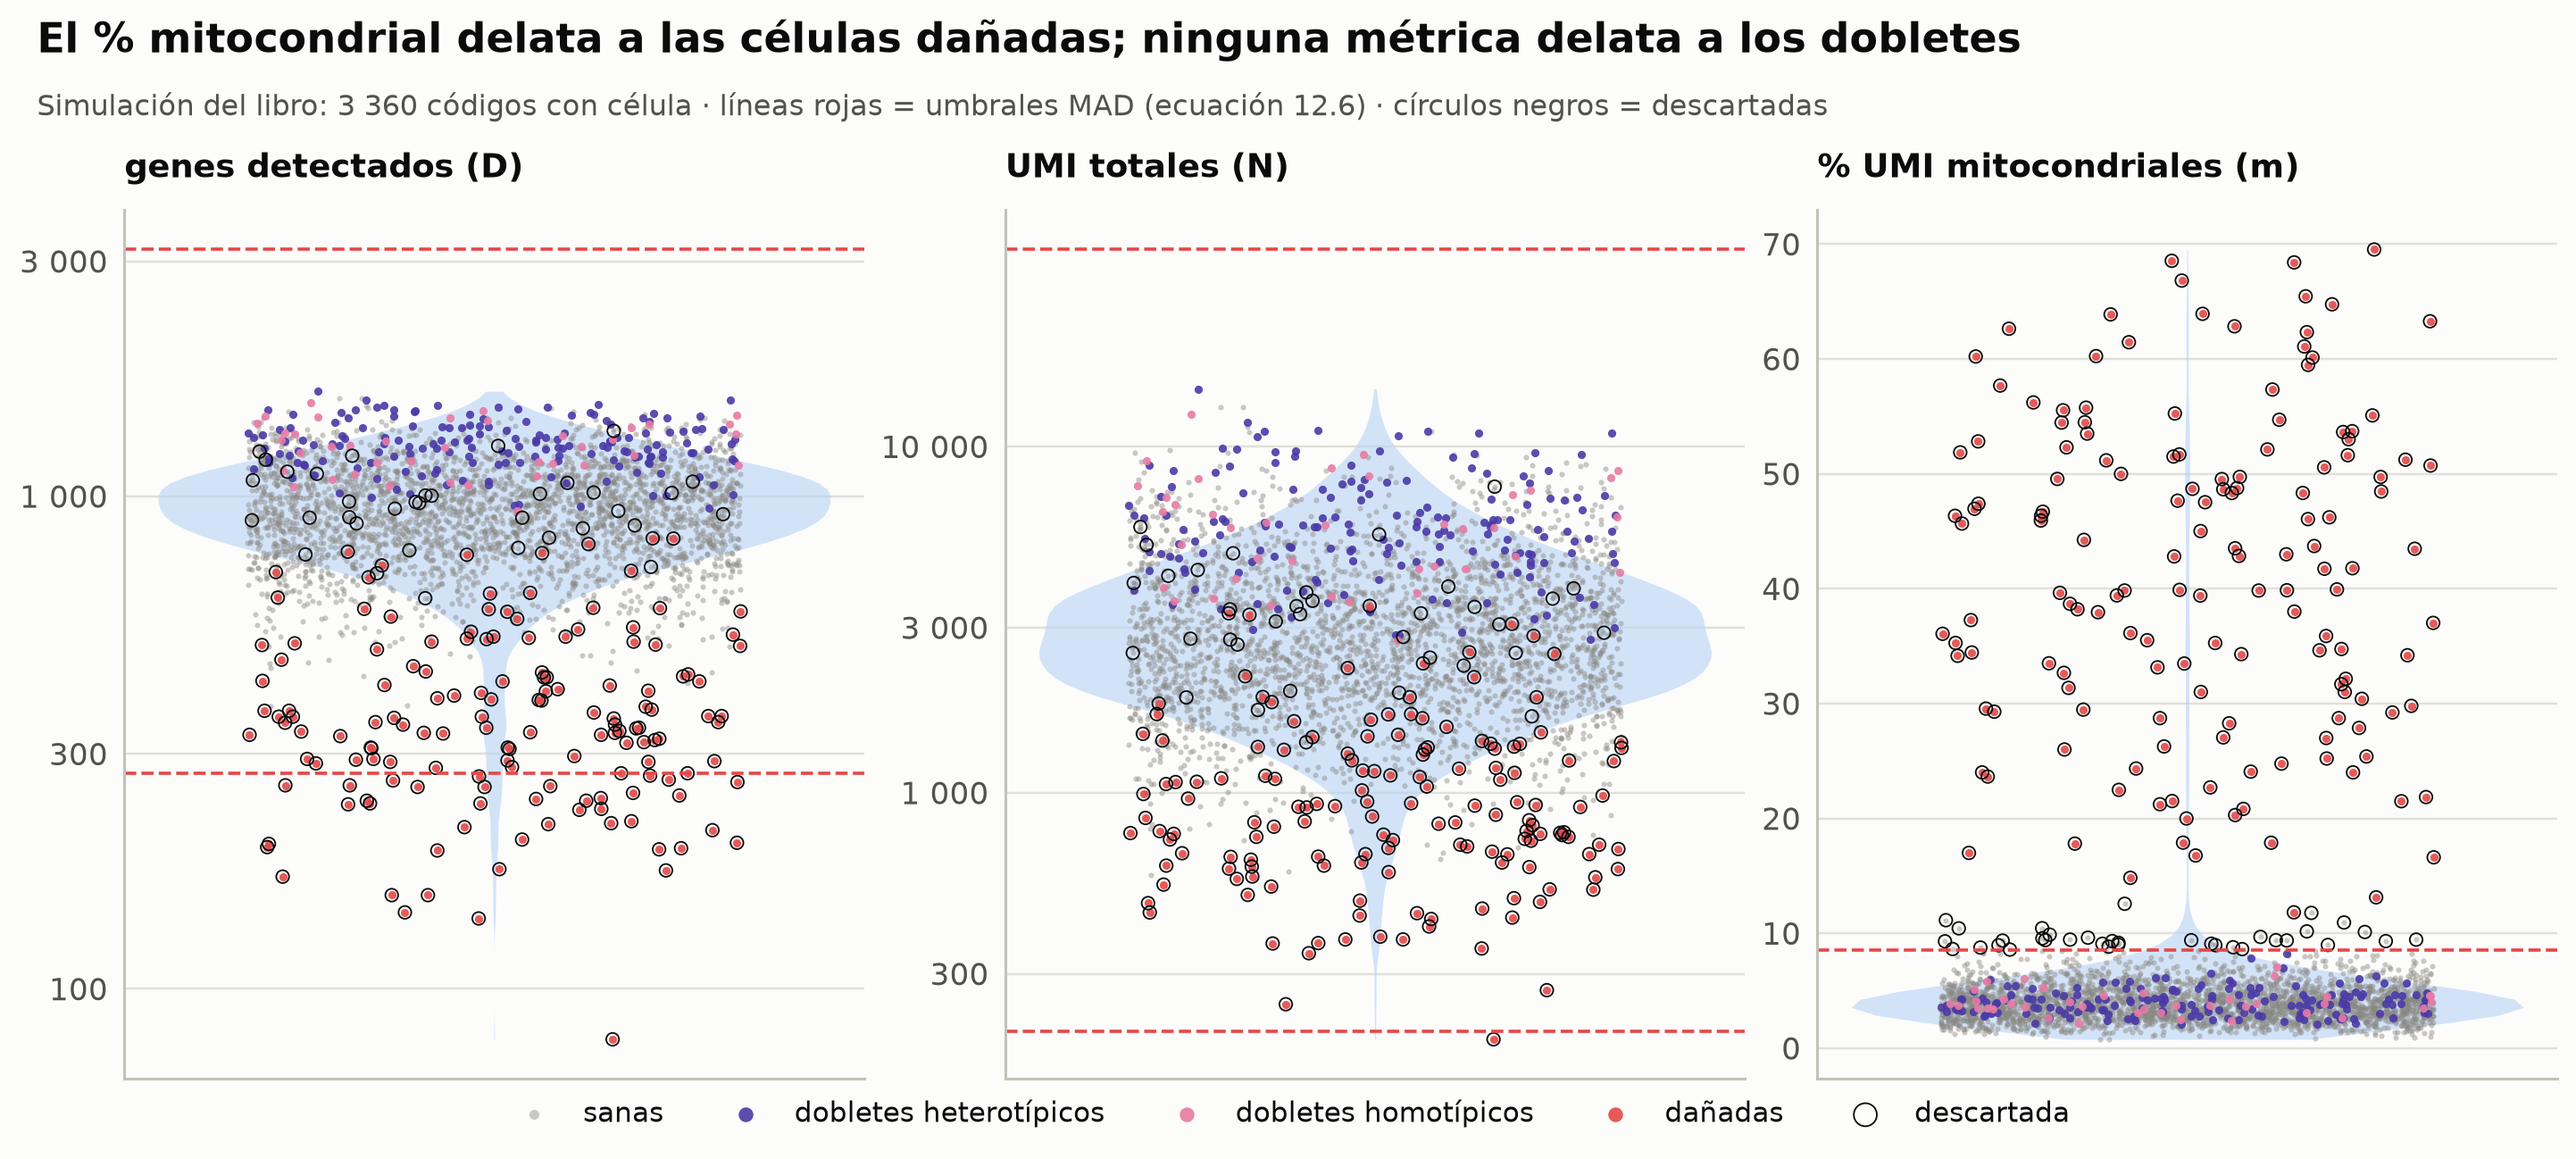

In [22]:
status_col = {"ok": ec.MUTED, "baja": ec.RED, "dob_hetero": ec.VIOLET, "dob_homo": ec.MAGENTA}
fig, axs = plt.subplots(1, 3, figsize=(13, 4.8))
rng_v = np.random.default_rng(3)
jit = rng_v.uniform(-0.33, 0.33, len(N_s))
for ax, (v, lab, thr, logy) in zip(axs, [(D_s, "genes detectados (D)", thr_s["D"], True),
                                         (N_s, "UMI totales (N)", thr_s["N"], True),
                                         (m_s, "% UMI mitocondriales (m)", [thr_s["m"]], False)]):
    vv = np.log10(v) if logy else v
    parts = ax.violinplot(vv, positions=[0], widths=0.9, showextrema=False)
    for b in parts["bodies"]:
        b.set_facecolor(ec.SEQ_BLUE[1]); b.set_edgecolor(ec.BLUE); b.set_alpha(0.6)
    for e in ["ok", "dob_hetero", "dob_homo", "baja"]:
        s_ = est == e
        ax.scatter(jit[s_], vv[s_], s=4 if e == "ok" else 9, color=status_col[e], alpha=0.45 if e == "ok" else 0.9,
                   lw=0, label=names_est[e])
    ax.scatter(jit[~keep], vv[~keep], s=22, facecolor="none", edgecolor=ec.INK, lw=0.6, label="descartada")
    for t in thr:
        ax.axhline(np.log10(t) if logy else t, color=ec.RED, ls="--", lw=1.2)
    if logy:
        tk = [t for t in (100, 300, 1000, 3000, 10000, 30000) if vv.min() - .1 <= np.log10(t) <= vv.max() + .3]
        ax.set_yticks(np.log10(tk), [f"{t:,}".replace(",", " ") for t in tk])
    ax.set_xticks([]); ax.set_title(lab, fontsize=12)
h_, l_ = axs[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.07), frameon=False, markerscale=1.8)
ec.fig_title(fig, "El % mitocondrial delata a las células dañadas; ninguna métrica delata a los dobletes",
             "Simulación del libro: 3 360 códigos con célula · líneas rojas = umbrales MAD (ecuación 12.6) · "
             "círculos negros = descartadas")
plt.show()

> 🔎 **Qué observamos.** En el panel del porcentaje mitocondrial las células dañadas (rojo) forman una cola clara por
> encima del umbral de 8.52 %. En los paneles de genes y UMI se confunden con las células sanas pequeñas: sin la métrica
> mitocondrial, muchas pasarían. Y los dobletes (violeta y rosa) están arriba en genes y UMI, pero **dentro** de los
> umbrales. La respuesta a la predicción: la variabilidad natural del tamaño celular (unas tres veces entre monocitos y
> linfocitos, más la dispersión técnica) ya cubre el aumento al doble. El QC univariante no detecta dobletes; hará falta
> la sección 6.

¿Y el valor de $k$? Es un compromiso entre descartar células dañadas y perder células sanas. La animación recorre $k$ de
0.5 a 6 aplicando la **misma** $k$ al límite inferior de $\log N$ y al superior de $m$ (sin el piso de 8 %), y lleva la
cuenta con la verdad simulada.

![Al subir k, el umbral se aleja de la mediana: se pierden menos células sanas, pero a partir de cierto punto empiezan a escaparse las dañadas.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.1_umbral_mad.gif)

*Al subir k, el umbral se aleja de la mediana: se pierden menos células sanas, pero a partir de cierto punto empiezan a escaparse las dañadas.*

In [23]:
lN_s = np.log1p(N_s)
ks = np.linspace(0.5, 6, 45)
def rule(k):
    return (lN_s < np.median(lN_s) - k * mad(lN_s)) | (m_s > np.median(m_s) + k * mad(m_s))
curves = np.array([[100 * rule(k)[est == "baja"].mean(), 100 * rule(k)[est == "ok"].mean()] for k in ks])
fig, (axa, axb) = plt.subplots(1, 2, figsize=(12.5, 5), gridspec_kw={"width_ratios": [1.2, 1]})
def update(f):
    k = ks[f]; out = rule(k)
    axa.clear(); axb.clear()
    for e in ["ok", "dob_hetero", "dob_homo", "baja"]:
        s_ = est == e
        axa.scatter(N_s[s_], m_s[s_], s=5 if e == "ok" else 10, color=status_col[e], alpha=0.5, lw=0)
    axa.scatter(N_s[out], m_s[out], s=26, facecolor="none", edgecolor=ec.INK, lw=0.6)
    axa.axvline(np.expm1(np.median(lN_s) - k * mad(lN_s)), color=ec.RED, ls="--")
    axa.axhline(np.median(m_s) + k * mad(m_s), color=ec.RED, ls="--")
    axa.set_xscale("log"); axa.set_yscale("log"); axa.set_ylim(1, 80); axa.set_xlim(80, 6e4)
    axa.set_xlabel("UMI totales (N)"); axa.set_ylabel("% mitocondrial (m)")
    axa.text(100, 55, "dañadas", color=ec.RED, fontsize=11); axa.text(2e4, 1.3, "sanas y dobletes", color=ec.INK_2, fontsize=11)
    ec.title(axa, f"k = {k:.2f}: {out.sum()} células descartadas", "círculos negros = fuera de los umbrales")
    axb.plot(ks, curves[:, 0], color=ec.RED, lw=2.5); axb.plot(ks, curves[:, 1], color=ec.BLUE, lw=2.5)
    axb.scatter([k, k], curves[f], color=[ec.RED, ec.BLUE], s=60, zorder=3)
    axb.axvline(k, color=ec.GRID)
    axb.text(3.8, curves[-1, 0] - 12, "% de dañadas\ndescartadas", color=ec.RED, fontsize=11)
    axb.text(3.8, 25, "% de sanas\ndescartadas", color=ec.BLUE, fontsize=11)
    axb.set_ylim(-3, 105); axb.set_xlabel("k (número de MAD)"); axb.set_ylabel("%")
    ec.title(axb, "Sensibilidad contra pérdida", "Verdad simulada: 150 dañadas y 3 000 sanas")
ec.animate(fig, update, frames=len(ks), interval=160, name="12.1_umbral_mad")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con $k<1$ se descarta casi la mitad de las células sanas (¡la regla corta en plena
> distribución!). La curva azul cae rápido y la roja se mantiene cerca del 100 % durante un amplio intervalo: las
> dañadas están tan lejos que casi cualquier $k$ razonable las atrapa. Por eso el libro usa $k$ generosos (5 para $N$ y
> $D$, 3 para $m$): perder células sanas es caro (pueden ser una población rara) y las dañadas siguen detectándose.

### 🧪 El QC sobre PBMC 3k real

Ahora aplicamos la misma función a las 2 700 células reales.

In [24]:
N_r, D_r, m_r = adata.obs.total_counts.values, adata.obs.n_genes_by_counts.values, adata.obs.pct_counts_mt.values
thr_r, keep_r = mad_thresholds(N_r, D_r, m_r)
print(f"Medianas reales: {np.median(N_r):.0f} UMI · {np.median(D_r):.0f} genes · {np.median(m_r):.2f} % mt;  "
      f"MAD(log N) = {mad(np.log1p(N_r)):.3f}")
print(f"Umbrales: UMI [{thr_r['N'][0]:.0f}, {thr_r['N'][1]:.0f}] · genes [{thr_r['D'][0]:.0f}, {thr_r['D'][1]:.0f}] · "
      f"% mt: mediana + 3 MAD = {thr_r['m_mad']:.2f} → con el piso de 8 %: < {thr_r['m']:.1f}")
reason = np.select([(N_r < thr_r["N"][0]) | (N_r > thr_r["N"][1]), (D_r < thr_r["D"][0]) | (D_r > thr_r["D"][1]),
                    m_r >= thr_r["m"]], ["UMI fuera de rango", "genes fuera de rango", "% mitocondrial alto"], "pasa")
adata.obs["qc"] = reason
print(pd.Series(reason).value_counts().to_string())
print(f"\nSin el piso de 8 %, el umbral de {thr_r['m_mad']:.2f} % descartaría {int((m_r >= thr_r['m_mad']).sum())} células.")
classic = (D_r > 200) & (D_r < 2500) & (m_r < 5)
print(f"Umbrales fijos del tutorial clásico (200 < genes < 2 500 y mt < 5 %): quedan {classic.sum()} células.")
print(f"Nuestro QC adaptativo: quedan {keep_r.sum()} de {len(keep_r)} células.")

Medianas reales: 2197 UMI · 817 genes · 2.03 % mt;  MAD(log N) = 0.335
Umbrales: UMI [410, 11758] · genes [249, 2679] · % mt: mediana + 3 MAD = 4.43 → con el piso de 8 %: < 8.0
pasa                    2683
% mitocondrial alto        9
genes fuera de rango       6
UMI fuera de rango         2

Sin el piso de 8 %, el umbral de 4.43 % descartaría 93 células.
Umbrales fijos del tutorial clásico (200 < genes < 2 500 y mt < 5 %): quedan 2638 células.
Nuestro QC adaptativo: quedan 2683 de 2700 células.


> 🔎 **Qué observamos.** Los PBMC 3k están muy limpios: la mediana mitocondrial es de apenas ~2 % y su distribución es
> tan estrecha que la regla «mediana + 3 MAD» caería en ~4.4 % y descartaría 93 células sanas de aspecto normal. Es el
> caso que advierte el libro en **«Los umbrales dependen del tejido»**: por eso aplicamos, como el código del libro, un piso
> de 8 %. Con la regla adaptativa quedan 2 683 células; con los umbrales fijos del tutorial clásico, 2 638. Las dos
> decisiones difieren sobre todo en células con 5–8 % de ARN mitocondrial y en unas pocas células con muchos genes (que
> el tutorial clásico corta en 2 500 pensando en dobletes).

> ⚠️ **Los umbrales dependen del tejido.** No existe un porcentaje mitocondrial «correcto». Cardiomiocitos, hepatocitos o
> células renales tienen de forma natural alta carga mitocondrial, y un umbral del 5 % copiado de un tutorial de sangre
> eliminaría justo las células de interés. Del mismo modo, una población rara de células pequeñas (neutrófilos, plaquetas)
> puede caer por debajo del umbral inferior de genes. Mire siempre las distribuciones por muestra, descarte con umbrales
> permisivos y revise después si algún grupo de células está definido sólo por métricas de calidad.

El explorador muestra cada célula real en el plano $N_c$–$m_c$; el color indica la decisión y el globo, el motivo.

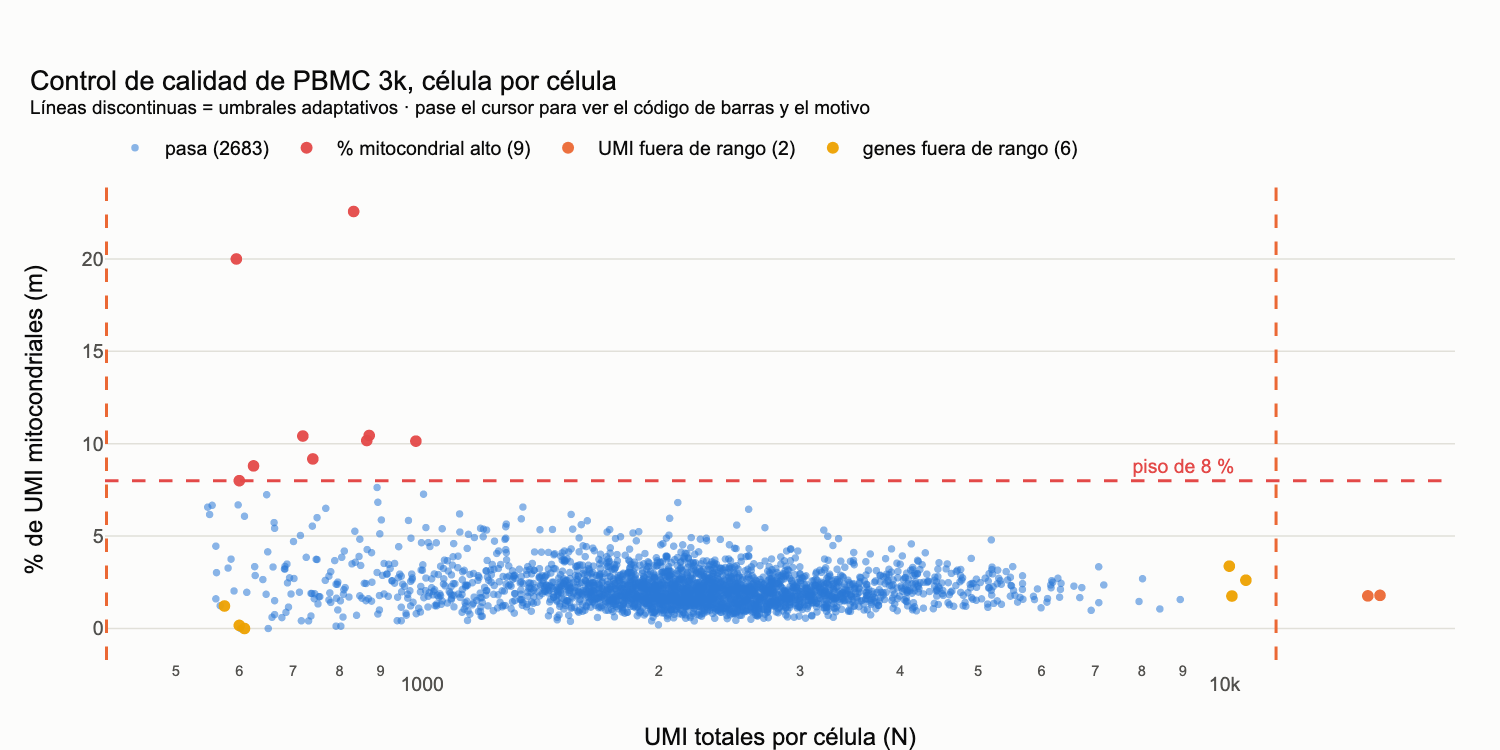

In [25]:
obs = adata.obs.copy()
obs["barcode"] = adata.obs_names
dec_col = {"pasa": ec.BLUE, "% mitocondrial alto": ec.RED, "UMI fuera de rango": ec.ORANGE, "genes fuera de rango": ec.YELLOW}
figq = go.Figure()
for dname, col in dec_col.items():
    o_ = obs[obs.qc == dname]
    if len(o_) == 0:
        continue
    figq.add_trace(go.Scattergl(
        x=o_.total_counts, y=o_.pct_counts_mt, mode="markers", name=f"{dname} ({len(o_)})",
        marker=dict(color=col, size=5 if dname == "pasa" else 8, opacity=0.55 if dname == "pasa" else 0.95),
        customdata=np.c_[o_.barcode, o_.n_genes_by_counts, o_.total_counts / o_.n_genes_by_counts],
        hovertemplate=("<b>%{customdata[0]}</b><br>N = %{x:,.0f} UMI · D = %{customdata[1]} genes"
                       "<br>m = %{y:.2f} % mitocondrial<br>UMI por gen detectado = %{customdata[2]:.2f}"
                       f"<br>decisión: {dname}<extra></extra>")))
figq.add_hline(y=thr_r["m"], line=dict(color=ec.RED, dash="dash"))
figq.add_vline(x=thr_r["N"][0], line=dict(color=ec.ORANGE, dash="dash"))
figq.add_vline(x=thr_r["N"][1], line=dict(color=ec.ORANGE, dash="dash"))
figq.add_annotation(x=np.log10(9000), y=thr_r["m"], text="piso de 8 %", showarrow=False, yshift=10,
                    font=dict(color=ec.RED))
figq.update_xaxes(type="log", title="UMI totales por célula (N)")
figq.update_yaxes(title="% de UMI mitocondriales (m)")
figq.update_layout(title="Control de calidad de PBMC 3k, célula por célula<br><sup>Líneas discontinuas = umbrales "
                         "adaptativos · pase el cursor para ver el código de barras y el motivo</sup>", height=500,
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=70, r=30, b=60))
figq.show()

> ✅ **Compruebe su comprensión.** (1) ¿Por qué se aplica la MAD a $\log N$ y no a $N$? (2) Una célula tiene 700 UMI y
> 15 % mitocondrial; otra, 700 UMI y 2 %. ¿Cuál es más probable que esté dañada, y por qué no basta con mirar $N$?
> *(Respuestas: (1) porque $N$ es muy asimétrico, con cola larga hacia arriba; en escala logarítmica la distribución es
> casi simétrica y la mediana ± k MAD tiene sentido por ambos lados. (2) La primera: perdió ARNm citoplasmático y conservó
> el mitocondrial; la segunda puede ser simplemente una célula pequeña, como un linfocito en reposo.)*

## 6. Dobletes: Scrublet desde cero

Los dobletes **heterotípicos** (dos tipos celulares distintos) son peligrosos porque parecen un estado intermedio o un
tipo celular nuevo que no existe: un «monocito-linfocito T» sería un hallazgo espectacular… y falso. Los **homotípicos**
(dos células del mismo tipo) son casi indistinguibles de una célula grande, pero también mucho menos dañinos.

Scrublet (Wolock *et al.*, 2019) ataca el problema con una idea sencilla: si no sabemos cómo es un doblete real,
**fabriquemos dobletes artificiales** sumando los perfiles de pares de células elegidas al azar, y preguntemos a cada
célula observada cuántos de sus vecinos más cercanos son artificiales. Si en el espacio combinado hay $r$ dobletes
simulados por cada célula observada y $q_c$ es la fracción de vecinos simulados de la célula $c$, la puntuación ajustada por
la tasa esperada $\rho$ es

$$
s_c = \frac{q_c\,\rho/r}{1-\rho-q_c\,(1-\rho-\rho/r)}. \qquad (12.7)
$$

| Símbolo | Significado |
|---|---|
| $q_c$ | Fracción de los $k$ vecinos más cercanos de $c$ que son dobletes simulados |
| $r$ | Razón entre el número de dobletes simulados y el de células observadas |
| $\rho$ | Tasa de dobletes esperada, fijada según la carga del experimento (ecuación 12.2) |
| $s_c$ | Probabilidad estimada de que $c$ sea un doblete |

Es la **regla de Bayes**: la densidad de dobletes simulados alrededor de $c$ (corregida por $r$) frente a la de singletes
observados, con $\rho$ como probabilidad previa.

**A mano.** Con $k=28$ vecinos, $r=2$ y $\rho=0.07$: si 2 de los 28 vecinos son simulados, $q=0.071$ y
$s = \dfrac{0.071\times0.035}{0.93-0.071\times(0.93-0.035)} = \dfrac{0.0025}{0.866}=0.0029$. Si son 14 de 28 ($q=0.5$),
$s=\dfrac{0.0175}{0.93-0.4475}=0.036$; y si son 26 de 28 ($q=0.929$), $s=\dfrac{0.0325}{0.93-0.831}=0.33$. Observe lo
exigente que es: incluso con la mitad de los vecinos simulados, la probabilidad sigue siendo baja, porque se esperaba que
hubiera el **doble** de simulados que de observados ($r=2$) y que sólo el 7 % de las células fueran dobletes.

In [26]:
def scrublet_score(q, r, rho):
    return q * rho / r / (1 - rho - q * (1 - rho - rho / r))

for j in (2, 14, 26):
    print(f"{j:>2}/28 vecinos simulados → q = {j/28:.3f} → s = {scrublet_score(j/28, 2, 0.07):.4f}")

 2/28 vecinos simulados → q = 0.071 → s = 0.0029
14/28 vecinos simulados → q = 0.500 → s = 0.0363
26/28 vecinos simulados → q = 0.929 → s = 0.3285


Ahora el procedimiento completo, tal como lo implementa el libro sobre las 3 175 células que pasaron el QC:

1. Normalizar ($\log(1+\text{CP10k})$, sección 7), elegir 500 genes altamente variables (sección 8), estandarizar y
   proyectar en 30 componentes principales (Lección 12.2).
2. Simular $r\cdot n$ dobletes sumando las **cuentas crudas** de dos células al azar y proyectarlos en los **mismos** ejes.
3. Buscar los $k=\operatorname{round}(0.5\sqrt{n})=28$ vecinos de cada célula observada entre observadas y simuladas.
4. Calcular $q_c$ y $s_c$.

(Usamos algunas herramientas de las secciones 7 y 8 antes de explicarlas del todo; Scrublet las necesita.)

In [27]:
def lognorm(X, target=1e4):
    """Ecuación 12.9: log(1 + x / N · 10^4) para una matriz densa."""
    tot = X.sum(1, keepdims=True)
    return np.log1p(X / tot * target)

def hvg_from_moments(mu, var, n_top=500, nbins=20, exclude=None, min_mean=0.0):
    """Dispersión normalizada por intervalos (cuantiles) de media, sabor 'seurat' (ecuación 12.13)."""
    disp = np.log(np.where(mu > 0, var / np.maximum(mu, 1e-12), 1e-12))
    lmu = np.log1p(mu)
    bins = np.quantile(lmu[mu > 0], np.linspace(0, 1, nbins + 1))
    z = np.full(len(mu), -np.inf)
    lab = np.clip(np.digitize(lmu, bins[1:-1]), 0, nbins - 1)
    for b in range(nbins):
        m = (lab == b) & (mu > 0)
        if m.sum() > 1:
            z[m] = (disp[m] - disp[m].mean()) / (disp[m].std() + 1e-9)
    if exclude is not None:
        z[exclude] = -np.inf               # los genes mitocondriales no son candidatos
    z[mu < min_mean] = -np.inf             # opcional: descartar genes casi no detectados (ruido de muestreo)
    return np.argsort(-z)[:n_top], lmu, z

def hvg(Y, n_top=500, nbins=20):
    E = np.expm1(Y)
    return hvg_from_moments(E.mean(0), E.var(0, ddof=1), n_top, nbins, exclude=np.arange(NMT))

# --- Scrublet del libro sobre las células que pasan el QC
Xq, tq, eq = Xall[keep], tall[keep], est[keep]
rng_d = np.random.default_rng(5)
Yq = lognorm(Xq)
gq, _, _ = hvg(Yq, 500)
Zo = Yq[:, gq]
mu_, sd_ = Zo.mean(0), Zo.std(0) + 1e-9
Zs = (Zo - mu_) / sd_
U, S, Vt = np.linalg.svd(Zs, full_matrices=False)
Po = Zs @ Vt[:30].T                                           # células observadas en 30 PCs
n_sim = 2 * len(Xq)
i1, i2 = rng_d.integers(0, len(Xq), n_sim), rng_d.integers(0, len(Xq), n_sim)
Xsim = Xq[i1] + Xq[i2]                                       # dobletes artificiales: suma de cuentas crudas
Ps = ((lognorm(Xsim)[:, gq] - mu_) / sd_) @ Vt[:30].T        # proyectados en los mismos ejes
k_d = int(round(0.5 * math.sqrt(len(Xq))))
nn_d = NearestNeighbors(n_neighbors=k_d).fit(np.vstack([Po, Ps]))
_, idd = nn_d.kneighbors(Po)
q_obs = (idd >= len(Po)).mean(1)
r_ratio, rho = n_sim / len(Po), 0.07
score = scrublet_score(q_obs, r_ratio, rho)
_, idsim = nn_d.kneighbors(Ps)
score_sim = scrublet_score((idsim[:, 1:] >= len(Po)).mean(1), r_ratio, rho)   # se excluye a sí mismo
thr_d = 0.25
print(f"k = {k_d}, r = {r_ratio:.1f}, ρ = {rho}, umbral = {thr_d}")
for e in ["dob_hetero", "dob_homo", "ok"]:
    print(f"  {names_est[e]:<24} marcados: {100*np.mean(score[eq == e] > thr_d):5.2f} %   "
          f"mediana de s: {np.median(score[eq == e]):.3f}")

k = 28, r = 2.0, ρ = 0.07, umbral = 0.25
  dobletes heterotípicos   marcados: 40.94 %   mediana de s: 0.239
  dobletes homotípicos     marcados: 12.82 %   mediana de s: 0.148
  sanas                    marcados:  0.51 %   mediana de s: 0.027


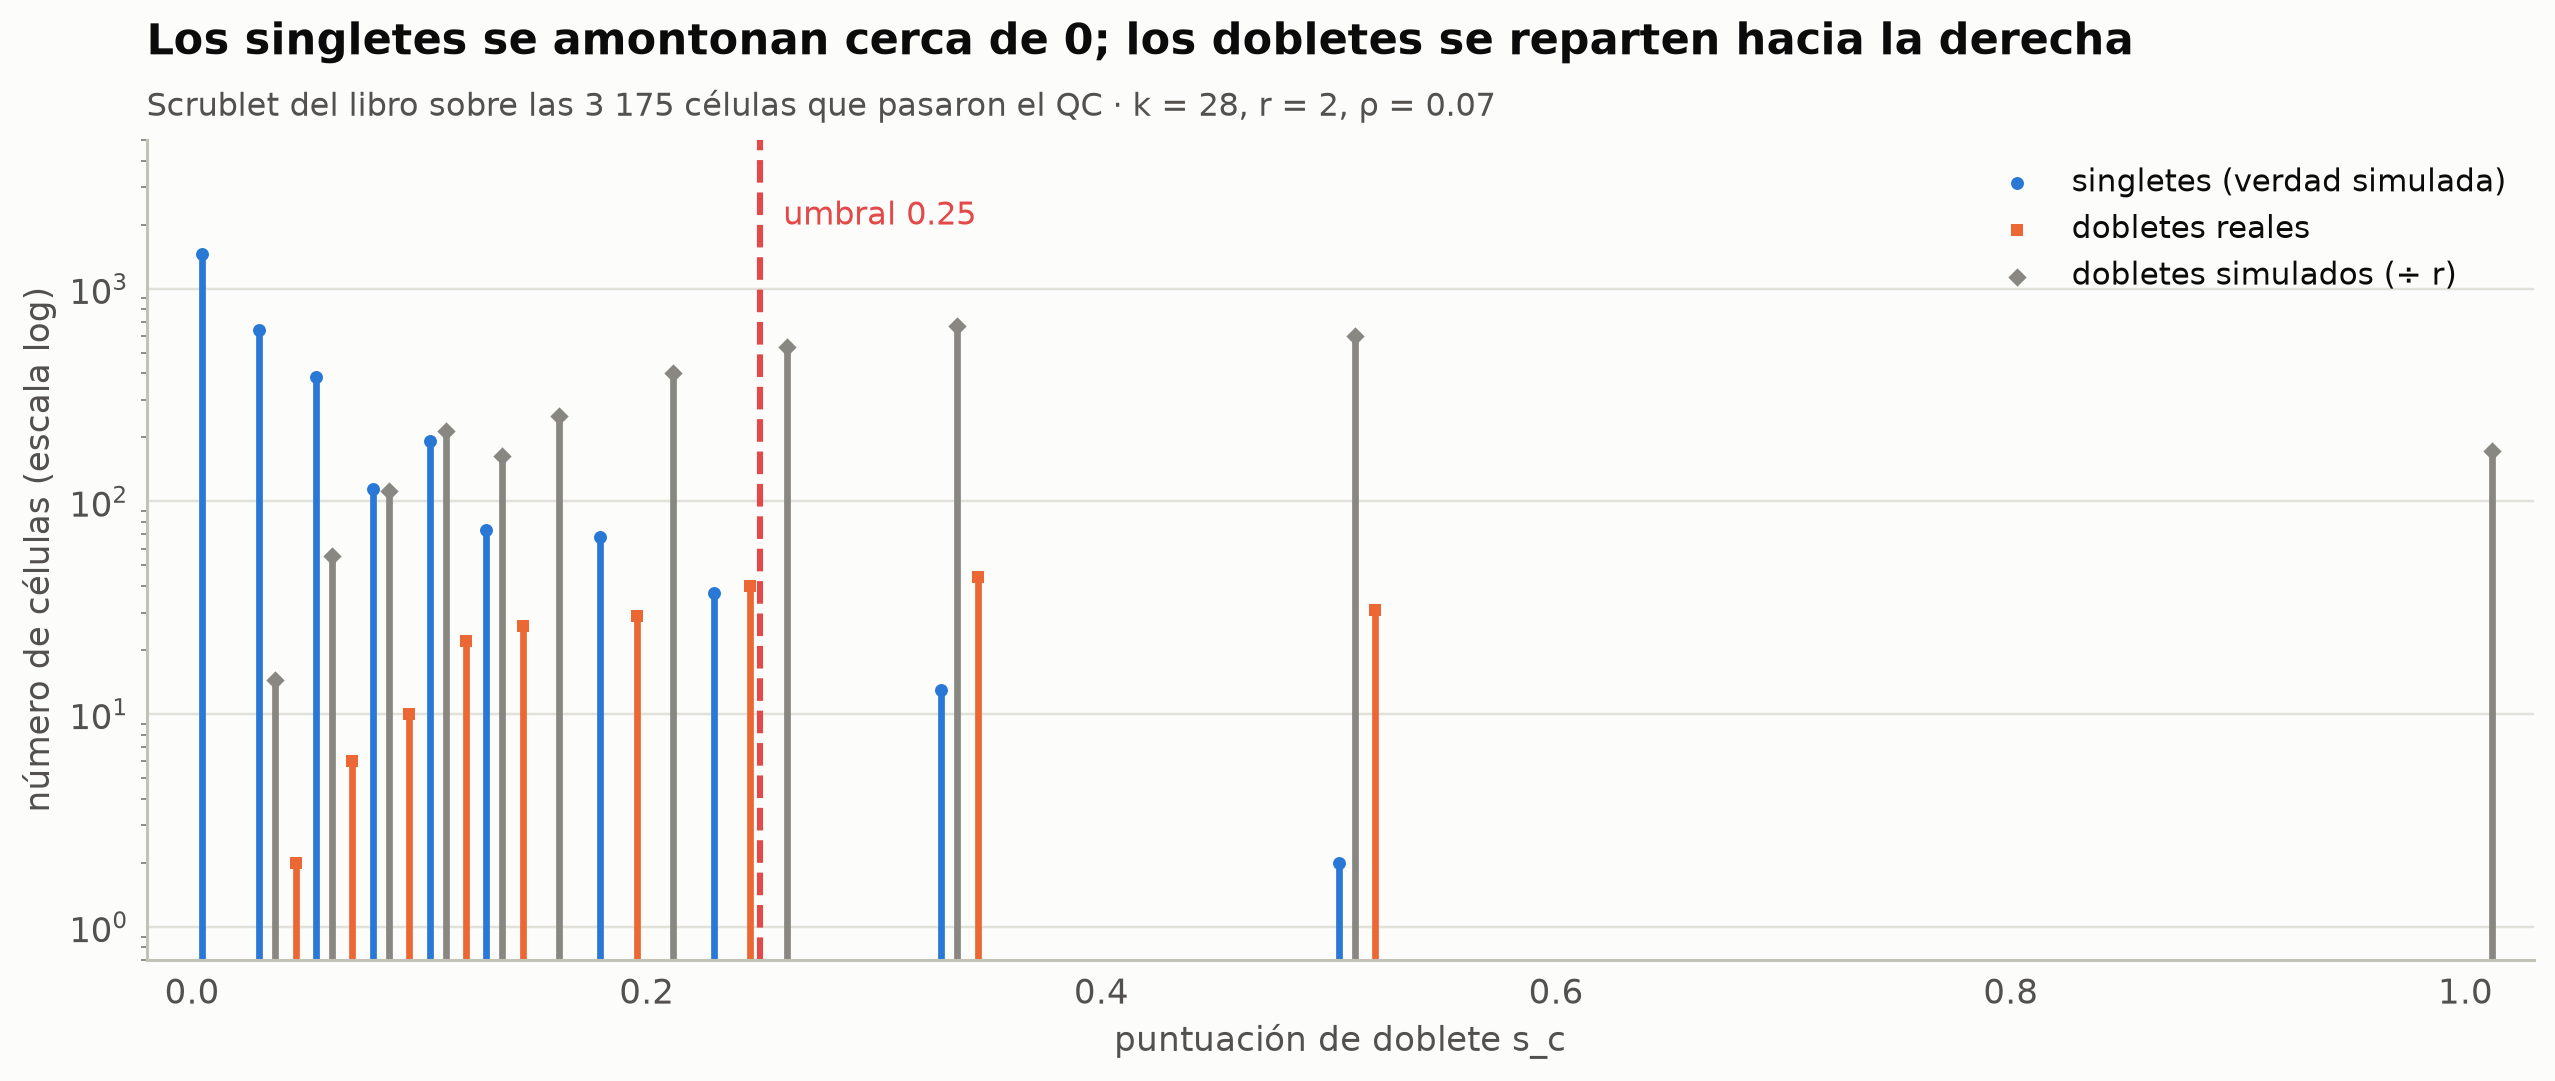

In [28]:
bins = np.linspace(0, 1, 41); ctr = (bins[1:] + bins[:-1]) / 2
is_dbl = np.isin(eq, ["dob_hetero", "dob_homo"])
h_ok = np.histogram(np.clip(score[~is_dbl], 0, 1), bins)[0]
h_db = np.histogram(np.clip(score[is_dbl], 0, 1), bins)[0]
h_sim = np.histogram(np.clip(score_sim, 0, 1), bins)[0] / r_ratio
fig, ax = plt.subplots(figsize=(11.5, 4.8))
for h, dx, col, lab, mk in [(h_ok, -0.008, ec.BLUE, "singletes (verdad simulada)", "o"),
                            (h_db, 0.008, ec.ORANGE, "dobletes reales", "s"),
                            (h_sim, 0.024, ec.MUTED, "dobletes simulados (÷ r)", "D")]:
    m_ = h > 0
    ax.vlines(ctr[m_] + dx, 0.7, h[m_], color=col, lw=2.2)
    ax.scatter(ctr[m_] + dx, h[m_], color=col, s=18, marker=mk, label=lab, zorder=3)
ax.axvline(thr_d, color=ec.RED, ls="--"); ax.text(thr_d + 0.01, 2000, "umbral 0.25", color=ec.RED, fontsize=10.5)
ax.set_yscale("log"); ax.set_ylim(0.7, 5000); ax.set_xlim(-0.02, 1.03)
ax.set_xlabel("puntuación de doblete s_c"); ax.set_ylabel("número de células (escala log)")
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Los singletes se amontonan cerca de 0; los dobletes se reparten hacia la derecha",
         "Scrublet del libro sobre las 3 175 células que pasaron el QC · k = 28, r = 2, ρ = 0.07")
plt.show()

> 🔎 **Qué observamos.** Los singletes tienen mediana $s=0.027$; los dobletes simulados (gris) se reparten por valores
> mucho más altos y marcan dónde deberían caer los reales. Como $q_c$ sólo puede valer $j/28$, la puntuación es
> **discreta**, y cada distribución aparece como barras aisladas. Con el umbral 0.25 se detecta el **40.9 %** de los
> dobletes heterotípicos y sólo el **12.8 %** de los homotípicos, a costa de marcar el **0.51 %** de los singletes (las
> cifras del libro). La detección es imperfecta, pero elimina justamente los dobletes que más engañan: los que unen tipos
> celulares distantes.

Tras QC y dobletes quedan las células «limpias». Con ellas volvemos al ARN ambiental de la sección 4: ¿cuántas células B
muestran *LYZ*, el gen de monocitos?

In [29]:
keep2 = score <= thr_d
X, T, E = Xq[keep2], tq[keep2], eq[keep2]
print(f"Tras QC + dobletes: {len(X)} células; quedan {int(np.sum(E != 'ok'))} dobletes reales sin detectar")
iB, iM = T == 3, T == 4
lyz = X[:, IM["LYZ"]]
print(f"Células B con al menos una UMI de LYZ: {100*np.mean(lyz[iB] > 0):.1f} %  ·  UMI medias de LYZ: "
      f"B = {lyz[iB].mean():.2f} frente a monocitos CD14 = {lyz[iM].mean():.1f}")
# ¿De dónde vienen? Descomposición esperada según la ecuación 12.4 (N_c medio de las células B)
NcB = X[iB].sum(1).mean()
print(f"Esperado en una célula B media (N ≈ {NcB:.0f}): ambiente ρ·N·a = {0.02*NcB*AMB[IM['LYZ']]:.3f} UMI; "
      f"nivel basal del simulador (1−ρ)·N·p = {0.98*NcB*PERF[3, IM['LYZ']]:.3f} UMI")

Tras QC + dobletes: 3085 células; quedan 135 dobletes reales sin detectar
Células B con al menos una UMI de LYZ: 15.2 %  ·  UMI medias de LYZ: B = 0.23 frente a monocitos CD14 = 5.7
Esperado en una célula B media (N ≈ 2772): ambiente ρ·N·a = 0.026 UMI; nivel basal del simulador (1−ρ)·N·p = 0.160 UMI


> 🔎 **Qué observamos.** Con un $\rho=2\,\%$, el **15.2 %** de las células B muestra al menos una UMI de *LYZ*, con 0.23
> UMI de media frente a 5.7 en los monocitos CD14 (las cifras del libro). La última línea hace la cuenta con la ecuación
> 12.4: en este simulador, a esa señal espuria contribuyen tanto la sopa como un nivel basal mínimo que el simulador asigna
> a todos los genes en todos los tipos. En los datos reales ambos efectos también se mezclan, y por eso SoupX necesita genes
> de los que se sepa con seguridad que **no** se expresan en un tipo celular. Un análisis ingenuo diría que «algunas
> células B expresan *LYZ*».

### 🧪 Dobletes en PBMC 3k: nuestro Scrublet y el de Scanpy

En datos reales no conocemos la verdad, pero sí podemos comparar nuestra implementación con `sc.pp.scrublet` (Scanpy ≥ 1.10),
que sigue el algoritmo original: simula dobletes, reduce con PCA, busca vecinos y fija un umbral automático en el valle de la
distribución bimodal de las puntuaciones simuladas. Primero aplicamos el QC y quitamos los genes detectados en menos de 3
células. Con 2 700 células cargadas, la ecuación 12.2 y la regla de 10x (≈ 0.8 % de dobletes por cada 1 000 células
recuperadas) sugieren $\rho\approx0.02$–$0.03$; usamos $\rho=0.06$, el valor del tutorial original de Scrublet, que es
conservador. Ojo: no es el valor por defecto de ninguna de las dos herramientas (Scrublet usa $0.1$ y `sc.pp.scrublet`,
$0.05$), así que nuestra puntuación y la de Scanpy parten de probabilidades previas algo distintas.

In [30]:
ad = adata[keep_r].copy()
sc.pp.filter_genes(ad, min_cells=3)
print(f"Tras el QC: {ad.n_obs} células × {ad.n_vars} genes")

def scrublet_sparse(Xc, is_mt, rho=0.06, r=2.0, n_hvg=2000, min_mean=0.5, n_pc=30, seed=0):
    """Nuestro Scrublet para una matriz CSR de cuentas: sólo densificamos los genes altamente variables."""
    rng = np.random.default_rng(seed)
    n = Xc.shape[0]
    def lognorm_sparse(M):
        tot = np.asarray(M.sum(1)).ravel()
        return sparse.diags(1e4 / tot) @ M                  # CP10k (aún sin logaritmo)
    E = lognorm_sparse(Xc)
    mu = np.asarray(E.mean(0)).ravel()
    var = (np.asarray(E.multiply(E).sum(0)).ravel() - n * mu**2) / (n - 1)
    genes, _, _ = hvg_from_moments(mu, var, n_hvg, exclude=np.where(is_mt)[0], min_mean=min_mean)
    Zo = np.log1p(E[:, genes].toarray())
    mu_, sd_ = Zo.mean(0), Zo.std(0) + 1e-9
    Zs = (Zo - mu_) / sd_
    _, _, Vt = np.linalg.svd(Zs, full_matrices=False)
    Po = Zs @ Vt[:n_pc].T
    n_sim = int(r * n)
    i1, i2 = rng.integers(0, n, n_sim), rng.integers(0, n, n_sim)
    Xs = Xc[i1] + Xc[i2]
    Ps = ((np.log1p(lognorm_sparse(Xs)[:, genes].toarray()) - mu_) / sd_) @ Vt[:n_pc].T
    k = int(round(0.5 * math.sqrt(n)))
    _, idx = NearestNeighbors(n_neighbors=k).fit(np.vstack([Po, Ps])).kneighbors(Po)
    return scrublet_score((idx >= n).mean(1), n_sim / n, rho)

t0 = time.time()
ad.obs["our_score"] = scrublet_sparse(sparse.csr_matrix(ad.X), ad.var["mt"].values)
t1 = time.time()
sc.pp.scrublet(ad, random_state=0)
t2 = time.time()
thr_sc = ad.uns["scrublet"]["threshold"]
rho_s = stats.spearmanr(ad.obs.our_score, ad.obs.doublet_score).statistic
print(f"Nuestro Scrublet: {t1-t0:.1f} s · Scanpy: {t2-t1:.1f} s")
print(f"Scanpy: umbral automático = {thr_sc:.3f} → {int(ad.obs.predicted_doublet.sum())} dobletes predichos "
      f"({ad.obs.predicted_doublet.mean():.1%})")
print(f"Correlación de Spearman entre ambas puntuaciones: {rho_s:.2f}")
top_ours = set(ad.obs.our_score.nlargest(int(ad.obs.predicted_doublet.sum())).index)
print(f"De los {int(ad.obs.predicted_doublet.sum())} dobletes de Scanpy, {len(top_ours & set(ad.obs_names[ad.obs.predicted_doublet]))} "
      "están también entre nuestras células de mayor puntuación.")

Tras el QC: 2683 células × 13668 genes


Nuestro Scrublet: 1.7 s · Scanpy: 3.0 s
Scanpy: umbral automático = 0.247 → 33 dobletes predichos (1.2%)
Correlación de Spearman entre ambas puntuaciones: 0.34
De los 33 dobletes de Scanpy, 15 están también entre nuestras células de mayor puntuación.


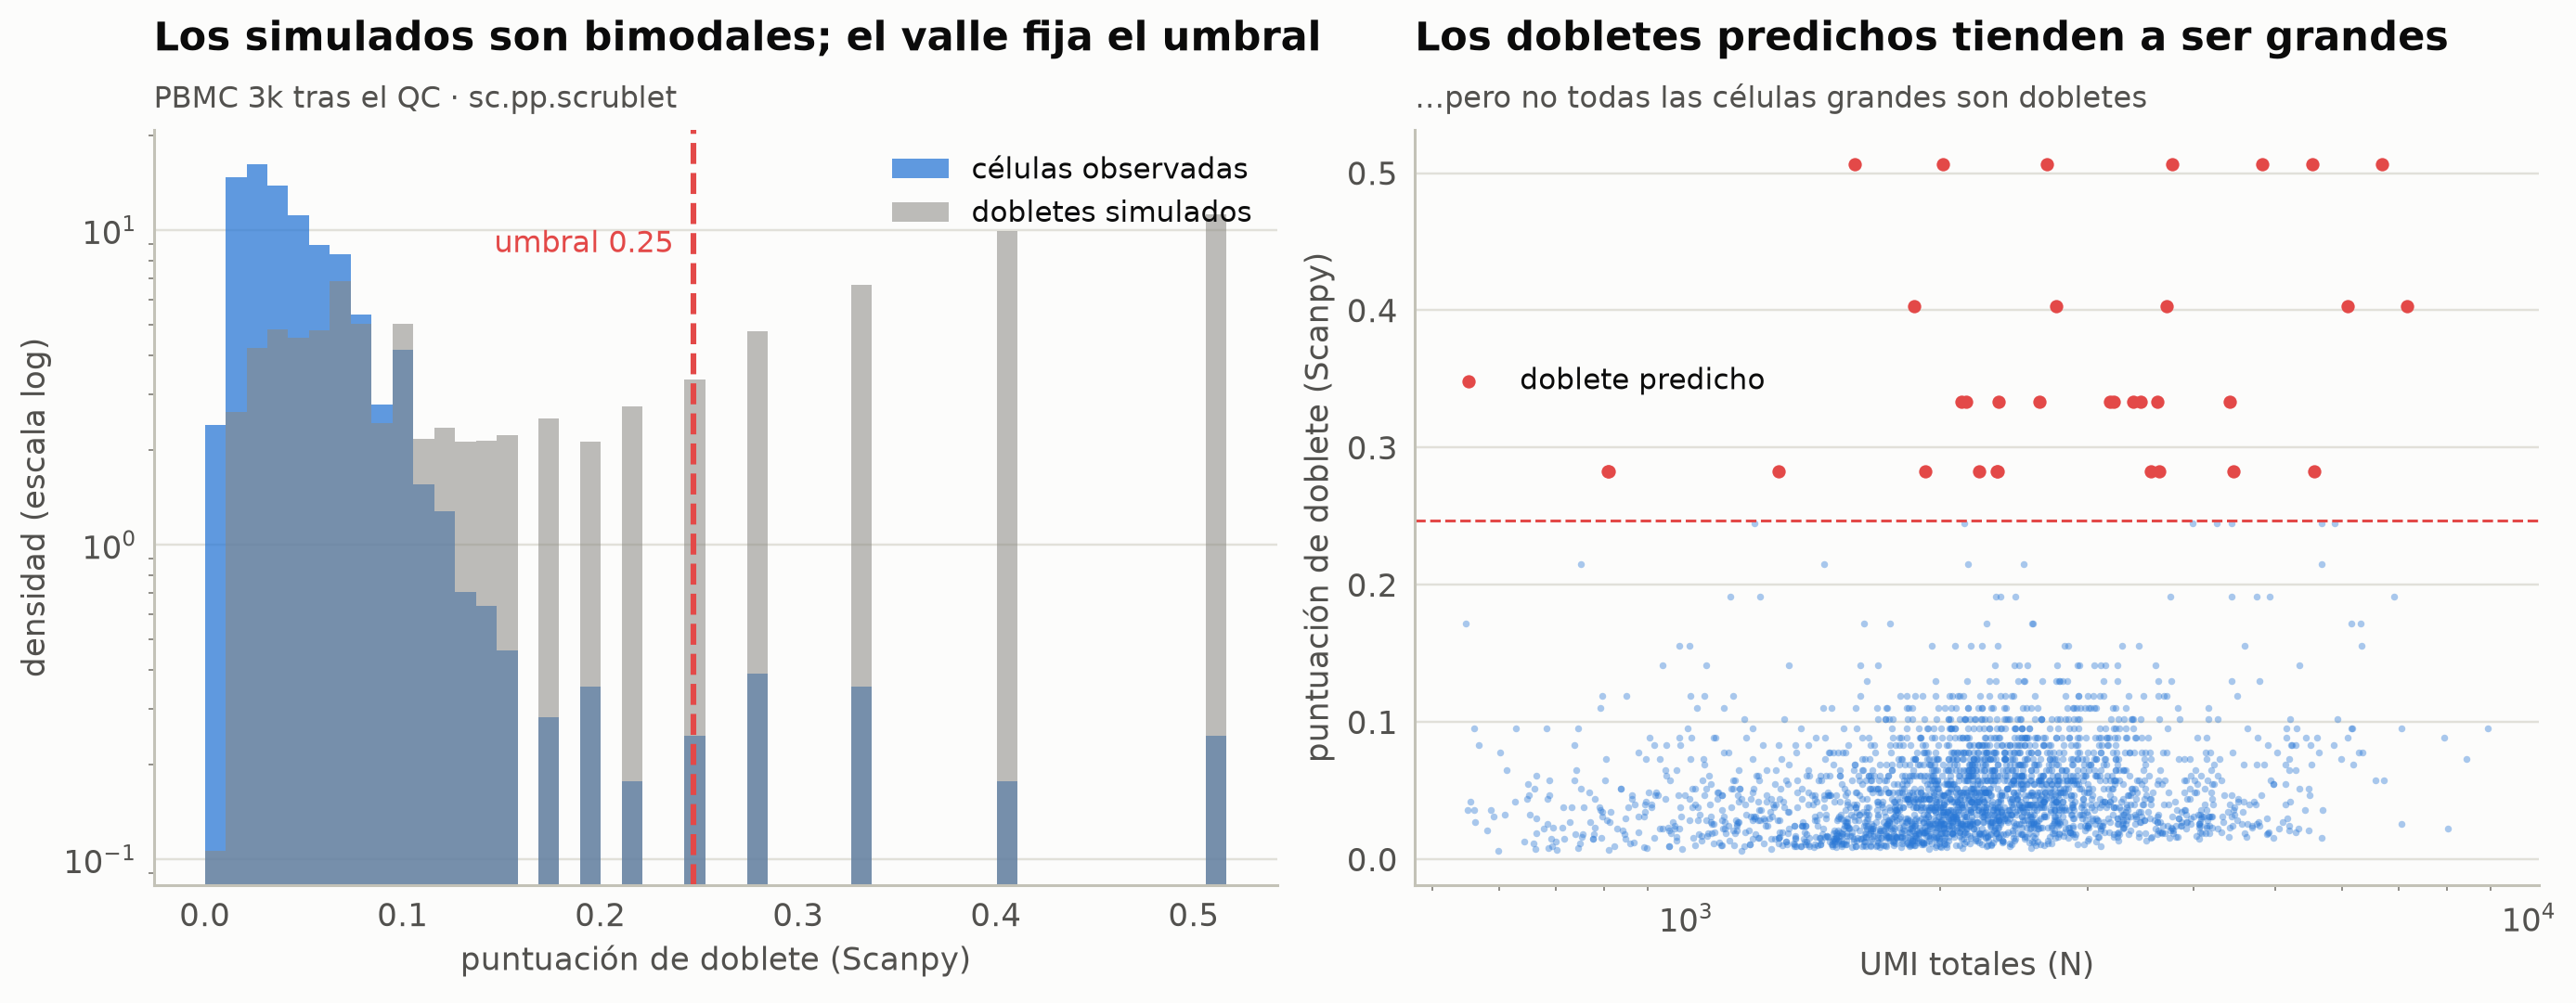

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axs[0]
sim_sc = ad.uns["scrublet"]["doublet_scores_sim"]
b_ = np.linspace(0, max(sim_sc.max(), ad.obs.doublet_score.max()) + 0.01, 50)
ax.hist(ad.obs.doublet_score, bins=b_, color=ec.BLUE, alpha=0.75, density=True, label="células observadas")
ax.hist(sim_sc, bins=b_, color=ec.MUTED, alpha=0.55, density=True, label="dobletes simulados")
ax.axvline(thr_sc, color=ec.RED, ls="--"); ax.text(thr_sc - 0.01, ax.get_ylim()[1] * 0.5, f"umbral {thr_sc:.2f}",
                                                  color=ec.RED, fontsize=10.5, ha="right")
ax.set_yscale("log"); ax.set_xlabel("puntuación de doblete (Scanpy)"); ax.set_ylabel("densidad (escala log)")
ax.legend(frameon=False, loc="upper right")
ec.title(ax, "Los simulados son bimodales; el valle fija el umbral", "PBMC 3k tras el QC · sc.pp.scrublet")
ax = axs[1]
pdbl = ad.obs.predicted_doublet.values
ax.scatter(ad.obs.total_counts[~pdbl], ad.obs.doublet_score[~pdbl], s=6, color=ec.BLUE, alpha=0.4, lw=0)
ax.scatter(ad.obs.total_counts[pdbl], ad.obs.doublet_score[pdbl], s=22, color=ec.RED, lw=0, label="doblete predicho")
ax.set_xscale("log"); ax.set_xlabel("UMI totales (N)"); ax.set_ylabel("puntuación de doblete (Scanpy)")
ax.axhline(thr_sc, color=ec.RED, ls="--", lw=1)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 0.72))
ec.title(ax, "Los dobletes predichos tienden a ser grandes", "…pero no todas las células grandes son dobletes")
plt.show()

> 🔎 **Qué observamos.** Scanpy marca 33 células (~1.2 %, cifra razonable para ~2 700 células) con un umbral automático
> en el valle de la distribución simulada. Nuestro Scrublet coincide sólo **en parte**: comparte con Scanpy cerca de la
> mitad de sus 33 células de mayor puntuación, y la correlación global es moderada. No es un error, es una lección: la
> puntuación depende de decisiones aparentemente menores. Scanpy elige los genes por su variabilidad con otro criterio,
> no aplica logaritmo antes de la PCA y usa $\rho=0.05$. En nuestra primera versión, además, los 500 genes «más variables»
> eran genes casi nunca detectados, puro ruido de muestreo (lo veremos en la sección 8), y la puntuación no se parecía en
> nada a la de Scanpy; por eso la función exige una media mínima de 0.5 CP10k (`min_mean`). Entre los singletes la
> puntuación es casi puro ruido cerca de cero, así que lo que conviene comparar es la cola alta. En el panel derecho, los
> dobletes predichos tienen más UMI que la mayoría, pero muchas células grandes tienen puntuación baja: son monocitos,
> simplemente grandes. Scrublet mira el **perfil**, no el tamaño.

> ⚠️ **El orden importa.** Scrublet debe ejecutarse sobre **cuentas crudas** y, si hay varias muestras, **por separado en
> cada una**, porque los dobletes sólo pueden formarse dentro de un mismo canal del chip: sumar una célula de la muestra A
> con una de la B fabrica dobletes imposibles.

## 7. Normalización

Dos células idénticas pueden producir librerías de tamaño muy distinto: la eficiencia de captura y de transcripción inversa
varía de una gota a otra. Es como comparar dos encuestas en las que una entrevistó a 500 personas y otra a 2 000: hay que
comparar **porcentajes**, no conteos. Antes de comparar células hay que eliminar esa variación técnica sin borrar la
biológica.

### El modelo: binomial negativa, sin ceros «extra»

El modelo de partida para las cuentas de UMI es la **binomial negativa** (BN), el mismo modelo gamma-Poisson de la
Lección 11.2:

$$
x_{cg}\sim\mathrm{BN}(\mu_{cg},\theta_g),\quad \mu_{cg}=s_c\,q_{g,t(c)},\quad
\mathrm{Var}[x_{cg}]=\mu_{cg}+\frac{\mu_{cg}^2}{\theta_g},\quad \Pr(x_{cg}=0)=\left(\frac{\theta_g}{\theta_g+\mu_{cg}}\right)^{\theta_g}. \qquad (12.8)
$$

| Símbolo | Significado |
|---|---|
| $s_c$ | Factor de tamaño de la célula $c$: eficiencia técnica global de su librería |
| $q_{g,t(c)}$ | Expresión del gen $g$ en el estado biológico $t(c)$ de la célula |
| $\theta_g$ | Parámetro de dispersión inversa; $\theta\to\infty$ recupera la Poisson |

Un punto que costó años aclarar: los muchos ceros de los datos de gotas **no** requieren un modelo con inflación de ceros.
Svensson (2020) comprobó, con ARN sintético sin variación biológica, que la fracción de ceros observada es la que predice la
BN con la media observada. Comprobémoslo en PBMC 3k: para cada gen comparamos la fracción de células con cero UMI con la
que predicen la Poisson y la BN, teniendo en cuenta el tamaño de cada célula ($\mu_{cg}=N_c\,\hat p_g$).

θ común que mejor predice los ceros: 1.55
Error cuadrático medio en la fracción de ceros: Poisson 0.00086 · BN 0.00049


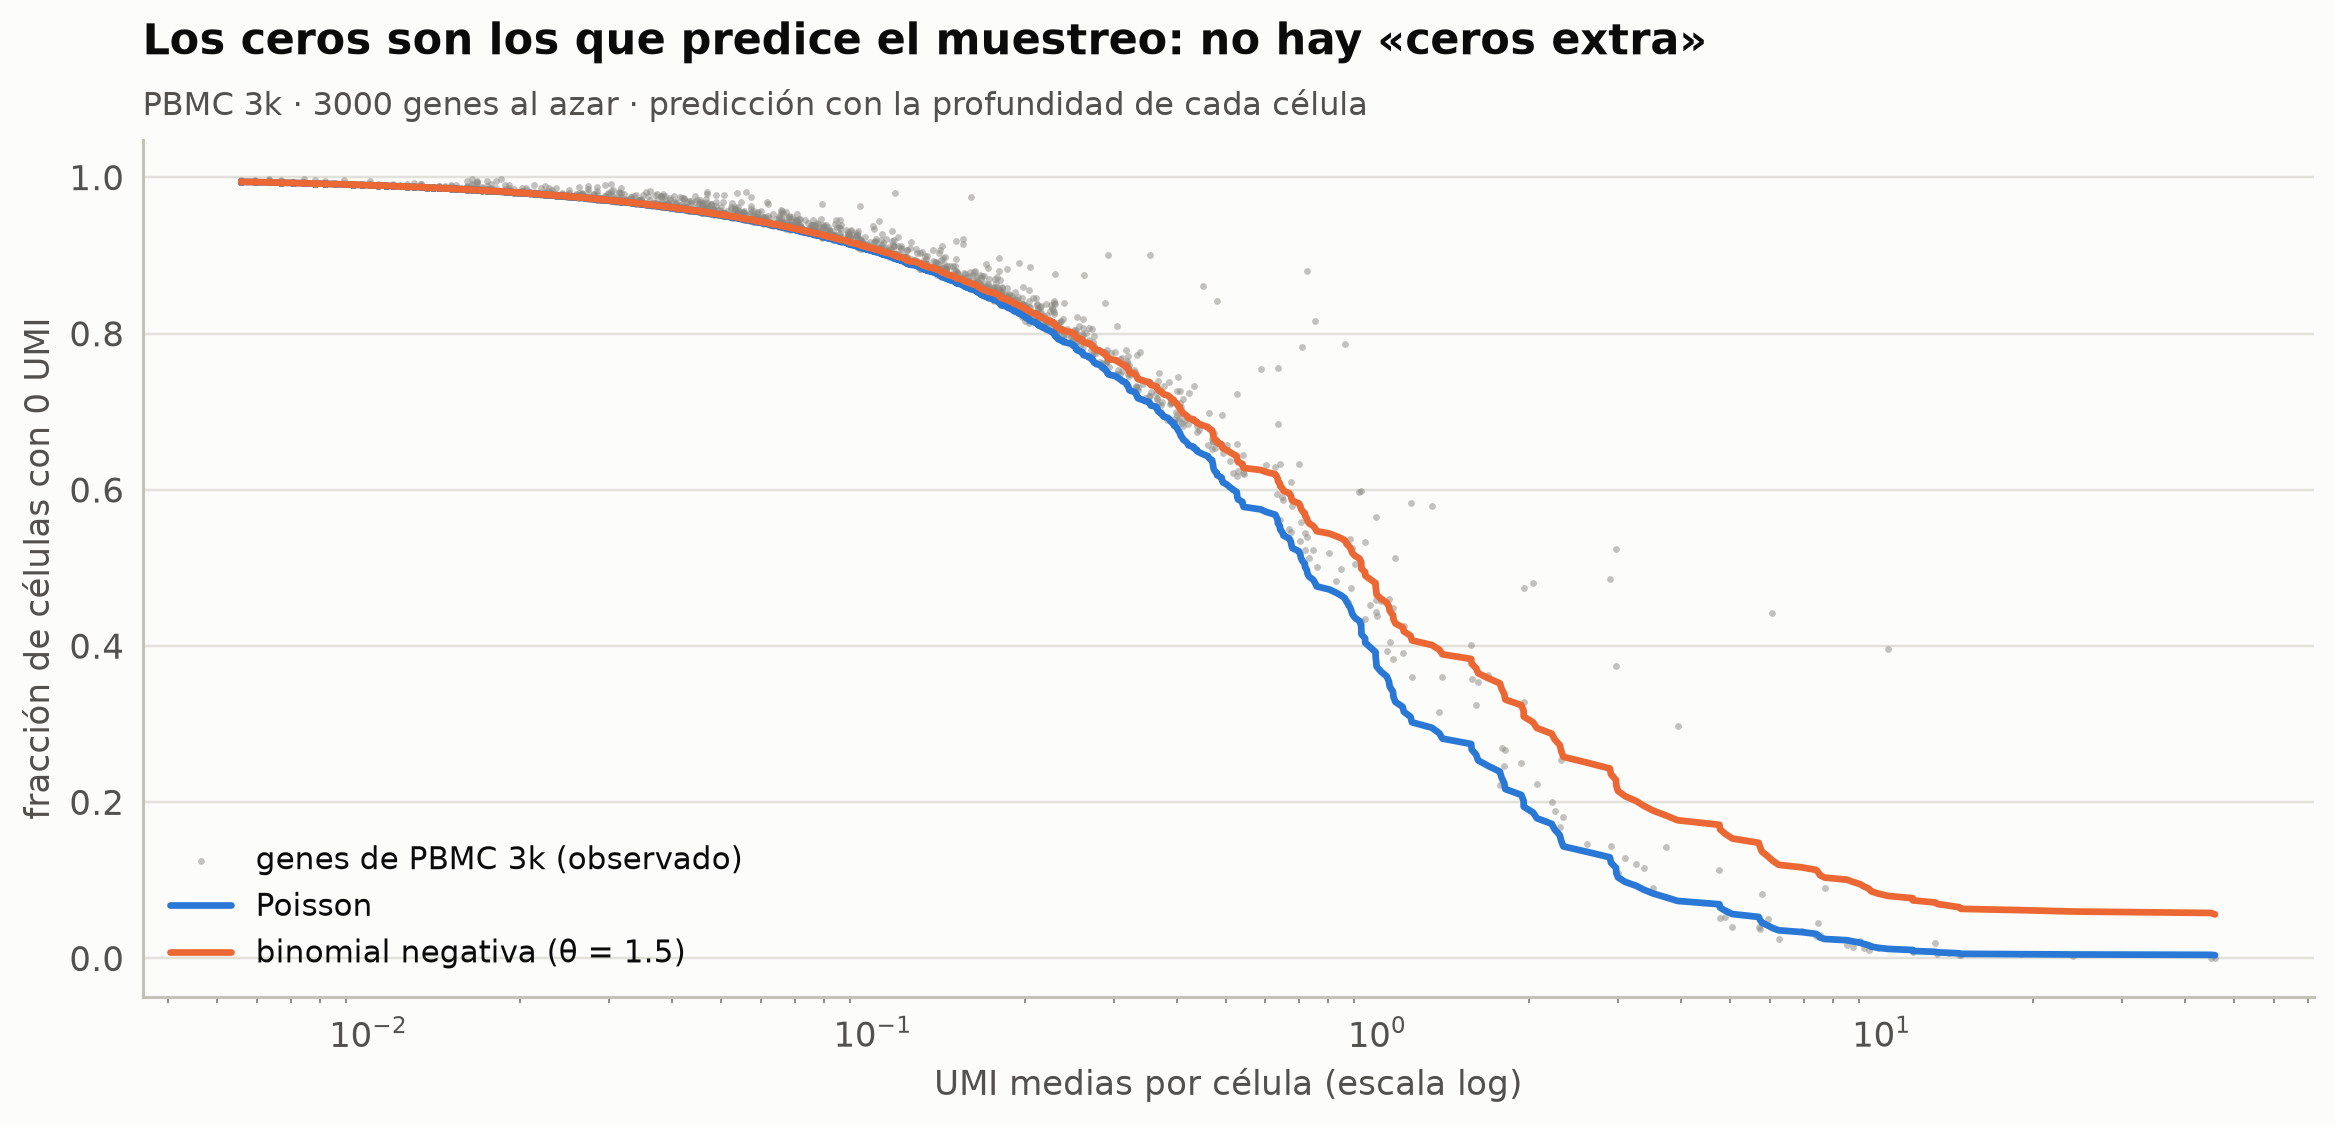

In [32]:
Xq_r = sparse.csr_matrix(ad.X)                           # PBMC tras el QC (2 683 células)
Nc = np.asarray(Xq_r.sum(1)).ravel()
p_g = np.asarray(Xq_r.sum(0)).ravel() / Nc.sum()
obs_zero = 1 - np.diff(sparse.csc_matrix(Xq_r).indptr) / Xq_r.shape[0]
sel_g = np.where(p_g * np.median(Nc) > 0.005)[0]            # genes con media ≥ 0.005 UMI por célula
rng_g = np.random.default_rng(0)
sel_g = np.sort(rng_g.choice(sel_g, min(3000, len(sel_g)), replace=False))
MU = np.outer(Nc, p_g[sel_g])                            # μ_cg = N_c p_g  (células × genes elegidos)
pois_zero = np.exp(-MU).mean(0)
def nb_zero(theta):
    return ((theta / (theta + MU)) ** theta).mean(0)
thetas = np.logspace(-0.5, 2, 30)
err = [np.mean((nb_zero(t) - obs_zero[sel_g]) ** 2) for t in thetas]
theta_best = thetas[int(np.argmin(err))]
print(f"θ común que mejor predice los ceros: {theta_best:.2f}")
print(f"Error cuadrático medio en la fracción de ceros: Poisson {np.mean((pois_zero-obs_zero[sel_g])**2):.5f} · "
      f"BN {min(err):.5f}")

mean_g = MU.mean(0)
fig, ax = plt.subplots(figsize=(10.5, 5))
ax.scatter(mean_g, obs_zero[sel_g], s=5, color=ec.MUTED, alpha=0.5, lw=0, label="genes de PBMC 3k (observado)")
o = np.argsort(mean_g)
ax.plot(mean_g[o], pd.Series(pois_zero[o]).rolling(50, center=True, min_periods=1).mean(), color=ec.BLUE, lw=2.2,
        label="Poisson")
ax.plot(mean_g[o], pd.Series(nb_zero(theta_best)[o]).rolling(50, center=True, min_periods=1).mean(), color=ec.ORANGE,
        lw=2.2, label=f"binomial negativa (θ = {theta_best:.1f})")
ax.set_xscale("log"); ax.set_xlabel("UMI medias por célula (escala log)"); ax.set_ylabel("fracción de células con 0 UMI")
ax.legend(frameon=False, loc="lower left")
ec.title(ax, "Los ceros son los que predice el muestreo: no hay «ceros extra»",
         f"PBMC 3k · {len(sel_g)} genes al azar · predicción con la profundidad de cada célula")
plt.show()

> 🔎 **Qué observamos.** Los genes poco expresados tienen casi todas las células en cero, y eso es exactamente lo que
> esperamos por puro muestreo: si un gen aporta 0.05 moléculas por célula en promedio, la mayoría de las células no
> capturará ninguna. Para la inmensa mayoría de los genes, incluso la **Poisson**, que no tiene ninguna dispersión extra, ya
> predice los ceros observados. Los genes que se apartan hacia arriba (más ceros de lo esperado) son los que cambian entre
> tipos celulares: un marcador de monocitos es cero en todos los linfocitos por razones **biológicas**. La BN con un único
> $\theta$ para todos los genes ajusta mejor la zona intermedia pero sobreestima los ceros de los genes muy expresados: en
> realidad cada gen tiene su propio $\theta_g$. Lo importante es lo que **no** aparece: una masa de ceros inexplicable que
> exija un modelo con inflación de ceros.

### Normalización por tamaño de librería y logaritmo

El procedimiento por defecto en Scanpy estima $s_c\propto N_c$, escala cada célula a un total común de $10^4$ («cuentas
por diez mil», CP10k) y aplica un logaritmo desplazado:

$$
y_{cg} = \log\!\left(1 + \frac{x_{cg}}{N_c}\cdot 10^4\right). \qquad (12.9)
$$

| Símbolo | Significado |
|---|---|
| $x_{cg}/N_c$ | Fracción de las UMI de la célula que corresponde al gen $g$ |
| $10^4$ | Total común al que se escala cada célula (CP10k) |
| $y_{cg}$ | Expresión log-normalizada (logaritmo natural) |

### 📝 Ejemplo resuelto del libro: normalizar una célula

Un monocito CD14 de la simulación tiene $N_c=6\,359$ UMI, 5 de ellas de *LYZ*. Su valor normalizado es
$5/6\,359\times10^4=7.9$ CP10k y, tras la ecuación 12.9, $y=\ln(1+7.9)=2.182$. Un linfocito con la mitad de UMI y la misma
proporción de *LYZ* tendría **exactamente** el mismo $y$: la normalización compara proporciones, no cuentas.

In [33]:
c0 = int(np.argmax(T == 4))                                   # primer monocito CD14 de las células limpias
Nc0, x0 = X[c0].sum(), X[c0, IM["LYZ"]]
print(f"Monocito CD14: N_c = {Nc0}, LYZ = {x0} → CP10k = {x0/Nc0*1e4:.1f} → y = ln(1 + {x0/Nc0*1e4:.2f}) = "
      f"{np.log1p(x0/Nc0*1e4):.3f}")
print(f"Linfocito hipotético con N = {Nc0/2:.1f} y LYZ = {x0/2}: y = {np.log1p((x0/2)/(Nc0/2)*1e4):.3f}")

# Desde cero sobre la matriz CSR real, sin densificar: sólo se tocan los valores no nulos
def lognorm_csr(Xc, target=1e4):
    Xc = sparse.csr_matrix(Xc, dtype=np.float64, copy=True)
    tot = np.asarray(Xc.sum(1)).ravel()
    Xc.data = np.log1p(Xc.data / np.repeat(tot, np.diff(Xc.indptr)) * target)
    return Xc

Y_ours = lognorm_csr(ad.X)
ad.layers["counts"] = ad.X.copy()
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
print(f"Diferencia máxima con sc.pp.normalize_total + sc.pp.log1p: {abs(Y_ours - ad.X).max():.2e}")
print("Los ceros siguen siendo ceros (log(1+0) = 0): la matriz sigue siendo dispersa,",
      f"densidad {Y_ours.nnz/np.prod(Y_ours.shape):.2%}")

Monocito CD14: N_c = 6359, LYZ = 5 → CP10k = 7.9 → y = ln(1 + 7.86) = 2.182
Linfocito hipotético con N = 3179.5 y LYZ = 2.5: y = 2.182


Diferencia máxima con sc.pp.normalize_total + sc.pp.log1p: 3.40e-07
Los ceros siguen siendo ceros (log(1+0) = 0): la matriz sigue siendo dispersa, densidad 6.17%


### ¿Por qué el logaritmo? El método delta

La varianza de las cuentas crece con la media, y los métodos posteriores (PCA, distancias euclídeas) dan más peso a los
genes de mayor varianza: sin transformar, unos pocos genes muy expresados dominarían todo. Por el método delta, si $X$ tiene
media $\mu$ y varianza $\sigma^2$,

$$
\mathrm{Var}[\log(1+X)] \approx \frac{\sigma^2}{(1+\mu)^2} = \frac{\mu+\mu^2/\theta}{(1+\mu)^2}\;\xrightarrow{\;\mu\to\infty\;}\;\frac{1}{\theta}. \qquad (12.10)
$$

Para genes muy expresados el logaritmo **estabiliza** la varianza en $1/\theta$, independiente de la media. Para genes poco
expresados ($\mu\ll1$) la varianza queda $\approx\mu$: la transformación no los estabiliza del todo, y el pseudoconteo 1
(arbitrario) influye en el resultado.

**A mano, con $\theta=6$:** para $\mu=0.1$, $(0.1+0.1^2/6)/1.1^2 = 0.1017/1.21=0.084$; para $\mu=100$,
$(100+1667)/10\,201=0.173$, ya cerca de $1/6=0.167$. Comprobémoslo con simulaciones de la BN.

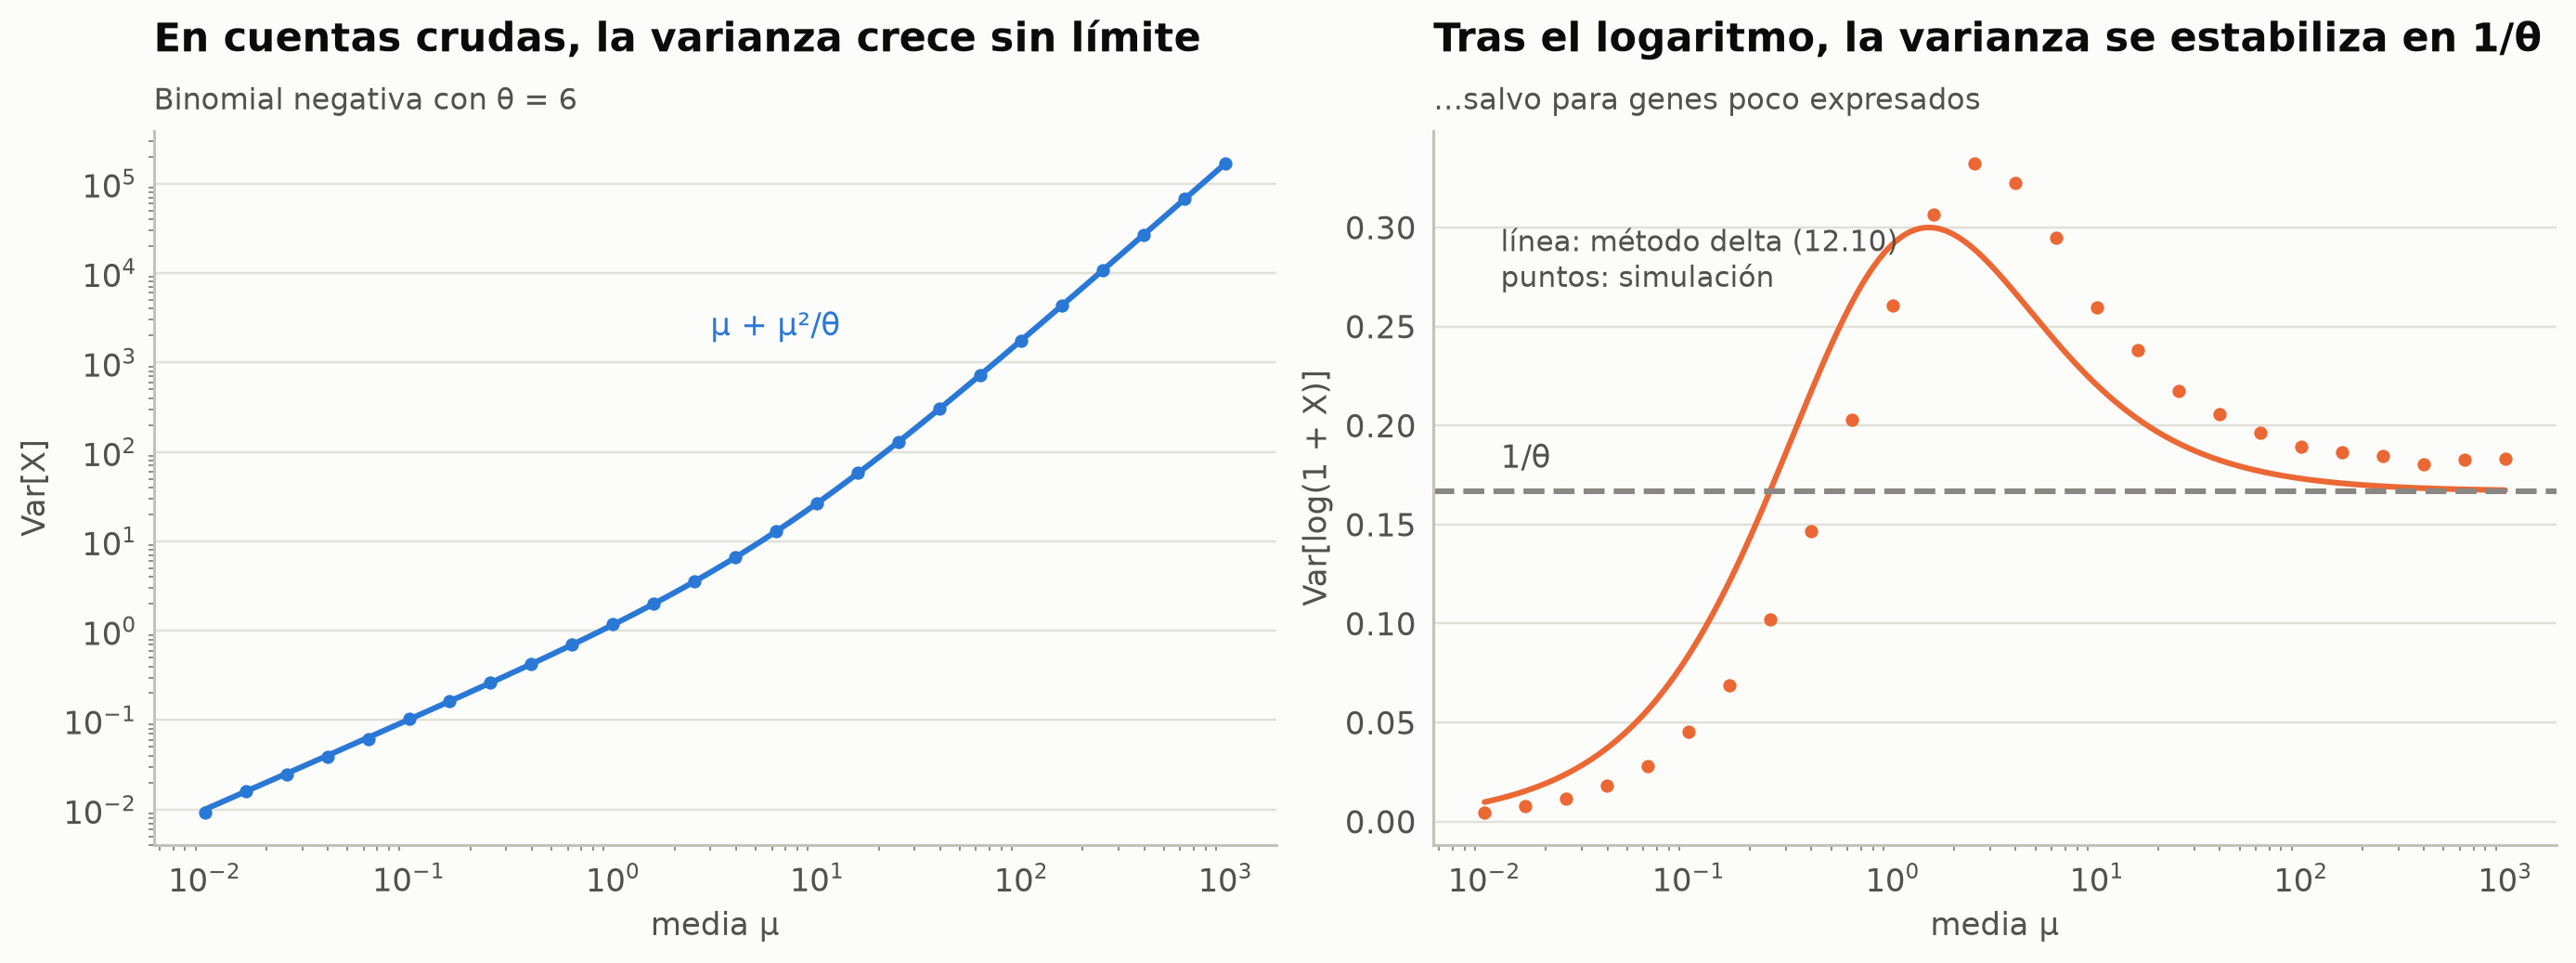

In [34]:
rng_dm = np.random.default_rng(12)
theta_dm = 6.0
mus = np.logspace(-2, 3, 26)
var_raw, var_log = [], []
for mu in mus:
    xs = rng_dm.poisson(rng_dm.gamma(theta_dm, mu / theta_dm, 40000))
    var_raw.append(xs.var()); var_log.append(np.log1p(xs).var())
mm = np.logspace(-2, 3, 200)
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axs[0]
ax.plot(mm, mm + mm**2 / theta_dm, color=ec.BLUE, lw=2); ax.scatter(mus, var_raw, color=ec.BLUE, s=22, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("media μ"); ax.set_ylabel("Var[X]")
ax.text(3, 2e3, "μ + μ²/θ", color=ec.BLUE, fontsize=11)
ec.title(ax, "En cuentas crudas, la varianza crece sin límite", f"Binomial negativa con θ = {theta_dm:g}")
ax = axs[1]
ax.plot(mm, (mm + mm**2 / theta_dm) / (1 + mm)**2, color=ec.ORANGE, lw=2)
ax.scatter(mus, var_log, color=ec.ORANGE, s=22, zorder=3)
ax.axhline(1 / theta_dm, color=ec.MUTED, ls="--"); ax.text(0.012, 1 / theta_dm + 0.012, "1/θ", color=ec.INK_2, fontsize=11)
ax.set_xscale("log"); ax.set_xlabel("media μ"); ax.set_ylabel("Var[log(1 + X)]")
ax.text(0.012, 0.27, "línea: método delta (12.10)\npuntos: simulación", color=ec.INK_2, fontsize=10)
ec.title(ax, "Tras el logaritmo, la varianza se estabiliza en 1/θ", "…salvo para genes poco expresados")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la varianza cruda recorre seis órdenes de magnitud. A la derecha, tras el
> logaritmo, queda acotada: se acerca a $1/\theta$ para medias grandes. La aproximación falla un poco en la zona intermedia
> ($\mu\approx1$–10), donde la distribución es muy asimétrica y el método delta, que linealiza, no es exacto; y la
> varianza es menor que $1/\theta$ para $\mu$ pequeñas, donde casi todo es cero. Ese es el sesgo del pseudoconteo.

### Dos alternativas: factores por agrupamiento y residuos de Pearson

**Factores de tamaño por agrupamiento (scran).** Suponer $s_c\propto N_c$ equivale a suponer que todas las células tienen el
mismo contenido total de ARN, lo cual es falso entre tipos celulares, y la estimación es muy ruidosa con pocas cuentas.
Lun, Bach y Marioni (2016) suman las cuentas de grupos (*pools*) de células parecidas, donde hay pocos ceros y los cocientes
de medianas son estables, y recuperan los factores individuales resolviendo un sistema lineal por mínimos cuadrados:

$$
\hat{S}_P = \operatorname*{med}_g \frac{\sum_{c\in P} x_{cg}}{\bar{x}_g}\;\approx\;\sum_{c\in P} s_c\qquad\text{para muchos grupos }P, \qquad (12.11)
$$

con $\bar{x}_g$ la media del gen en una pseudocélula de referencia.

**Residuos de Pearson (sctransform).** Hafemeister y Satija (2019) propusieron modelar la profundidad en lugar de dividir
por ella. Para cada gen se ajusta una regresión BN con $\log N_c$ como covariable y se usan los residuos de Pearson:

$$
\log\mu_{cg} = \beta_{0g} + \beta_{1g}\log N_c,\qquad
r_{cg} = \frac{x_{cg}-\hat\mu_{cg}}{\sqrt{\hat\mu_{cg}+\hat\mu_{cg}^2/\hat\theta_g}}. \qquad (12.12)
$$

| Símbolo | Significado |
|---|---|
| $\beta_{0g},\beta_{1g}$ | Intercepto y pendiente de la regresión del gen $g$ sobre la profundidad |
| $\hat\mu_{cg}$ | Cuenta esperada si la célula sólo difiriera de las demás en profundidad |
| $r_{cg}$ | Residuo de Pearson: desviación en unidades de desviación estándar del modelo |

Si el gen sólo varía por razones técnicas, $r_{cg}$ tiene media 0 y varianza 1 en todas las células; la variación biológica
aparece como **exceso de varianza**. Lause, Berens y Kobak (2021) mostraron que basta fijar $\beta_{1g}=1$ y un $\theta$
común (100), con lo que $\hat\mu_{cg}=N_c\,\hat p_g$ tiene fórmula cerrada: son los residuos de Pearson **analíticos** de
Scanpy (`sc.experimental.pp.normalize_pearson_residuals`). Programémoslos y comparemos la varianza por gen de las dos
normalizaciones.

In [35]:
def pearson_residuals(Xc, theta=100.0):
    """Residuos de Pearson analíticos: μ = N_c p_g; recorte en ±√n (Lause et al., 2021)."""
    Xd = Xc.toarray().astype(np.float64)
    Nc = Xd.sum(1, keepdims=True); pg = Xd.sum(0, keepdims=True) / Xd.sum()
    mu = Nc * pg
    r = (Xd - mu) / np.sqrt(mu + mu**2 / theta)
    lim = np.sqrt(Xd.shape[0])
    return np.clip(r, -lim, lim)

genes_detected = np.asarray((ad.layers["counts"] > 0).sum(0)).ravel() >= 20      # genes en ≥ 20 células
Xc_sub = ad.layers["counts"][:, genes_detected]
R = pearson_residuals(Xc_sub)
ad_pr = sc.AnnData(Xc_sub.copy())
sc.experimental.pp.normalize_pearson_residuals(ad_pr, theta=100)
print(f"Genes comparados: {Xc_sub.shape[1]} · diferencia máxima con Scanpy: {np.abs(R - ad_pr.X).max():.2e}")
var_pr = R.var(0)
Ylog = ad.X[:, genes_detected]
mean_counts = np.asarray(Xc_sub.mean(0)).ravel()
var_log_g = np.asarray(Ylog.multiply(Ylog).mean(0)).ravel() - np.asarray(Ylog.mean(0)).ravel()**2
names_sub = ad.var_names[genes_detected]
for g in ["LYZ", "S100A8", "GNLY", "MS4A1", "PPBP", "ACTB", "MALAT1"]:
    j = np.where(names_sub == g)[0][0]
    print(f"  {g:<7} media {mean_counts[j]:6.2f} UMI · varianza log-norm {var_log_g[j]:.2f} · varianza del residuo {var_pr[j]:7.1f}")

Genes comparados: 9675 · diferencia máxima con Scanpy: 7.12e-06
  LYZ     media  10.30 UMI · varianza log-norm 3.61 · varianza del residuo    34.1
  S100A8  media   3.17 UMI · varianza log-norm 2.60 · varianza del residuo    25.4
  GNLY    media   1.58 UMI · varianza log-norm 1.50 · varianza del residuo    31.1
  MS4A1   media   0.33 UMI · varianza log-norm 0.74 · varianza del residuo     4.0
  PPBP    media   0.23 UMI · varianza log-norm 0.25 · varianza del residuo    13.4
  ACTB    media  17.27 UMI · varianza log-norm 0.61 · varianza del residuo     7.3
  MALAT1  media  59.92 UMI · varianza log-norm 0.47 · varianza del residuo    13.9


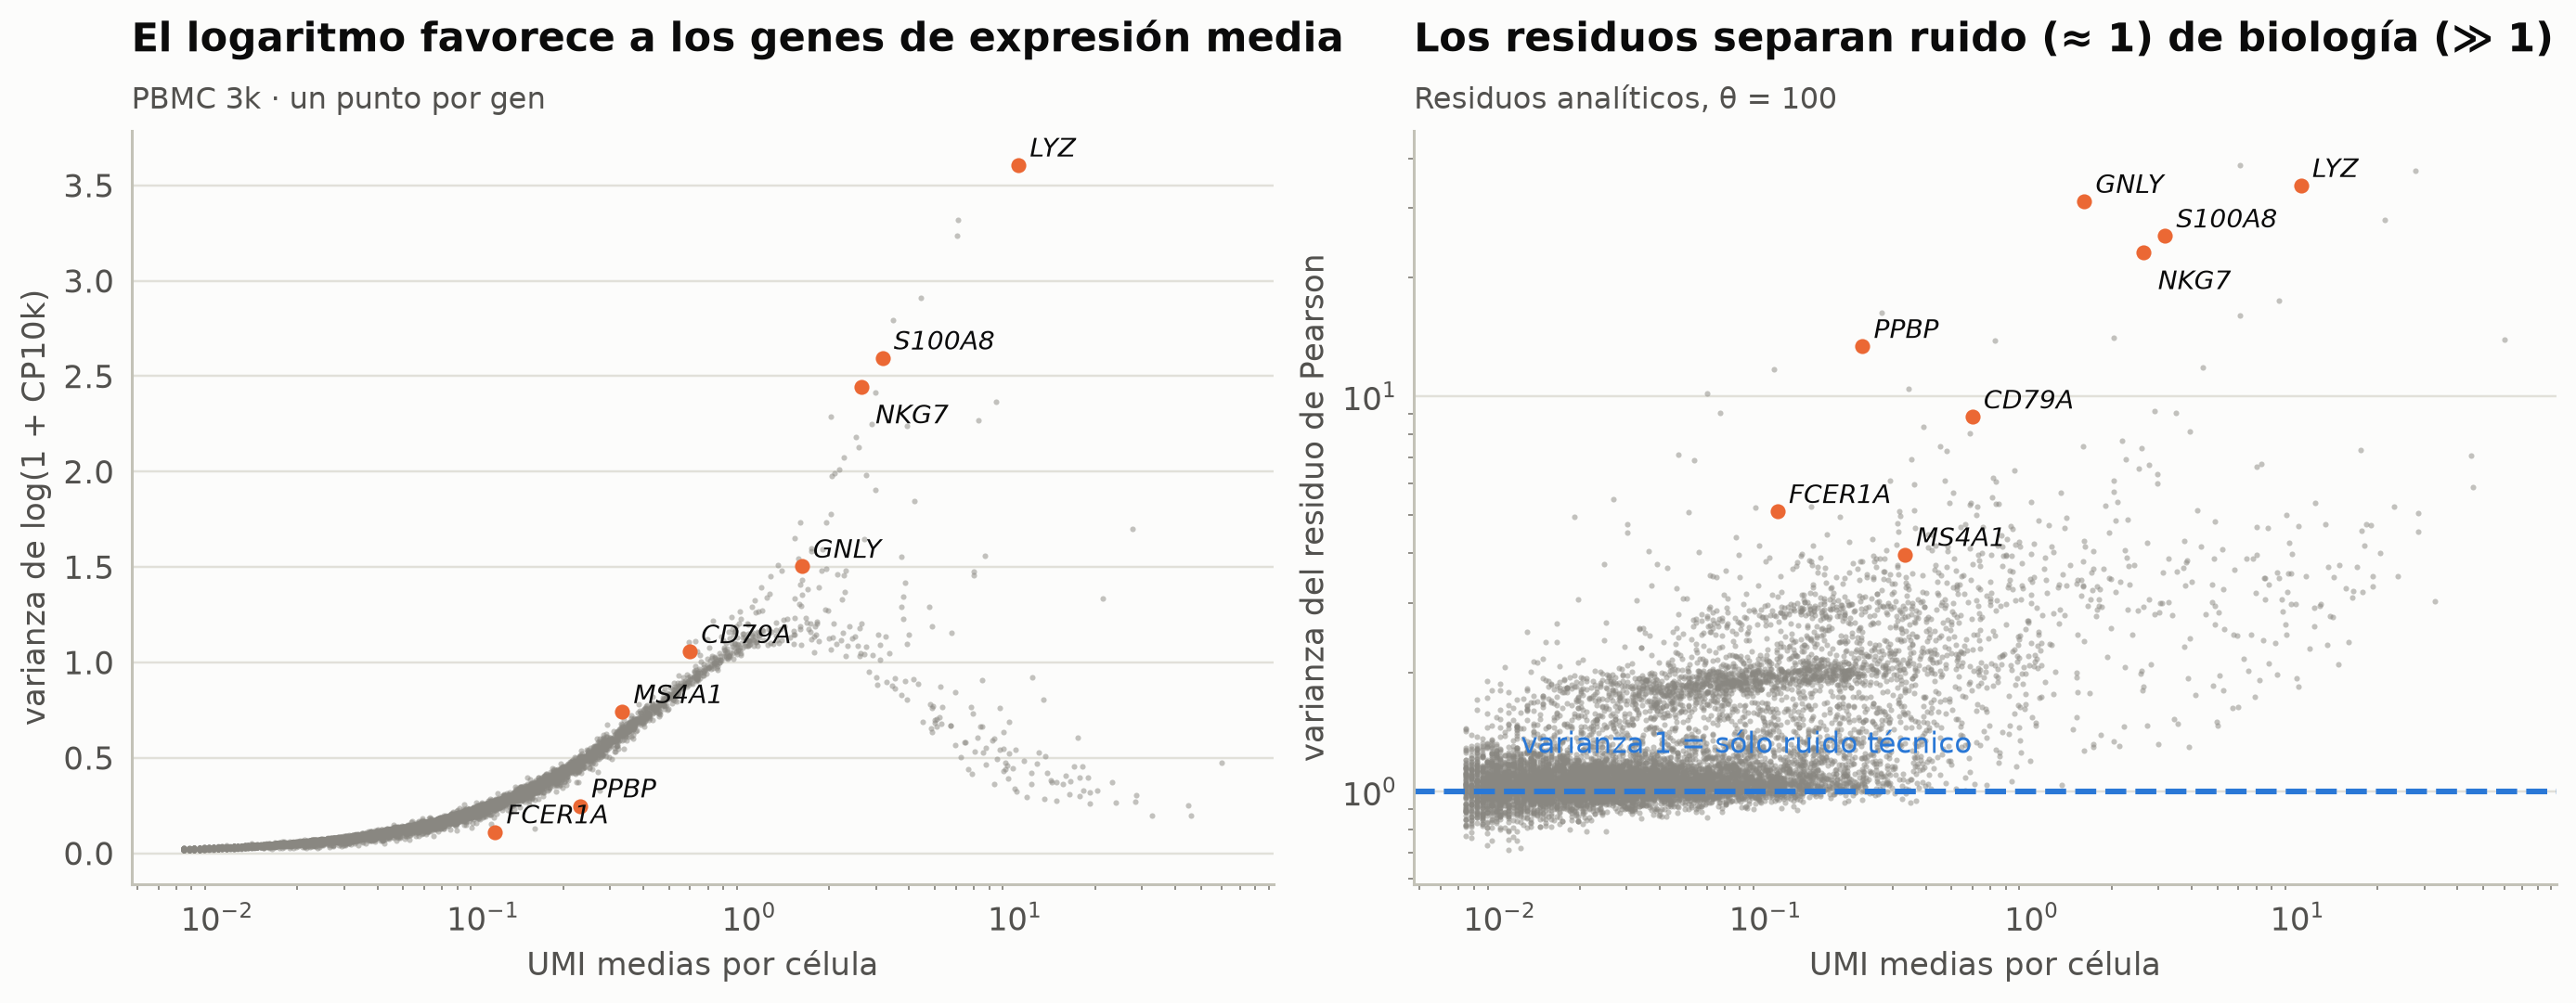

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.8))
mk = ["LYZ", "S100A8", "GNLY", "MS4A1", "PPBP", "CD79A", "NKG7", "FCER1A"]
for ax, v, lab, logy in [(axs[0], var_log_g, "varianza de log(1 + CP10k)", False),
                         (axs[1], var_pr, "varianza del residuo de Pearson", True)]:
    ax.scatter(mean_counts, v, s=4, color=ec.MUTED, alpha=0.5, lw=0)
    for g in mk:
        j = np.where(names_sub == g)[0][0]
        ax.scatter(mean_counts[j], v[j], s=28, color=ec.ORANGE, zorder=3)
        off = (5, -13) if g == "NKG7" else (4, 3)
        ax.annotate(g, (mean_counts[j], v[j]), xytext=off, textcoords="offset points", fontsize=9, style="italic")
    ax.set_xscale("log"); ax.set_xlabel("UMI medias por célula")
    if logy:
        ax.set_yscale("log"); ax.axhline(1, color=ec.BLUE, ls="--"); ax.text(0.012, 1.25, "varianza 1 = sólo ruido técnico",
                                                                            color=ec.BLUE, fontsize=10)
    ax.set_ylabel(lab)
ec.title(axs[0], "El logaritmo favorece a los genes de expresión media", "PBMC 3k · un punto por gen")
ec.title(axs[1], "Los residuos separan ruido (≈ 1) de biología (≫ 1)", "Residuos analíticos, θ = 100")
plt.show()

> 🔎 **Qué observamos.** Con $\log(1+\text{CP10k})$ (izquierda) la varianza depende de la media: sube con ella hasta
> ~1–10 UMI y los marcadores no se separan claramente de genes muy expresados y aburridos. Con los residuos de Pearson
> (derecha), la mayoría de los genes se amontona cerca de **1**, lo que el modelo espera del ruido técnico, y los marcadores
> de tipo celular (*LYZ*, *S100A8*, *GNLY*, *PPBP* de plaquetas…) sobresalen por **órdenes de magnitud**. Por eso los residuos
> de Pearson son también un buen criterio para elegir genes variables.

> ✅ **Compruebe su comprensión.** Dos células tienen 3 y 6 UMI de *CD3E* y 1 500 y 3 000 UMI totales. ¿Tienen la
> misma expresión normalizada? ¿Por qué *PPBP*, con apenas 0.23 UMI medias, tiene una varianza del residuo
> (13.4) mayor que *ACTB* (7.3), con 17 UMI medias? *(Sí: 20 CP10k en ambas, $y=\ln 21=3.04$. *PPBP* se concentra en unas
> pocas plaquetas y es cero en el resto: variación biológica; *ACTB* se expresa en todas las células y buena parte de su
> variación se explica por la profundidad, que es justamente lo que el modelo descuenta.)*

## 8. Genes altamente variables (HVG)

De unos 20 000 genes, la mayoría no distingue tipos celulares: son genes constitutivos o genes apenas detectados cuya
variación es ruido de muestreo. Restringir el análisis a los genes **altamente variables** reduce el ruido y el coste. El
criterio no puede ser la varianza bruta, porque la varianza crece con la media; hay que comparar cada gen con **los genes
de expresión media parecida**. Es como evaluar a un corredor dentro de su categoría de edad: un tiempo excelente para un
atleta de 70 años sería mediocre para uno de 25. En el sabor clásico se calcula la dispersión $d_g=\log(\sigma_g^2/\mu_g)$,
se agrupan los genes en intervalos de media y dentro de cada intervalo se estandariza:

$$
z_g = \frac{d_g - \operatorname{media}\{d_h : h\in B(g)\}}{\operatorname{de}\{d_h : h\in B(g)\}}, \qquad (12.13)
$$

| Símbolo | Significado |
|---|---|
| $\mu_g,\ \sigma_g^2$ | Media y varianza del gen $g$ en CP10k (sin logaritmo) |
| $d_g$ | Dispersión: log del cociente varianza/media (0 para una Poisson pura) |
| $B(g)$ | Intervalo de medias al que pertenece $g$ (20 intervalos por cuantiles) |
| $z_g$ | Dispersión normalizada: cuántas desviaciones estándar sobresale $g$ en su categoría |

Se retienen los genes de mayor $z_g$ (de 2 000 a 5 000 en datos reales; 500 en la simulación del libro, que sólo tiene 2 000
genes). Ya usamos la función `hvg` dentro de Scrublet; ahora la aplicamos a las 3 085 células limpias de la simulación.

In [37]:
Y = lognorm(X)
hv, lmu, zd = hvg(Y, 500)
is_hv = np.zeros(NG, bool); is_hv[hv] = True
named_hv = [NOMBRES[i] for i in hv if NOMBRES[i] in MARC]
print(f"{len(hv)} HVG; marcadores simulados entre los HVG: {len(named_hv)}/{len(MARC)} "
      f"(falta: {sorted(set(MARC) - set(named_hv))}); mitocondriales: {int(np.sum(hv < NMT))} "
      "(excluidos de antemano como candidatos)")
print("Top 10:", [NOMBRES[i] for i in hv[:10]])
# dispersión BN estimada por momentos en células T CD4, genes de fondo
tot = X.sum(1); sfac = tot / tot.mean()
Xn = X / sfac[:, None]; mu_g = Xn.mean(0); var_g = Xn.var(0, ddof=1)
i4 = T == 0
Xc4 = X[i4] / (X[i4].sum(1) / X[i4].sum(1).mean())[:, None]
m4, v4 = Xc4.mean(0), Xc4.var(0, ddof=1)
g4 = (m4 > 0.05) & (np.arange(NG) >= NMT + len(MARC))
th_hat = np.median(m4[g4]**2 / np.maximum(v4[g4] - m4[g4], 1e-6))
print(f"θ estimado por momentos (T CD4, genes de fondo) = {th_hat:.2f}; θ simulado (mediana) = {np.median(THETA):.2f}")

500 HVG; marcadores simulados entre los HVG: 31/32 (falta: ['CD4']); mitocondriales: 0 (excluidos de antemano como candidatos)
Top 10: ['NKG7', 'MS4A1', 'CD79A', 'CD14', 'GNLY', 'GZMB', 'S100A8', 'FCER1A', 'G0917', 'G0774']
θ estimado por momentos (T CD4, genes de fondo) = 1.83; θ simulado (mediana) = 6.02


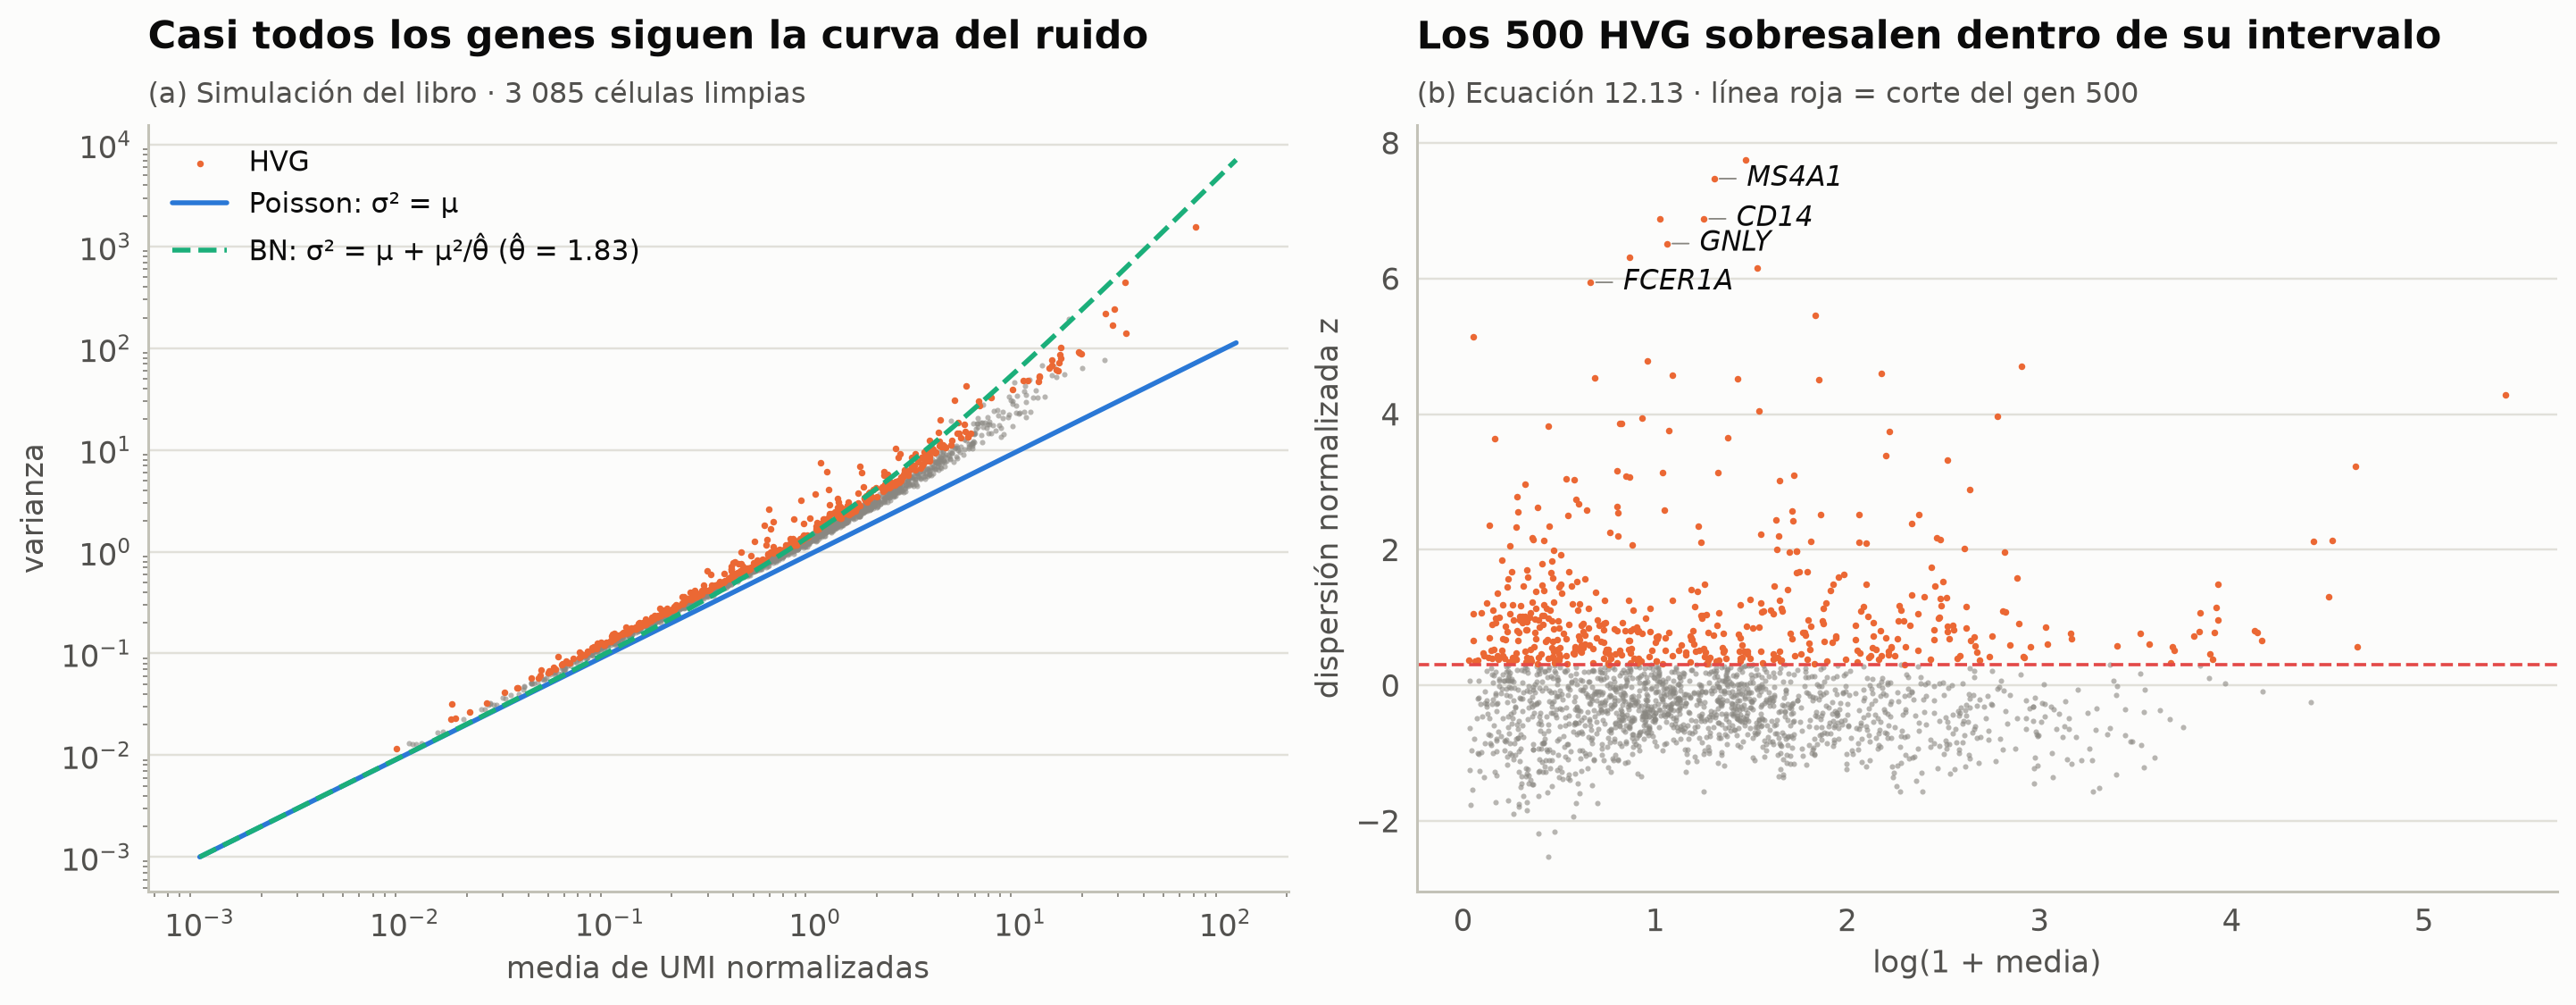

In [38]:
okg = mu_g > 1e-3
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
ax = axs[0]
ax.scatter(mu_g[okg & ~is_hv], var_g[okg & ~is_hv], s=4, color=ec.MUTED, lw=0, alpha=0.6)
ax.scatter(mu_g[okg & is_hv], var_g[okg & is_hv], s=6, color=ec.ORANGE, lw=0, label="HVG")
xx = np.logspace(-3, np.log10(mu_g.max()) + .2, 100)
ax.plot(xx, xx, color=ec.BLUE, lw=1.8, label="Poisson: σ² = μ")
ax.plot(xx, xx + xx**2 / th_hat, color=ec.AQUA, lw=1.8, ls="--", label=f"BN: σ² = μ + μ²/θ̂ (θ̂ = {th_hat:.2f})")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("media de UMI normalizadas"); ax.set_ylabel("varianza")
ax.legend(frameon=False, loc="upper left")
ec.title(ax, "Casi todos los genes siguen la curva del ruido", "(a) Simulación del libro · 3 085 células limpias")
ax = axs[1]
fin = np.isfinite(zd) & okg
ax.scatter(lmu[fin & ~is_hv], zd[fin & ~is_hv], s=4, color=ec.MUTED, lw=0, alpha=0.6)
ax.scatter(lmu[fin & is_hv], zd[fin & is_hv], s=6, color=ec.ORANGE, lw=0)
for g in ("GNLY", "MS4A1", "FCER1A", "CD14"):
    i = IM[g]
    ax.annotate(g, (lmu[i], zd[i]), xytext=(12, 0), textcoords="offset points", fontsize=10, style="italic",
                va="center", arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.6))
ax.axhline(np.sort(zd[fin])[::-1][499], color=ec.RED, ls="--", lw=1.2)
ax.set_xlabel("log(1 + media)"); ax.set_ylabel("dispersión normalizada z")
ec.title(ax, "Los 500 HVG sobresalen dentro de su intervalo", "(b) Ecuación 12.13 · línea roja = corte del gen 500")
plt.show()

> 🔎 **Qué observamos.** Entre los 500 HVG están **31 de los 32 marcadores** simulados; los diez primeros son marcadores de
> NK, B, monocitos y dendríticas, más dos genes de fondo con cambios entre linajes. (Ningún gen mitocondrial es HVG, pero
> sólo porque la función los excluye de antemano: con células dañadas de por medio, su variabilidad es técnica.) Un detalle
> instructivo: la dispersión BN estimada por momentos en las células T CD4 normalizadas vale $\hat\theta\approx1.83$, muy
> por debajo del valor simulado (mediana 6.02). No es un error de cálculo: al dividir por un factor de tamaño aleatorio, las
> células pequeñas inflan la componente de Poisson de la varianza y las cuentas normalizadas ya no son binomiales
> negativas. Es la razón de fondo por la que Hafemeister y Satija prefieren **modelar** la profundidad a dividir por ella.

### 🧪 HVG en PBMC 3k: el peligro de los genes casi nunca detectados

Apliquemos la misma función a las 2 683 células reales y comparemos con los sabores de Scanpy, mirando cuántos marcadores
conocidos de PBMC recupera cada uno entre sus 2 000 HVG.

In [39]:
MARKERS_PBMC = ["IL7R", "CCR7", "CD8A", "GNLY", "NKG7", "MS4A1", "CD79A", "CD14", "LYZ", "S100A8",
                "FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"]
Ecp = sparse.csr_matrix(ad.layers["counts"], dtype=np.float64)
Ecp = sparse.diags(1e4 / np.asarray(Ecp.sum(1)).ravel()) @ Ecp
n_ = Ecp.shape[0]
mu_r = np.asarray(Ecp.mean(0)).ravel()
var_r = (np.asarray(Ecp.multiply(Ecp).sum(0)).ravel() - n_ * mu_r**2) / (n_ - 1)
is_mt_r = ad.var["mt"].values
res_hvg = {}
for label, mm in [("nuestra ec. 12.13", 0.0), ("nuestra + media ≥ 0.1 CP10k", 0.1)]:
    top_g, lmu_r, z_r = hvg_from_moments(mu_r, var_r, 2000, exclude=np.where(is_mt_r)[0], min_mean=mm)
    res_hvg[label] = set(ad.var_names[top_g])
    if mm == 0:
        print("Primeros 8 HVG sin filtro de media:", list(ad.var_names[top_g[:8]]))
        print("  …detectados en", [int(v) for v in np.asarray((ad.layers['counts'][:, top_g[:8]] > 0).sum(0)).ravel()],
              "células")
        z_real, lmu_real = z_r, lmu_r
for flavor, kw in [("seurat", {}), ("cell_ranger", {}), ("seurat_v3", {"layer": "counts"})]:
    try:
        h = sc.pp.highly_variable_genes(ad, flavor=flavor, n_top_genes=2000, inplace=False, **kw)
        res_hvg[f"Scanpy «{flavor}»"] = set(ad.var_names[h["highly_variable"].values])
    except Exception as err:          # seurat_v3 necesita el paquete scikit-misc
        print(f"(sabor {flavor} no disponible: {type(err).__name__})")
tab_hvg = pd.DataFrame({k: ["✔" if g in v else "·" for g in MARKERS_PBMC] for k, v in res_hvg.items()},
                       index=MARKERS_PBMC).T
tab_hvg["marcadores"] = [sum(g in v for g in MARKERS_PBMC) for v in res_hvg.values()]
tab_hvg

Primeros 8 HVG sin filtro de media: ['PPT2-EGFL8', 'KIF3C', 'RP11-141B14.1', 'RP1-28O10.1', 'RP11-378J18.3', 'ZNF436', 'RP11-545I5.3', 'RP11-211G3.2']
  …detectados en [3, 7, 5, 7, 5, 6, 6, 3] células


,IL7R,CCR7,CD8A,GNLY,NKG7,MS4A1,CD79A,CD14,LYZ,S100A8,FCGR3A,MS4A7,FCER1A,CST3,PPBP,marcadores
nuestra ec. 12.13,·,·,·,✔,✔,·,✔,·,✔,✔,·,·,✔,✔,✔,8
nuestra + media ≥ 0.1 CP10k,✔,·,·,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,13
Scanpy «seurat»,✔,·,·,✔,✔,✔,✔,·,✔,✔,✔,·,✔,✔,✔,11
Scanpy «cell_ranger»,·,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,14
Scanpy «seurat_v3»,✔,·,·,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,✔,13


> 🔎 **Qué observamos.** Con 13 668 genes reales, los genes de mayor $z_g$ «puro» son transcritos detectados en un puñado de
> células: con tan pocos datos, su cociente varianza/media es enorme por azar, y la estandarización por intervalos no lo
> corrige porque el intervalo de medias más bajo está lleno de genes parecidos. Exigir una media mínima (como hace el
> tutorial clásico con `min_mean=0.0125` en escala log) o usar estadísticos robustos, como el sabor `cell_ranger` (mediana y
> MAD dentro de cada intervalo) o `seurat_v3` (varianza de las cuentas crudas estandarizadas con una tendencia ajustada
> media–varianza), recupera casi todos los marcadores. **Mire siempre qué genes eligió** antes de seguir.

El explorador muestra el plano media–dispersión real con el criterio del sabor `cell_ranger`. Pase el cursor por los puntos:

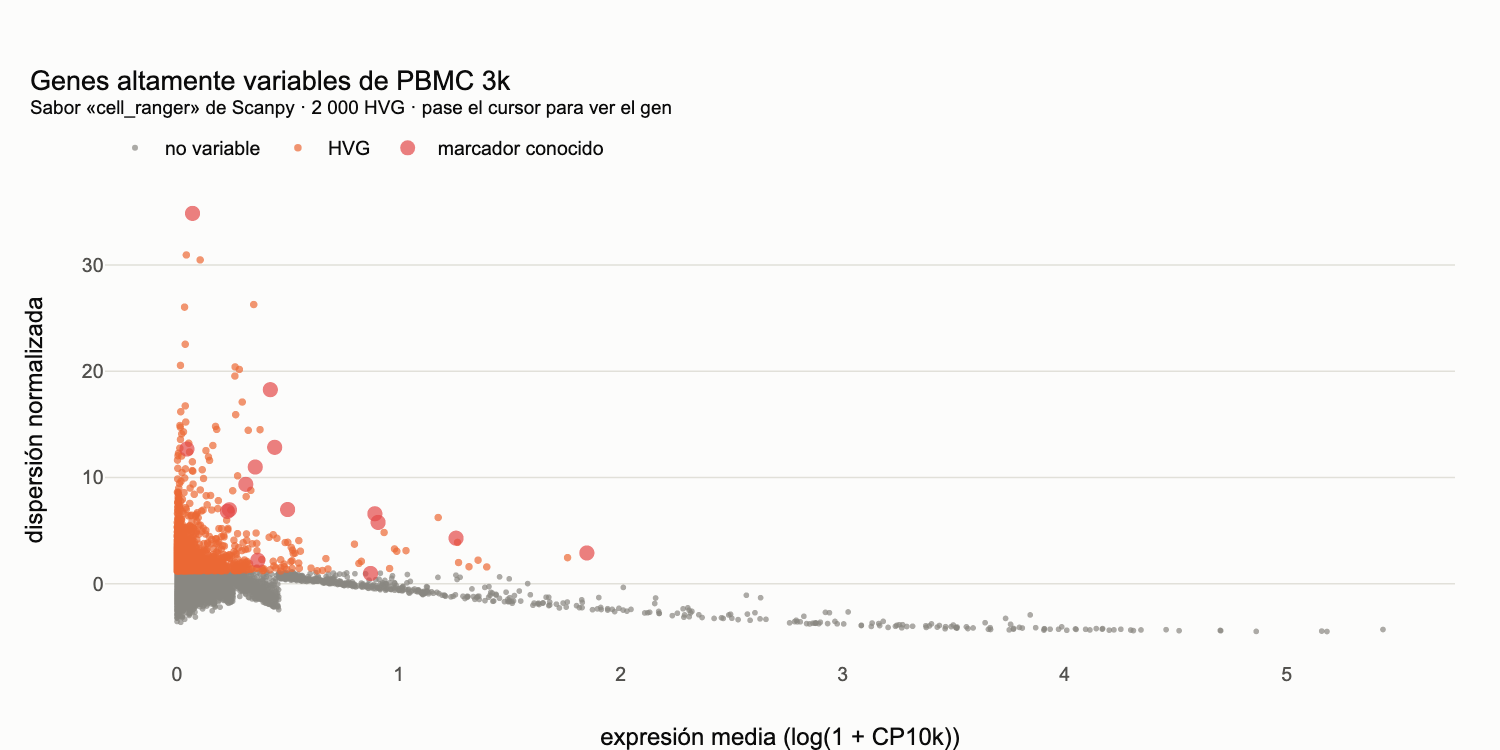

In [40]:
h_cr = sc.pp.highly_variable_genes(ad, flavor="cell_ranger", n_top_genes=2000, inplace=False)
dfh = pd.DataFrame({"gen": ad.var_names, "media": h_cr["means"].values, "disp": h_cr["dispersions_norm"].values,
                    "hvg": h_cr["highly_variable"].values,
                    "celulas": np.asarray((ad.layers["counts"] > 0).sum(0)).ravel()})
dfh = dfh[np.isfinite(dfh.disp)]
dfh["tipo"] = np.where(dfh.gen.isin(MARKERS_PBMC), "marcador conocido", np.where(dfh.hvg, "HVG", "no variable"))
figh = go.Figure()
for tname, col, size in [("no variable", ec.MUTED, 4), ("HVG", ec.ORANGE, 5), ("marcador conocido", ec.RED, 10)]:
    d_ = dfh[dfh.tipo == tname]
    figh.add_trace(go.Scattergl(
        x=d_.media, y=d_.disp, mode="markers", name=tname, marker=dict(color=col, size=size, opacity=0.7),
        customdata=np.c_[d_.gen, d_.celulas, np.where(d_.hvg, "sí", "no")],
        hovertemplate=("<b><i>%{customdata[0]}</i></b><br>media log-normalizada = %{x:.3f}"
                       "<br>dispersión normalizada = %{y:.2f} (MAD por encima de su intervalo)"
                       "<br>detectado en %{customdata[1]} de 2 683 células · HVG: %{customdata[2]}<extra></extra>")))
figh.update_xaxes(title="expresión media (log(1 + CP10k))")
figh.update_yaxes(title="dispersión normalizada")
figh.update_layout(title="Genes altamente variables de PBMC 3k<br><sup>Sabor «cell_ranger» de Scanpy · 2 000 HVG · "
                         "pase el cursor para ver el gen</sup>", height=500,
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=70, r=30, b=60))
figh.show()

## 9. Varias muestras: el lote empieza en el control de calidad

Hasta aquí trabajamos con una sola muestra. En un estudio clínico real (por ejemplo, PBMC de pacientes con asma antes y
después de tratamiento con corticoides) habrá varias muestras, procesadas en días distintos, en canales distintos del
chip y secuenciadas a profundidades distintas: cada una es un **lote**. La corrección de efectos de lote sobre el espacio
reducido (Harmony y afines) llega en la Lección 12.3, pero **tres decisiones de esta lección ya dependen del lote**:

1. **Umbrales de QC por muestra.** Una muestra secuenciada a la mitad de profundidad tiene todos sus $N_c$ a la mitad;
   un umbral MAD global la castigaría injustamente.
2. **Scrublet por muestra** (la advertencia «El orden importa»): los dobletes sólo se forman dentro de un canal.
3. **HVG por lote**: `sc.pp.highly_variable_genes(..., batch_key="muestra")` elige los genes en cada lote y prefiere los
   que son variables en muchos, para no seleccionar genes que sólo reflejan diferencias técnicas entre lotes.

Veamos el primer punto con el simulador del libro: dos muestras de 1 000 células sanas y 50 dañadas cada una; la segunda,
secuenciada a **un cuarto** de profundidad (submuestreo binomial de cada UMI con probabilidad 0.25). Para aislar el efecto
de la profundidad usamos sólo $N_c$ y $D_c$, con $k=3$, como haríamos en un experimento de **núcleos aislados**
(snRNA-seq), donde el porcentaje mitocondrial no sirve porque el núcleo no contiene mitocondrias.

In [41]:
XA, _, eA = sim_pbmc(1000, seed=101, n_dead=50, n_dbl=0)
XB, _, eB = sim_pbmc(1000, seed=202, n_dead=50, n_dbl=0)
XB = np.random.default_rng(7).binomial(XB, 0.25)                # lote B: un cuarto de profundidad
Xab, eab = np.vstack([XA, XB]), np.r_[eA, eB]
batch = np.r_[["A"] * len(XA), ["B"] * len(XB)]
Nab, Dab, _ = qc_metrics(Xab, np.arange(NG) < NMT)

def nd_filter(N, D, k=3):
    """Umbrales MAD (k) sobre log(1+N) y log(1+D); devuelve (límites de N, máscara de descarte)."""
    lN, lD = np.log1p(N), np.log1p(D)
    limN = np.expm1([np.median(lN) - k * mad(lN), np.median(lN) + k * mad(lN)])
    limD = np.expm1([np.median(lD) - k * mad(lD), np.median(lD) + k * mad(lD)])
    return limN, (N < limN[0]) | (N > limN[1]) | (D < limD[0]) | (D > limD[1])

limN_g, out_global = nd_filter(Nab, Dab)
out_batch = np.zeros(len(Nab), bool); limN_b = {}
for b in ["A", "B"]:
    s_ = batch == b
    limN_b[b], out_batch[s_] = nd_filter(Nab[s_], Dab[s_])
rows = []
for b in ["A", "B"]:
    for e, en in [("ok", "sanas"), ("baja", "dañadas")]:
        s_ = (batch == b) & (eab == e)
        rows.append({"lote": b, "grupo": en, "n": int(s_.sum()),
                     "descartadas (umbral global)": int((out_global & s_).sum()),
                     "descartadas (umbral por lote)": int((out_batch & s_).sum())})
print(pd.DataFrame(rows).to_string(index=False))
print(f"Mediana de N: lote A {np.median(Nab[batch=='A']):.0f} · lote B {np.median(Nab[batch=='B']):.0f}")
print(f"MAD(log N): global {mad(np.log1p(Nab)):.2f} · lote A {mad(np.log1p(Nab[batch=='A'])):.2f} · "
      f"lote B {mad(np.log1p(Nab[batch=='B'])):.2f}")

lote   grupo    n  descartadas (umbral global)  descartadas (umbral por lote)
   A   sanas 1000                            0                              4
   A dañadas   50                            1                             36
   B   sanas 1000                            0                              2
   B dañadas   50                           17                             34
Mediana de N: lote A 2662 · lote B 664
MAD(log N): global 1.05 · lote A 0.49 · lote B 0.47


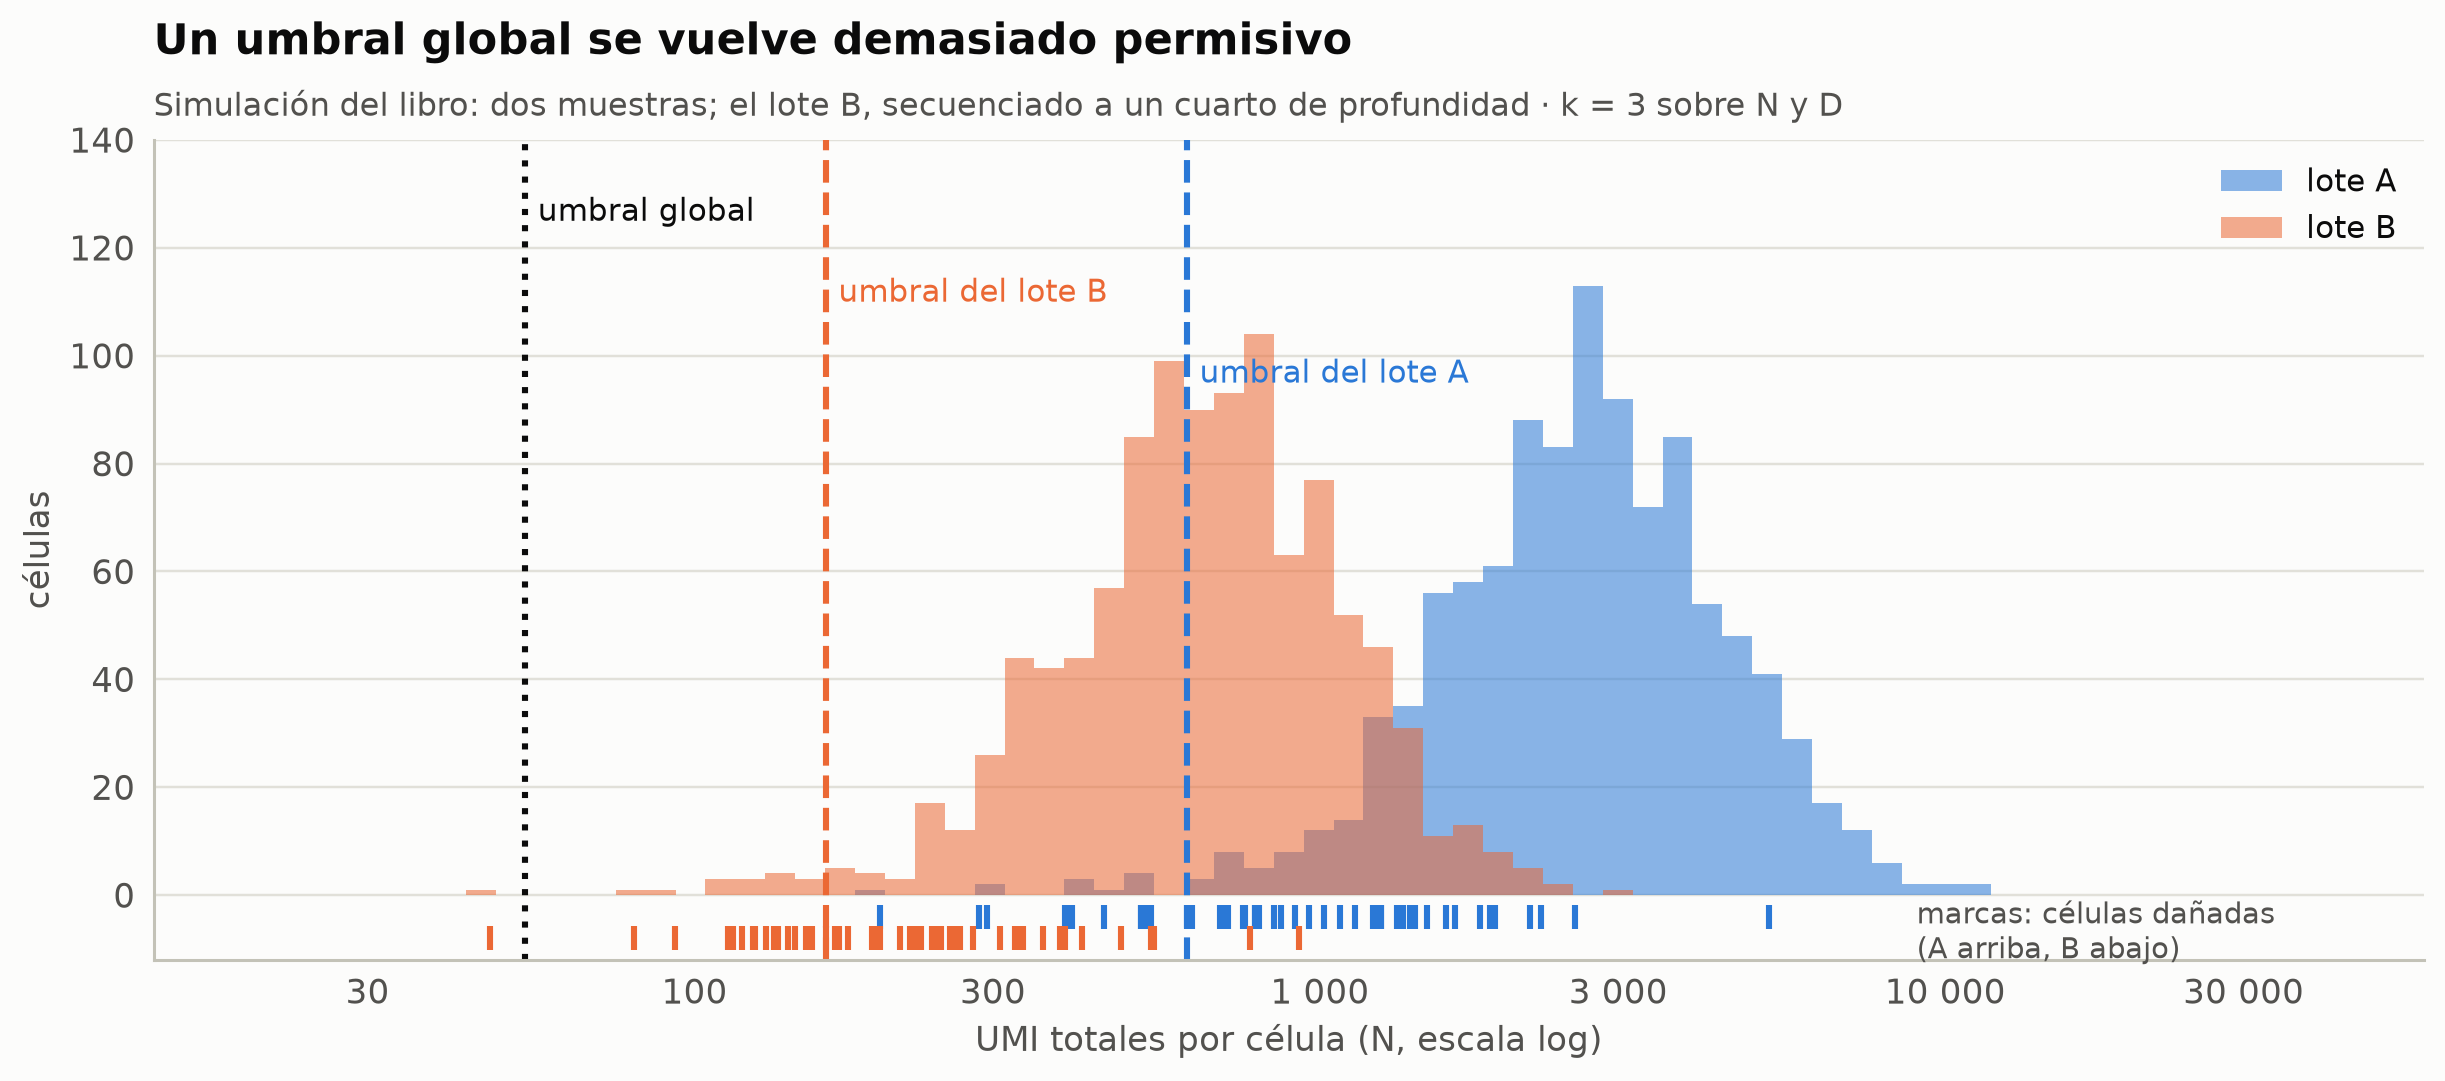

In [42]:
fig, ax = plt.subplots(figsize=(11, 4.8))
bins_b = np.linspace(1.3, 4.6, 70)
for b, col in [("A", ec.BLUE), ("B", ec.ORANGE)]:
    s_ = batch == b
    ax.hist(np.log10(Nab[s_]), bins=bins_b, color=col, alpha=0.55, label=f"lote {b}")
    ax.axvline(np.log10(limN_b[b][0]), color=col, ls="--", lw=2)
    ax.text(np.log10(limN_b[b][0]) + 0.02, 95 if b == "A" else 110, f"umbral del lote {b}", color=col, fontsize=10)
    dead = s_ & (eab == "baja")
    ax.scatter(np.log10(Nab[dead]), np.full(dead.sum(), -4 if b == "A" else -8), marker="|", s=60, color=col)
ax.axvline(np.log10(limN_g[0]), color=ec.INK, ls=":", lw=2)
ax.text(np.log10(limN_g[0]) + 0.02, 125, "umbral global", color=ec.INK, fontsize=10)
ax.text(np.log10(9000), -7, "marcas: células dañadas\n(A arriba, B abajo)", color=ec.INK_2, fontsize=9.5, va="center")
ax.set_xticks(np.log10([30, 100, 300, 1000, 3000, 10000, 30000]), ["30", "100", "300", "1 000", "3 000", "10 000", "30 000"])
ax.set_xlabel("UMI totales por célula (N, escala log)"); ax.set_ylabel("células")
ax.set_ylim(-12, 140)
ax.legend(frameon=False, loc="upper right")
ec.title(ax, "Un umbral global se vuelve demasiado permisivo", "Simulación del libro: dos muestras; el lote B, "
                                                            "secuenciado a un cuarto de profundidad · k = 3 sobre N y D")
plt.show()

> 🔎 **Qué observamos.** La distribución del lote B está desplazada a la izquierda ($\log_{10}4\approx0.6$). Al mezclar los
> dos lotes, la distribución global es **ancha y bimodal**: su MAD se duplica con creces y el umbral inferior global cae muy
> abajo, así que las células dañadas de ambos lotes pasan casi todas. Con umbrales **por lote**, cada muestra se juzga con
> su propia mediana y su propia MAD, y se detectan 70 de las 100 células dañadas a costa de apenas 6 de las 2 000 sanas. La regla general:
> calcule el QC por muestra, mire las distribuciones de todas juntas y sólo después combine.

## 10. El flujo completo en Scanpy

Todo lo anterior cabe en una docena de líneas. Es el código del libro, con dos adaptaciones: leemos la matriz con
`read_10x_mtx` (el libro usa el formato HDF5 `.h5` de las versiones modernas de Cell Ranger) y usamos los umbrales
adaptativos que calculamos en la sección 5.

In [43]:
t0 = time.time()
adata2 = sc.read_10x_mtx(mtx_dir, var_names="gene_symbols")
adata2.var_names_make_unique()
adata2.var["mt"] = adata2.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata2, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
o_ = adata2.obs
ok = (o_.total_counts.between(*thr_r["N"]) & o_.n_genes_by_counts.between(*thr_r["D"])
      & (o_.pct_counts_mt < thr_r["m"]))
adata2 = adata2[ok].copy()
sc.pp.filter_genes(adata2, min_cells=3)
sc.pp.scrublet(adata2, random_state=0)                          # Scanpy >= 1.10
adata2 = adata2[~adata2.obs["predicted_doublet"]].copy()
adata2.layers["counts"] = adata2.X.copy()                       # cuentas crudas
sc.pp.normalize_total(adata2, target_sum=1e4)
sc.pp.log1p(adata2)
try:
    sc.pp.highly_variable_genes(adata2, n_top_genes=2000, flavor="seurat_v3", layer="counts")
except ImportError:                                              # sin scikit-misc
    sc.pp.highly_variable_genes(adata2, n_top_genes=2000, flavor="cell_ranger")
print(f"Flujo completo en {time.time()-t0:.1f} s")
print(f"Células: 2 700 → {int(ok.sum())} tras el QC → {adata2.n_obs} tras quitar dobletes · genes: {adata2.n_vars} "
      f"· HVG: {int(adata2.var.highly_variable.sum())}")
adata2

Flujo completo en 1.1 s
Células: 2 700 → 2683 tras el QC → 2650 tras quitar dobletes · genes: 13668 · HVG: 2000


AnnData object with n_obs × n_vars = 2650 × 13668
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'log1p', 'hvg'
    layers: None (.X), 'counts'

> 🔎 **Qué observamos.** De 2 700 códigos de barras quedan 2 650 células limpias, normalizadas y con 2 000 HVG marcados.
> Ése sería nuestro punto de partida razonado; sin embargo, las Lecciones 12.2 y 12.3 recalculan el preprocesado con los
> **umbrales fijos del tutorial clásico** de Seurat y Scanpy (200–2 500 genes, mitocondrial < 5 %, sin Scrublet), que dejan
> **2 638 células**, para que sus resultados se puedan comparar directamente con la literatura y con los tutoriales
> oficiales. Nuestro QC adaptativo (mediana + 3 MAD, con un piso del 8 %) conserva 45 células más que el tutorial, que
> corta el ARN mitocondrial en un 5 % fijo: sobre todo células con 5–8 % de lecturas mitocondriales, sanas en una muestra
> tan limpia. Scrublet quita luego 33 dobletes que el tutorial deja pasar, y el saldo final es de 12 células. Cada lección
> siguiente recalcula su flujo en segundos a partir de la matriz de 10x, así que no hace falta guardar nada.

> ⚠️ **El orden importa.** La selección de HVG con `flavor="seurat_v3"` espera cuentas **crudas** (por eso se guardan en una
> capa); los sabores `"seurat"` y `"cell_ranger"` esperan datos log-normalizados. Scrublet debe ejecutarse sobre cuentas
> crudas y, si hay varias muestras, por separado en cada una.

## 🏋️ Ejercicios

**Ejercicio 1 (carga de gotas).** Un laboratorio no quiere más de un 5 % de dobletes entre las gotas ocupadas. Encuentre
numéricamente el $\lambda$ máximo (ecuación 12.2) y cuántas células con una sola célula obtendría por cada 100 000 gotas.
Compare con la aproximación $\lambda/2$.

**Ejercicio 2 (umbrales estrictos).** Repita el QC de PBMC 3k con $k=3$ para las tres métricas (sin piso de 8 %).
¿Cuántas células se descartan y por qué motivo? ¿Le parece razonable para sangre?

**Ejercicio 3 (tasa previa de Scrublet).** En la simulación, recalcule la puntuación del libro con $\rho=0.03$ en lugar de
0.07 (los $q_c$ no cambian). ¿Qué fracción de dobletes heterotípicos y de singletes supera ahora el umbral 0.25? Explique
con la ecuación 12.7 por qué.

**Ejercicio 4 (el pseudoconteo).** Normalice las células limpias de la simulación a CPM ($10^6$) en lugar de CP10k antes
del logaritmo. Para el gen *LYZ*, compare $y$ de las células B (que casi no lo expresan) con el de los monocitos CD14 en
ambas escalas. ¿Qué pasa con la diferencia entre «0 UMI» y «1 UMI»?

In [44]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
from scipy.optimize import brentq
f = lambda lam: (1 - np.exp(-lam) - lam * np.exp(-lam)) / (1 - np.exp(-lam)) - 0.05
lam5 = brentq(f, 1e-4, 2)
print(f"λ máximo = {lam5:.4f} (la aproximación λ/2 = 0.05 da λ = 0.10)")
print(f"Gotas con una sola célula por cada 100 000: {1e5 * lam5 * np.exp(-lam5):,.0f}")

λ máximo = 0.1017 (la aproximación λ/2 = 0.05 da λ = 0.10)
Gotas con una sola célula por cada 100 000: 9,189


In [45]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
thr3, keep3 = mad_thresholds(N_r, D_r, m_r, k_nd=3, k_mt=3, mt_floor=0)
why = pd.Series(np.select([(N_r < thr3["N"][0]) | (N_r > thr3["N"][1]), (D_r < thr3["D"][0]) | (D_r > thr3["D"][1]),
                           m_r >= thr3["m"]], ["UMI", "genes", "% mt"], "pasa"))
print(f"Umbrales k = 3: UMI [{thr3['N'][0]:.0f}, {thr3['N'][1]:.0f}] · genes [{thr3['D'][0]:.0f}, {thr3['D'][1]:.0f}] "
      f"· mt < {thr3['m']:.2f} %")
print(why.value_counts().to_string())
print("Se pierden unas 200 células: por un % mitocondrial de 4–8 %, que en sangre es perfectamente normal, y por UMI o")
print("genes algo alejados de la mediana. Con distribuciones tan estrechas, 3 MAD es un margen minúsculo en términos absolutos.")

Umbrales k = 3: UMI [803, 6011] · genes [400, 1666] · mt < 4.43 %
pasa     2490
UMI       105
% mt       72
genes      33
Se pierden unas 200 células: por un % mitocondrial de 4–8 %, que en sangre es perfectamente normal, y por UMI o
genes algo alejados de la mediana. Con distribuciones tan estrechas, 3 MAD es un margen minúsculo en términos absolutos.


In [46]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
score03 = scrublet_score(q_obs, r_ratio, 0.03)
for e in ["dob_hetero", "dob_homo", "ok"]:
    print(f"{names_est[e]:<24} ρ = 0.07: {100*np.mean(score[eq == e] > 0.25):5.2f} %   "
          f"ρ = 0.03: {100*np.mean(score03[eq == e] > 0.25):5.2f} %")
print("La puntuación es creciente en ρ (la probabilidad previa): con un ρ menor, hace falta una fracción q_c mayor")
print("de vecinos simulados para superar el mismo umbral; se marcan menos dobletes y menos singletes.")

dobletes heterotípicos   ρ = 0.07: 40.94 %   ρ = 0.03: 16.96 %
dobletes homotípicos     ρ = 0.07: 12.82 %   ρ = 0.03:  5.13 %
sanas                    ρ = 0.07:  0.51 %   ρ = 0.03:  0.07 %
La puntuación es creciente en ρ (la probabilidad previa): con un ρ menor, hace falta una fracción q_c mayor
de vecinos simulados para superar el mismo umbral; se marcan menos dobletes y menos singletes.


In [47]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for target, lab in [(1e4, "CP10k"), (1e6, "CPM")]:
    Yt = lognorm(X, target)
    yB, yM = Yt[T == 3, IM["LYZ"]], Yt[T == 4, IM["LYZ"]]
    one = np.log1p(1 / np.median(X.sum(1)) * target)
    print(f"{lab:>5}: y(LYZ) medio B = {yB.mean():.2f}, monocitos = {yM.mean():.2f}; salto 0 → 1 UMI en una célula "
          f"típica = {one:.2f}")
print("Con CPM, una sola UMI (a menudo ambiental) salta de 0 a ~6: la escala exagera la diferencia entre 0 y 1 y")
print("aumenta la varianza de los genes poco expresados. El pseudoconteo y el total de escala no son inocentes.")

CP10k: y(LYZ) medio B = 0.25, monocitos = 2.47; salto 0 → 1 UMI en una célula típica = 1.53
  CPM: y(LYZ) medio B = 0.91, monocitos = 6.84; salto 0 → 1 UMI en una célula típica = 5.89
Con CPM, una sola UMI (a menudo ambiental) salta de 0 a ~6: la escala exagera la diferencia entre 0 y 1 y
aumenta la varianza de los genes poco expresados. El pseudoconteo y el total de escala no son inocentes.


## 📌 Resumen

* El *bulk* mide una mezcla $\bar x_g=\sum_k\pi_k\mu_{gk}$; célula única separa composición ($\pi_k$) de expresión ($\mu_{gk}$).
* En las plataformas de gotas, el **código de barras celular** identifica la célula y el **UMI** la molécula; contar UMI
  distintos elimina el sesgo de la PCR. Con 12 nt, las colisiones de UMI son despreciables.
* La carga sigue una **Poisson**: la fracción de dobletes entre gotas ocupadas es $\approx\lambda/2$; más rendimiento
  implica más dobletes.
* La matriz de cuentas es **dispersa** (PBMC 3k: 2.6 % de entradas no nulas); **CSR** la guarda con `data`, `indices` e
  `indptr`, y $D_c$ es simplemente `np.diff(indptr)`.
* La **curva de rodilla** separa células de gotas vacías; el **ARN ambiental** (ecuación 12.4) contamina todas las gotas y
  crea expresión espuria (p. ej., *LYZ* en células B).
* QC con $N_c$, $D_c$ y $m_c$ y umbrales **adaptativos** por MAD ($k=5$ en escala log; $k=3$ para $m$), revisando el tejido:
  en la simulación del libro se descartan las 150 dañadas y 35 sanas (quedan 3 175); en PBMC 3k quedan 2 683 de 2 700.
* Ninguna métrica univariante detecta dobletes; **Scrublet** fabrica dobletes y puntúa con Bayes (ecuación 12.7): detecta el
  40.9 % de los heterotípicos y el 12.8 % de los homotípicos en la simulación; Scanpy marca 33 dobletes en PBMC 3k.
* Los ceros de gotas son los que predice la **binomial negativa**; no hace falta inflación de ceros.
* $\log(1+\text{CP10k})$ compara proporciones y estabiliza la varianza en $1/\theta$ para genes muy expresados (método
  delta); los **residuos de Pearson** modelan la profundidad y dejan el ruido técnico con varianza ≈ 1.
* Los **HVG** se eligen comparando cada gen con los de media parecida; vigile los genes casi nunca detectados.
* Con varias muestras, QC, Scrublet y HVG se hacen **por lote**.

## 📚 Para profundizar

* Tang, F. *et al.* (2009). mRNA-Seq whole-transcriptome analysis of a single cell. *Nature Methods* 6(5): 377–382.
* Macosko, E. Z. *et al.* (2015). Highly parallel genome-wide expression profiling of individual cells using nanoliter
  droplets. *Cell* 161(5): 1202–1214.
* Klein, A. M. *et al.* (2015). Droplet barcoding for single-cell transcriptomics applied to embryonic stem cells. *Cell*
  161(5): 1187–1201.
* Zheng, G. X. Y. *et al.* (2017). Massively parallel digital transcriptional profiling of single cells. *Nature
  Communications* 8: 14049. (Origen de los datos PBMC.)
* Kivioja, T. *et al.* (2012). Counting absolute numbers of molecules using unique molecular identifiers. *Nature Methods*
  9(1): 72–74.
* Lun, A. T. L. *et al.* (2019). EmptyDrops: distinguishing cells from empty droplets in droplet-based single-cell RNA
  sequencing data. *Genome Biology* 20: 63.
* Young, M. D. & Behjati, S. (2020). SoupX removes ambient RNA contamination from droplet-based single-cell RNA sequencing
  data. *GigaScience* 9(12): giaa151.
* Luecken, M. D. & Theis, F. J. (2019). Current best practices in single-cell RNA-seq analysis: a tutorial. *Molecular
  Systems Biology* 15(6): e8746.
* Heumos, L. *et al.* (2023). Best practices for single-cell analysis across modalities. *Nature Reviews Genetics* 24(8):
  550–572.
* Wolock, S. L., Lopez, R. & Klein, A. M. (2019). Scrublet: computational identification of cell doublets in single-cell
  transcriptomic data. *Cell Systems* 8(4): 281–291.
* Svensson, V. (2020). Droplet scRNA-seq is not zero-inflated. *Nature Biotechnology* 38(2): 147–150.
* Lun, A. T. L., Bach, K. & Marioni, J. C. (2016). Pooling across cells to normalize single-cell RNA sequencing data with
  many zero counts. *Genome Biology* 17: 75.
* Hafemeister, C. & Satija, R. (2019). Normalization and variance stabilization of single-cell RNA-seq data using
  regularized negative binomial regression. *Genome Biology* 20: 296.
* Lause, J., Berens, P. & Kobak, D. (2021). Analytic Pearson residuals for normalization of single-cell RNA-seq UMI data.
  *Genome Biology* 22: 258.
* Wolf, F. A., Angerer, P. & Theis, F. J. (2018). SCANPY: large-scale single-cell gene expression data analysis. *Genome
  Biology* 19: 15.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)